# data prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from typing import List, Dict, Union
import seaborn as sns
sns.set(rc={"figure.figsize":(10,3)})

In [2]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
 matches_df = pd.read_parquet("./esta/parsed/matches.parquet")
 rounds_df = pd.read_parquet("./esta/parsed/rounds.parquet")
 kills_df = pd.read_parquet("./esta/parsed/kills.parquet")
 damages_df = pd.read_parquet("./esta/parsed/damages.parquet") 
 grenades_df = pd.read_parquet("./esta/parsed/grenades.parquet") 
 bomb_events_df = pd.read_parquet("./esta/parsed/bomb_events.parquet") 
 weapon_fires_df = pd.read_parquet("./esta/parsed/weapon_fires.parquet") 
 flashes_df = pd.read_parquet("./esta/parsed/flashes.parquet") 
 frames_df = pd.read_parquet("./esta/parsed/frames.parquet")
 players_df = pd.read_parquet("./esta/parsed/players.parquet") 
 team_frames_df = pd.read_parquet("./esta/parsed/team_frames.parquet") 
 player_frames_df = pd.read_parquet("./esta/parsed/player_frames.parquet") 
 inventory_df = pd.read_parquet("./esta/parsed/inventory.parquet") 
 bomb_location_df = pd.read_parquet("./esta/parsed/bomb_location.parquet") 
 projectiles_df = pd.read_parquet("./esta/parsed/projectiles.parquet") 
 smokes_df = pd.read_parquet("./esta/parsed/smokes.parquet") 
 fires_df = pd.read_parquet("./esta/parsed/fires.parquet") 

image_dim = 1024

In [4]:
with open(".awpy/maps/map-data.json", "r") as f:
    all_map_data = json.load(f)


In [5]:
idx_pf_df = player_frames_df.set_index(["match_id","round_num"])
idx_f_df = flashes_df.set_index(["match_id","round_num"])
idx_sm_df = smokes_df.set_index(["match_id","round_num"])
idx_d_df = damages_df.set_index(["match_id","round_num"])

idx_d_df.loc[:,"total_damage"] = idx_d_df["hp_damage"] + idx_d_df["armor_damage"]
idx_d_df.loc[:,"total_damage_taken"] = idx_d_df["hp_damage_taken"] + idx_d_df["armor_damage_taken"]
idx_d_df.attacker_steam_id = idx_d_df.attacker_steam_id.astype("Int64")
idx_d_df.victim_steam_id = idx_d_df.victim_steam_id.astype("Int64")

idx_k_df = kills_df.set_index(["match_id","round_num"])
idx_r_df = rounds_df.set_index(["match_id","round_num"])
idx_r_df["n_ticks"] = idx_r_df["end_tick"]
idx_r_df["bomb_plant_tick"] = idx_r_df["bomb_plant_tick"]

idx_fr_df = frames_df.set_index(["match_id","round_num"])

idx_g_df = grenades_df.set_index(["match_id","round_num"])
idx_g_df["grenade_side"] = idx_g_df.thrower_side
idx_g_df = idx_g_df[idx_g_df.destroy_tick > idx_g_df.throw_tick]

idx_wf_df = weapon_fires_df.set_index(["match_id","round_num"])

In [6]:
all_idx_df = [idx_pf_df, idx_f_df, idx_sm_df, idx_d_df, idx_k_df, idx_fr_df, idx_g_df, idx_wf_df]

for idx in idx_r_df.index:
    first_tick = idx_r_df.loc[idx,"start_tick"]
    for df in all_idx_df:
        tick_cols = [col for col in df.columns if "tick" in col]
        if tick_cols and idx in df.index:
            df.loc[idx,tick_cols] = df.loc[idx,tick_cols]-first_tick

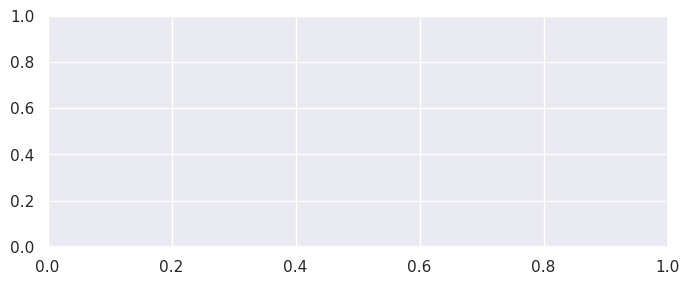

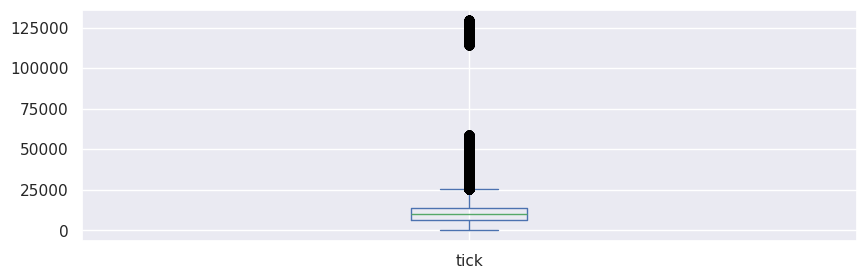

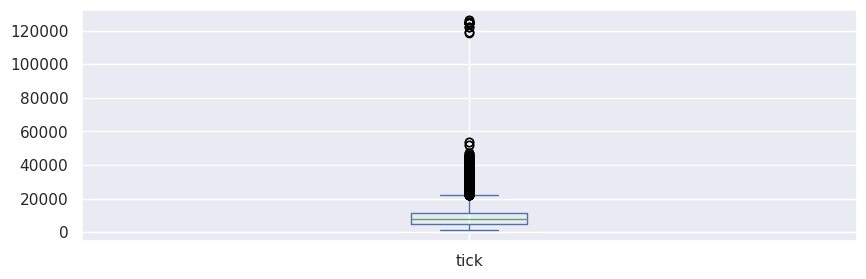

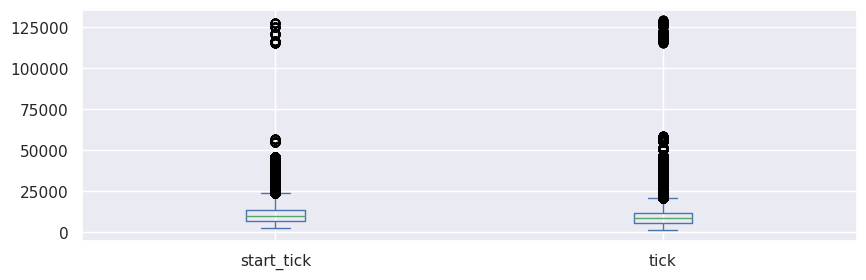

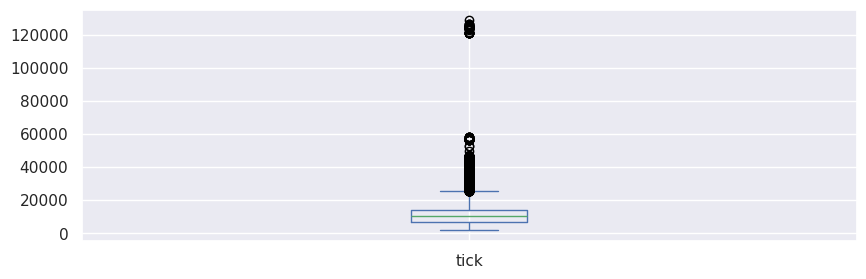

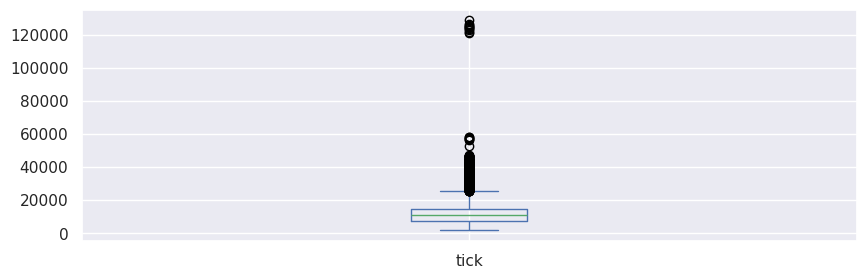

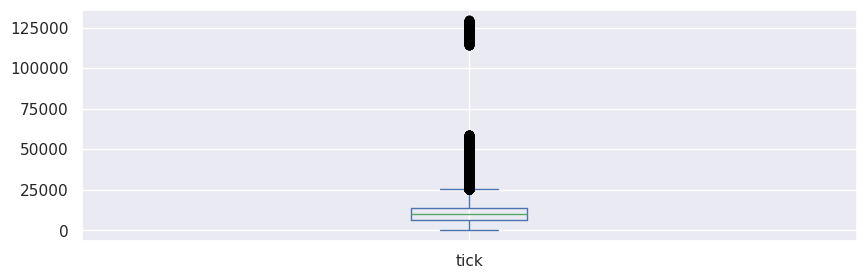

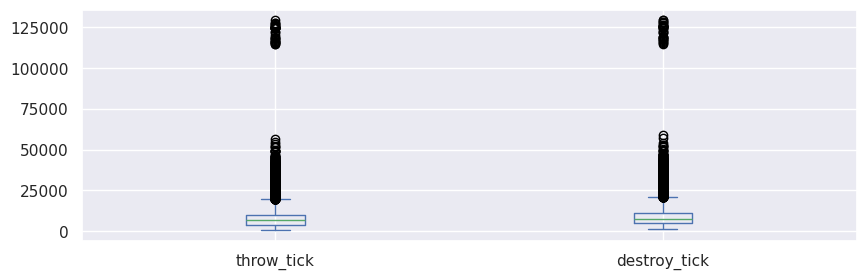

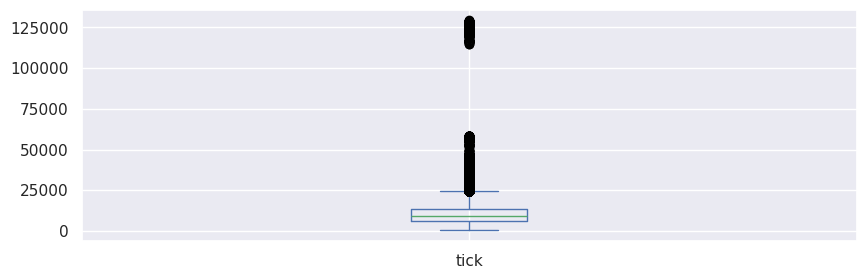

In [7]:
fig,ax = plt.subplots(figsize=(8,3))
for df in all_idx_df:
    tick_cols = [col for col in df.columns if "tick" in col]
    if tick_cols:
        df.loc[:,tick_cols].plot.box(title="")
        plt.show()

In [8]:
# Loop through each unique match+round combination
for idx in idx_wf_df.index.unique():
    round_wf = idx_wf_df.loc[idx].copy()  # Make a copy to avoid SettingWithCopyWarning
    
    round_d = idx_d_df.loc[idx].copy()
        
        
    round_wf['combo_key'] = round_wf['tick'].astype(str) + '_' + round_wf['player_steam_id'].astype('float64')\
    .astype(str)
    round_d['combo_key'] = round_d['tick'].astype(str) + '_' + round_d['attacker_steam_id'].astype("float64")\
    .astype(str)
    
    round_wf['shot_connected'] = round_wf['combo_key'].isin(round_d['combo_key'].values)

    round_wf.drop('combo_key', axis=1, inplace=True)
    
    if len(round_wf) > 0:
        if isinstance(idx_wf_df.loc[idx], pd.Series):
            idx_wf_df.loc[idx, 'shot_connected'] = round_wf['shot_connected'].iloc[0]
        else:
            idx_wf_df.loc[idx, 'shot_connected'] = round_wf['shot_connected'].values

In [9]:
# Loop through each unique match+round combination
count = 0
for idx in idx_g_df.index.unique():
    round_g = idx_g_df.loc[idx].copy()
    
    round_d = idx_d_df.loc[idx].copy()
    round_d = round_d[round_d.weapon_class=="Grenade"]

    round_g["grenade_connected"] = round_g.thrower_steam_id.isin(round_d.attacker_steam_id.values)

    idx_g_df.loc[idx,"grenade_connected"]=round_g.grenade_connected.values

# analysis over single round

In [10]:
selected_map = 'de_mirage'

In [11]:
map_data = all_map_data[selected_map]
selected_matches = matches_df[matches_df.map_name == selected_map]
display(selected_matches.head())
selected_match = selected_matches.iloc[0]
selected_round = 5
sel_idx = (selected_match.match_id,selected_round)

,client_name,map_name,tick_rate,playback_ticks,playback_frames_count,parsed_to_frame_idx,match_id,demo_id,competition_name,hltv_url,match_date,match_name
0,GOTV Demo,de_mirage,127,343251,342767,342784,0839a031-0e2c-4c03-b4bc-b5ba05fe669a,01746483-b3bd-4e4b-a2f2-0de97b17600d,PGL Major Antwerp 2022,https://www.hltv.org/matches/2356160/heroic-vs...,1652781600000,heroic-vs-vitality-pgl-major-antwerp-2022
0,GOTV Demo,de_mirage,127,471790,471564,471581,0a075b4d-576e-46f2-b944-fe9542faee54,04f0fb8f-a4d7-497c-857e-316300fadee3,IEM Katowice 2022,https://www.hltv.org/matches/2354381/furia-vs-...,1645124400000,furia-vs-astralis-iem-katowice-2022
0,GOTV Demo,de_mirage,127,426251,425998,426016,a98ffca7-e968-4a54-9e8f-22f101c2502b,022866a3-090e-42eb-ab8e-aa553a575ada,IEM Katowice 2021,https://www.hltv.org/matches/2346573/faze-vs-f...,1613905200000,faze-vs-furia-iem-katowice-2021
0,GOTV Demo,de_mirage,127,441259,440692,440707,a56115fd-a0ba-4eea-a618-91fd6c57177c,015f7c8d-2bc0-4d83-88e7-60648d2b221c,BLAST Premier Fall Showdown 2021,https://www.hltv.org/matches/2351973/heroic-vs...,1634034600000,heroic-vs-poggerz-blast-premier-fall-showdown-...
0,GOTV Demo,de_mirage,127,493224,492014,492029,f218743d-5e8b-436e-91bd-b7b3664c56c3,0418eb19-853e-4b56-955c-d3eedf2b7e12,BLAST Premier Spring Final 2021,https://www.hltv.org/matches/2349173/natus-vin...,1623853200000,natus-vincere-vs-faze-blast-premier-spring-fin...


## location based analysis over single round

### transform functions
so data fit the plotting format

In [12]:
def transform_coord(map_data,player_loc,x_col="x",y_col="y"):
    result = player_loc.copy()
        
    pos_x = map_data["pos_x"]
    pos_y = map_data["pos_y"]
    scale = map_data["scale"]

    result[x_col] = (result[x_col] - pos_x) / scale
    result[y_col] = image_dim - (pos_y - result[y_col]) / scale

    return result

#### transform coordinates
to transform for plotting in the map

In [13]:
def transform_coords(map_data,player_loc,status):
    tf = player_loc.copy()
    for st in status:
        tf = transform_coord(map_data,tf,x_col=f"{st}_x",y_col=f"{st}_y")
    return tf

In [14]:
def transform_flash(flashes):
    flashers_cols = [col for col in flashes.columns
                     if not (col.startswith('player_') or col == 'flash_duration')]
    flashers = flashes.loc[:, flashers_cols]
    
    flasheds_cols = [col for col in flashes.columns if not col.startswith('attacker_')]
    flasheds = flashes.loc[:, flasheds_cols]
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
        flashers.loc[:, "status"] = "flasher"
        flasheds.loc[:, "status"] = "flashed"
    
    flashers.columns = [col.replace("attacker_", "") if col != "attacker_side" else col 
                        for col in flashers.columns]
    flasheds.columns = [col.replace("player_", "") if col != "player_side" else col 
                        for col in flasheds.columns]
    
    result = pd.concat([flashers.drop_duplicates(), flasheds.drop_duplicates()])
    result["side"] = result["attacker_side"].fillna(result["player_side"])
    result.sort_values(["tick"],inplace=True)
    
    subset_col = [col for col in result.columns if col not in ["status","flash_duration"]]
    print(subset_col)
    dup_idx = result.duplicated(subset=subset_col)
    keep_idx = result.duplicated(subset=subset_col,keep="last")
    result.loc[dup_idx,"status"] = "both"
    return result.loc[~keep_idx,:]

#### transform action
again, to fit the plotting function and cleaner look, (dim reduce)

In [15]:
def transform_actions(actions: pd.DataFrame, 
                      status: List[str], 
                      status_extra_cols: Dict[str, List[str]] = {},
                      status_code: Dict[str, str] = {},
                      common_extra_cols: List[str] = [],
                      rename_col:Dict[str,str] = {},
                      check_dup_without_cols: List[str] = [],
                      keep: str = "first",
                      assign_dup: dict = {},
                     drop_na_cols: List[str] = []) -> pd.DataFrame:
    """Transforms action data.

    This function processes action data, potentially enriching it with status
    information, handling duplicates, and adding common extra columns.

    Args:
        actions (pd.DataFrame): The action data to transform.
        status (List[str]): Status information to merge with the action data.
        status_extra_cols (Dict[str, List[str]], optional): Extra columns from the
            status data to include in the transformed output. Defaults to {}.
        status_code (Dict[str, str], optional): A mapping to use when
            processing status codes. Defaults to {}.
        common_extra_cols (List[str], optional): A list of extra columns to add
            to the output. Defaults to [].
        check_dup_cols (List[str], optional): Columns to check for duplicates.
            Defaults to [].
        keep (str, optional): How to handle duplicates. See the pandas
            'DataFrame.drop_duplicates' keep parameter. Defaults to "first".
        assign_dup (dict, optional): How to assign values to duplicates.
            Defaults to {}.

    Returns:
        pd.DataFrame: The transformed action data.
    """
    keep_opts = {"first" : "last","last":"first"}
    result = pd.DataFrame()
    for st in status:
        st_cols = []
        extra_cols = status_extra_cols.get(st,[])
        for col in actions.columns:
            if col.startswith(st):
                st_cols.append(col)

            if col in extra_cols:
                st_cols.append(col)

            if col in common_extra_cols:
                st_cols.append(col)
        st_df = actions.loc[:,st_cols]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
            code = status_code.get(st,None)
            st_df.loc[:, "status"] = code if code is not None else st

        new_cols = []
        for col in st_df.columns:
            if col == f"{st}_side":
                new_cols.append(col)
                continue
            replaced_col = col.replace(f"{st}_","")
            new_cols.append(rename_col.get(replaced_col,replaced_col))
        st_df.columns = new_cols
        # st_df.columns = [col.replace(f"{st}_","") if col != f"{st}_side" else col
        #                 for col in st_df.columns]

        result = pd.concat([result.drop_duplicates(),
                            st_df.drop_duplicates()
                           ])

    side = result[f"{status[0]}_side"]
    for st in status[1:]:
        side = side.fillna(result[f"{st}_side"])
    result["side"] = side
    if check_dup_without_cols is not None and check_dup_without_cols:
        check_dup_cols = [col for col in result.columns if col not in check_dup_without_cols]
        dup_idx = result.duplicated(subset=check_dup_cols,keep=keep_opts[keep])
        keep_idx = result.duplicated(subset=check_dup_cols,keep=keep)
        for key,value in assign_dup.items():
            result.loc[dup_idx,key] = value

        result = result.loc[~keep_idx,:]
        
    return result

### plotting functions

In [16]:
def plot_map(map_name,fig_size,fig=None,ax=None):
    fig,ax = plt.subplots(figsize=fig_size)
    map_img = plt.imread(f".awpy/maps/{map_name}.png")
    ax.imshow(map_img,extent=[0,image_dim,0,image_dim])
    ax.set_xlim(0, image_dim)
    ax.set_ylim(0, image_dim)
    ax.set_title(map_name.title())
    return fig,ax

In [17]:
def count_colorbar(fig):
    result = 0
    for ax in fig.axes:
        if "colorbar" in ax.get_label():
            result += 1
    return result

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loc_unicode(player_loc, 
                     gradient_by, 
                     size,
                     color_by=None,
                     color_dict=None,
                     default_color="viridis",  # Default colormap when color_by is None
                     alpha=0.5,
                     marker_by=None,
                     marker_dict=None,
                     default_marker="o",       # Default marker when marker_by is None
                     fig=None, ax=None):

    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    selected_col = ["x", "y", gradient_by]
    if color_by is not None:
        selected_col.append(color_by)
    if marker_by is not None:
        selected_col.append(marker_by)

    transformed = player_loc.reset_index()[selected_col]

    # Normalize gradient
    vmin = transformed[gradient_by].min()
    vmax = transformed[gradient_by].max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    if color_by is not None:
        transformed[color_by] = transformed[color_by].str.lower()

    side = ['left', 'right']
    n_colorbar = count_colorbar(fig)

    previous_cmap = plt.get_cmap(default_color)  # Initial cmap

    for idx, row in transformed.iterrows():
        # Determine colormap
        if color_by is not None and pd.notna(row[color_by]):
            color_key = row[color_by]
            if color_key in color_dict:
                cmap = plt.get_cmap(color_dict[color_key])
                previous_cmap = cmap
            else:
                cmap = previous_cmap
        else:
            cmap = previous_cmap

        # Normalize and get color
        color_value = norm(row[gradient_by])
        color = cmap(color_value)

        # Determine marker
        if marker_by is None:
            marker_char = default_marker
        else:
            marker_key = row[marker_by]
            marker_char = marker_dict.get(marker_key, default_marker)

        ax.text(row["x"], row["y"], marker_char,
                fontsize=size, color=color, ha='center', va='center',
                alpha=alpha)

    ax.set_xlabel("X Coordinate (pixels)")
    ax.set_ylabel("Y Coordinate (pixels)")

    # Add colorbars if color_by is provided
    if color_by is not None:
        for idx, (color_cat, cmap_name) in enumerate(list(color_dict.items())[:2-n_colorbar]):
            positions = transformed[transformed[color_by] == color_cat]
            dummy_scatter = ax.scatter(positions['x'], positions['y'],
                                       c=positions[gradient_by],
                                       cmap=cmap_name, s=0, alpha=.5,
                                       norm=norm)
            cbar = fig.colorbar(dummy_scatter, ax=ax, location=side[idx], pad=0.02,
                                fraction=0.046, shrink=0.6)
            cbar.set_label(f"{color_cat.upper()} {gradient_by.title()}", fontsize=8)
            cbar.ax.tick_params(labelsize=7)

    return fig, ax


In [19]:
def plot_line(actions,status1,status2,
              gradient_by,
              color_by=None,color_dict={},default_color="Greys",
              linewidth=1,alpha=1,
             fig=None,ax=None):
    if fig is None and ax is None:
        fig,ax = plt.subplots(figsize=(10,8))
        
    vmin = actions[gradient_by].min()
    vmax = actions[gradient_by].max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    for idx,row in actions.iterrows():
        cmap = plt.get_cmap(
            color_dict.get(row[color_by],default_color) if color_by is not None else default_color
        )
        
        color_value = norm(row[gradient_by])
        color = cmap(color_value)
        
        ax.plot([row[f"{status1}_x"],row[f"{status2}_x"]],
                [row[f"{status1}_y"],row[f"{status2}_y"]],
               alpha=alpha,linewidth=linewidth,
               color=color)

    return fig,ax

### test plotting functions with players' location and flashes' location

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO

def plot_loc_img_unicode(player_loc, 
                     gradient_by, 
                     size,
                     color_by=None,
                     color_dict=None,
                     default_color="viridis",  # Default colormap when color_by is None
                     alpha=0.5,
                     marker_by=None,
                     marker_dict=None,
                     default_marker="o",       # Default marker when marker_by is None
                     fig=None, ax=None):
    """
    Plot locations with unicode markers or images.
    
    Parameters:
    -----------
    size : int/float
        Size parameter that controls both text fontsize and image display size
    marker_dict : dict
        Dictionary mapping marker keys to either:
        - Unicode strings (e.g., '⚽', '🏀') for text markers
        - Image paths/URLs (e.g., 'path/to/image.png', 'https://...') for images
        - PIL Image objects
    """
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    selected_col = ["x", "y", gradient_by]
    if color_by is not None:
        selected_col.append(color_by)
    if marker_by is not None:
        selected_col.append(marker_by)
    
    transformed = player_loc.reset_index()[selected_col]
    
    # Normalize gradient
    vmin = transformed[gradient_by].min()
    vmax = transformed[gradient_by].max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    if color_by is not None:
        transformed[color_by] = transformed[color_by].str.lower()
    
    side = ['left', 'right']
    n_colorbar = count_colorbar(fig)
    previous_cmap = plt.get_cmap(default_color)  # Initial cmap
    
    # Cache for loaded images to avoid reloading
    image_cache = {}
    
    # Calculate image parameters based on size
    # Convert fontsize to approximate pixel size for images
    # Typical conversion: fontsize * 1.3 gives approximate pixel height
    image_pixel_size = int(size * 1.3)
    image_size = (image_pixel_size, image_pixel_size)
    # Auto-calculate zoom to match the size parameter
    # Base zoom calculation to make image similar size to text
    auto_zoom = size / 100.0  # Adjust this ratio as needed
    
    for idx, row in transformed.iterrows():
        # Determine colormap
        if color_by is not None and pd.notna(row[color_by]):
            color_key = row[color_by]
            if color_key in color_dict:
                cmap = plt.get_cmap(color_dict[color_key])
                previous_cmap = cmap
            else:
                cmap = previous_cmap
        else:
            cmap = previous_cmap
        
        # Normalize and get color
        color_value = norm(row[gradient_by])
        color = cmap(color_value)
        
        # Determine marker
        if marker_by is None:
            marker_char = default_marker
        else:
            marker_key = row[marker_by]
            marker_char = marker_dict.get(marker_key, default_marker)
        
        # Check if marker_char is an image or unicode text
        if _is_image_marker(marker_char):
            # Handle image marker
            try:
                img_array = _load_and_process_image(marker_char, image_size, image_cache)
                if img_array is not None:
                    # Apply color tint to image if needed (optional feature)
                    if len(img_array.shape) == 3 and img_array.shape[2] == 4:  # RGBA
                        tinted_img = _apply_color_tint(img_array, color, alpha)
                    else:
                        tinted_img = img_array
                    
                    # Create OffsetImage with auto-calculated zoom
                    imagebox = OffsetImage(tinted_img, zoom=auto_zoom)
                    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), 
                                      frameon=False, pad=0)
                    ax.add_artist(ab)
                else:
                    # Fallback to text if image loading fails
                    ax.text(row["x"], row["y"], "?",  # Question mark as fallback
                            fontsize=size, color=color, ha='center', va='center',
                            alpha=alpha)
            except Exception as e:
                print(f"Error loading image for marker {marker_char}: {e}")
                # Fallback to text
                ax.text(row["x"], row["y"], "?",
                        fontsize=size, color=color, ha='center', va='center',
                        alpha=alpha)
        else:
            # Handle unicode/text marker (original behavior)
            ax.text(row["x"], row["y"], marker_char,
                    fontsize=size, color=color, ha='center', va='center',
                    alpha=alpha)
    
    ax.set_xlabel("X Coordinate (pixels)")
    ax.set_ylabel("Y Coordinate (pixels)")
    
    # Add colorbars if color_by is provided
    if color_by is not None:
        for idx, (color_cat, cmap_name) in enumerate(list(color_dict.items())[:2-n_colorbar]):
            positions = transformed[transformed[color_by] == color_cat]
            dummy_scatter = ax.scatter(positions['x'], positions['y'],
                                       c=positions[gradient_by],
                                       cmap=cmap_name, s=0, alpha=.5,
                                       norm=norm)
            cbar = fig.colorbar(dummy_scatter, ax=ax, location=side[idx], pad=0.02,
                                fraction=0.046, shrink=0.6)
            cbar.set_label(f"{color_cat.upper()} {gradient_by.title()}", fontsize=8)
            cbar.ax.tick_params(labelsize=7)
    
    return fig, ax


def _is_image_marker(marker):
    """
    Determine if a marker is an image (file path, URL, or PIL Image object)
    """
    if isinstance(marker, Image.Image):
        return True
    
    if isinstance(marker, str):
        # Check if it's a file path or URL
        if (marker.startswith('http://') or 
            marker.startswith('https://') or
            marker.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))):
            return True
    
    return False

def _load_and_process_image(marker, target_size, cache):
    """
    Load and process image from various sources
    """
    # Use cache key
    cache_key = str(marker) + str(target_size)
    if cache_key in cache:
        return cache[cache_key]
    
    try:
        img = None
        
        if isinstance(marker, Image.Image):
            # Already a PIL Image
            img = marker
        elif isinstance(marker, str):
            if marker.startswith('http://') or marker.startswith('https://'):
                # URL
                response = requests.get(marker, timeout=10)
                response.raise_for_status()
                img = Image.open(BytesIO(response.content))
            else:
                # File path
                img = Image.open(marker)
        
        if img is not None:
            # Convert to RGBA for consistency
            if img.mode != 'RGBA':
                img = img.convert('RGBA')
            
            # Resize image
            img_resized = img.resize(target_size, Image.LANCZOS)
            
            # Convert to numpy array
            img_array = np.array(img_resized)
            
            # Cache the processed image
            cache[cache_key] = img_array
            
            return img_array
            
    except Exception as e:
        print(f"Failed to load image {marker}: {e}")
        cache[cache_key] = None
        return None
    
    return None

def _apply_color_tint(img_array, color, alpha_factor=1.0):
    """
    Apply color tint to RGBA image while preserving transparency
    """
    if len(img_array.shape) != 3 or img_array.shape[2] != 4:
        return img_array
    
    # Create a copy to avoid modifying original
    tinted = img_array.copy().astype(float)
    
    # Extract RGB components from matplotlib color (0-1 range)
    if len(color) >= 3:
        r, g, b = color[:3]
        
        # Apply tint to RGB channels where alpha > 0
        alpha_mask = tinted[:, :, 3] > 0
        tinted[alpha_mask, 0] = tinted[alpha_mask, 0] * r / 255.0 * 255.0
        tinted[alpha_mask, 1] = tinted[alpha_mask, 1] * g / 255.0 * 255.0
        tinted[alpha_mask, 2] = tinted[alpha_mask, 2] * b / 255.0 * 255.0
    
    # Apply alpha factor
    tinted[:, :, 3] = tinted[:, :, 3] * alpha_factor
    
    return tinted.astype(np.uint8)


51799 70859
Failed to load image https://static-00.iconduck.com/assets.00/pistol-emoji-2048x1650-x46ulhj0.png: HTTPSConnectionPool(host='static-00.iconduck.com', port=443): Max retries exceeded with url: /assets.00/pistol-emoji-2048x1650-x46ulhj0.png (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7ffef399ca10>: Failed to resolve 'static-00.iconduck.com' ([Errno -2] Name or service not known)"))
Failed to load image https://static-00.iconduck.com/assets.00/collision-symbol-emoji-2048x2048-4kgjmnh8.png: HTTPSConnectionPool(host='static-00.iconduck.com', port=443): Max retries exceeded with url: /assets.00/collision-symbol-emoji-2048x2048-4kgjmnh8.png (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7ffee4fe3cd0>: Failed to resolve 'static-00.iconduck.com' ([Errno -2] Name or service not known)"))


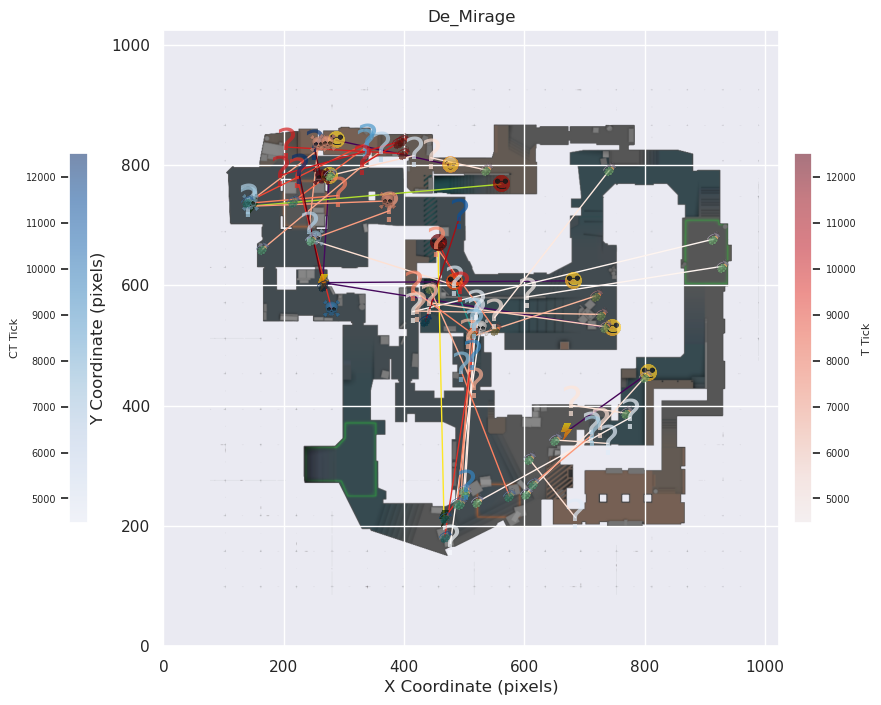

In [21]:
min_tick,max_tick = idx_r_df.loc[sel_idx][["start_tick","end_tick"]].values
print(min_tick,max_tick)

tf_f_co = transform_coords(map_data,
                          idx_f_df.loc[sel_idx],
                         ["attacker","player"])
transformed_flash = transform_actions(tf_f_co,
                 ["attacker","player"],
                 {"player" : ["flash_duration",]},
                 {"attacker" : "flasher","player" : "flashee"},
                  check_dup_without_cols=["status","flash_duration","attacker_side","player_side"],
                  assign_dup={"status":"both"},
                 common_extra_cols = ["tick"],
                 )

tf_k_co = transform_coords(map_data,idx_k_df.loc[sel_idx],["attacker","victim"])
transformed_kills = transform_actions(tf_k_co,
                 ["attacker","victim"],
                  check_dup_without_cols=["attacker_side","victim_side"],
                  assign_dup={"status":"suicide"},
                 common_extra_cols = ["tick"],
                )
                                      
tf_g_co = transform_coords(map_data,idx_g_df.loc[sel_idx],["thrower","grenade"])
transformed_grenades = transform_actions(tf_g_co,
                 ["thrower","grenade"],
                 common_extra_cols = ["throw_tick"],
                                     )
side_color = {
    "ct" : "Blues",
    "t" : "Reds"
}

flash_marker = {
    "flasher" : "https://cdn-icons-png.flaticon.com/512/3649/3649458.png",
    "flashee" : "https://cdn4.iconfinder.com/data/icons/emoji-18/61/13-512.png",
    "both" : "https://emojiisland.com/cdn/shop/products/Wink_Emoji_large.png"
}

kill_marker = {
    "attacker" : "https://static-00.iconduck.com/assets.00/pistol-emoji-2048x1650-x46ulhj0.png",
    "victim" : "https://emojiisland.com/cdn/shop/products/Pirate_Skull_Emoji_Icon_b77a0005-472e-41e4-ad15-fd871038f91e_grande.png",
    "suicide" : "https://pbs.twimg.com/media/FGH6ar9X0AM4JY1.png"
}

grenade_marker = {
    "thrower" : "https://cdn-icons-png.flaticon.com/512/7030/7030865.png",
    "grenade" : "https://static-00.iconduck.com/assets.00/collision-symbol-emoji-2048x2048-4kgjmnh8.png",
}

img_fig, img_ax = plot_map(selected_map, (10, 8))

flash_fig, flash_ax = plot_loc_img_unicode(transformed_flash, 
                                      gradient_by="tick", 
                                      size=30,
                                      color_by="side",
                                      color_dict=side_color,
                                      marker_by="status",
                                      marker_dict=flash_marker,
                                      alpha=0.7,
                                      fig=img_fig, 
                                      ax=img_ax)

cf_fig,cf_ax = plot_line(tf_f_co,"attacker","player","tick",default_color="viridis",fig=flash_fig,ax=flash_ax)      

kill_fig, kill_ax = plot_loc_img_unicode(transformed_kills, 
                                      gradient_by="tick", 
                                      size=30,
                                      color_by="side",
                                      color_dict=side_color,
                                      marker_by="status",
                                      marker_dict=kill_marker,
                                      alpha=0.7,
                                      fig=cf_fig, 
                                      ax=cf_ax)

ck_fig,ck_ax = plot_line(tf_k_co,"attacker","victim","tick",default_color="Reds",fig=kill_fig,ax=kill_ax)      
grenade_fig, grenade_ax = plot_loc_img_unicode(transformed_grenades, 
                                      gradient_by="throw_tick", 
                                      size=30,
                                      color_by="side",
                                      color_dict=side_color,
                                      marker_by="status",
                                      marker_dict=grenade_marker,
                                      alpha=0.7,
                                      fig=ck_fig, 
                                      ax=ck_ax)

cg_fig,cg_ax = plot_line(tf_g_co,"thrower","grenade","throw_tick",default_color="Reds",fig=grenade_fig,ax=grenade_ax)      
plt.show()

steam_id      name  \
match_id                             round_num                                
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          76561198004854956   dupreeh   
                                     5          76561198113666193     ZywOo   
                                     5          76561197989744167      apEX   
                                     5          76561198081528911  misutaaa   
                                     5          76561197983956651    Magisk   
...                                                           ...       ...   
                                     5          76561198004115516    cadiaN   
                                     5          76561198160709585    sjuush   
                                     5          76561198064864198   refrezh   
                                     5          76561197996678278     TeSeS   
                                     5          76561198022365638     stavn   

                                                    team side           x  \
match_id                             round_num                              
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          Vitality    T  873.655640   
                                     5          Vitality    T  887.069214   
                                     5          Vitality    T  904.028503   
                                     5          Vitality    T  926.019043   
                                     5          Vitality    T  920.666382   
...                                                  ...  ...         ...   
                                     5            Heroic   CT  143.831009   
                                     5            Heroic   CT  390.214355   
                                     5            Heroic   CT  279.211975   
                                     5            Heroic   CT  252.900024   
                                     5            Heroic   CT  279.591583   

                                                         y           z  \
match_id                             round_num                           
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          636.459656 -167.968750   
                                     5          684.103394 -163.968750   
                                     5          617.165894 -167.347809   
                                     5          624.055847 -167.968750   
                                     5          678.081238 -167.968750   
...                                                    ...         ...   
                                     5          736.607056 -167.968750   
                                     5          732.689697 -166.622925   
                                     5          573.197205 -167.968750   
                                     5          678.815491 -165.718750   
                                     5          560.860352 -167.968750   

                                                velocity_x  velocity_y  \
match_id                             round_num                           
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5           14.235688  195.038834   
                                     5          -66.613457  183.862259   
                                     5          -36.505558  192.120132   
                                     5          146.601196  115.521111   
                                     5          -16.525360   -3.677849   
...                                                    ...         ...   
                                     5           -2.420143  -18.378748   
                                     5            0.000000    0.000000   
                                     5           -2.472856  -18.777624   
                                     5           -2.367388  -17.979877   
                                     5            0.000000    0.000000   

                                                velocity_z  ...  \
match_id                          

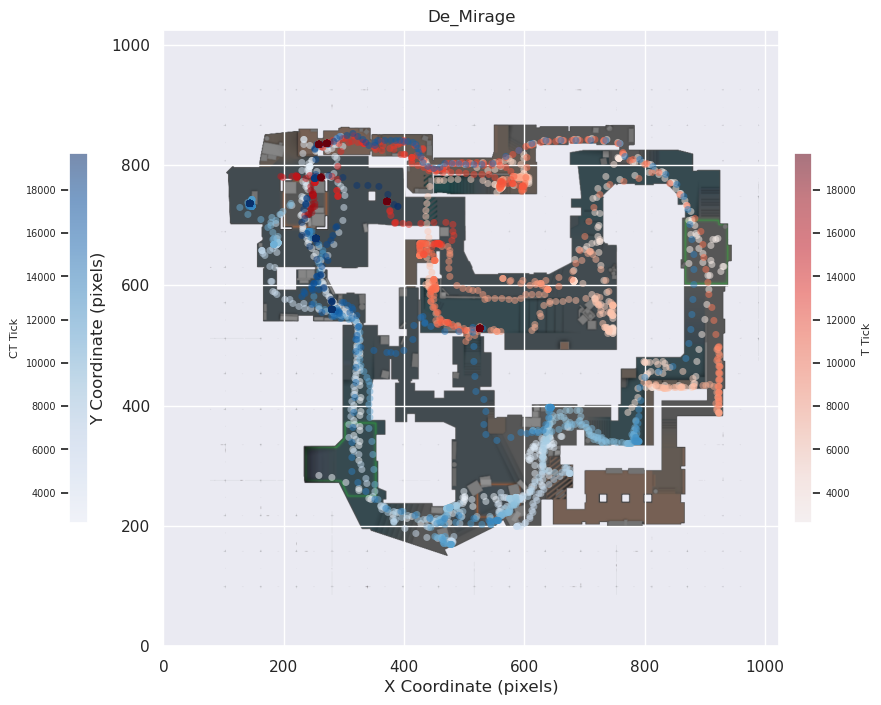

In [22]:
transformed_loc = transform_coord(map_data,
                                  idx_pf_df.loc[sel_idx])

display(transformed_loc)
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))

loc_fig, loc_ax = plot_loc_img_unicode(transformed_loc, 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

tick side           steam_id  \
match_id                             round_num                                  
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5           2594    T  76561198004854956   
                                     5           2594    T  76561198113666193   
                                     5           2594    T  76561197989744167   
                                     5           2594    T  76561198081528911   
                                     5           2594    T  76561197983956651   
...                                               ...  ...                ...   
                                     5          19692   CT  76561198004115516   
                                     5          19692   CT  76561198160709585   
                                     5          19692   CT  76561198064864198   
                                     5          19692   CT  76561197996678278   
                                     5          19692   CT  76561198022365638   

                                                         x           y  
match_id                             round_num                          
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          873.655640  636.459656  
                                     5          887.069214  684.103394  
                                     5          904.028503  617.165894  
                                     5          926.019043  624.055847  
                                     5          920.666382  678.081238  
...                                                    ...         ...  
                                     5          143.831009  736.607056  
                                     5          390.214355  732.689697  
                                     5          279.211975  573.197205  
                                     5          252.900024  678.815491  
                                     5          279.591583  560.860352  

[2680 rows x 5 columns]

index 532 is out of bounds for axis 0 with size 17
index 11 is out of bounds for axis 0 with size 6
index 684 is out of bounds for axis 0 with size 28
index 173 is out of bounds for axis 0 with size 13


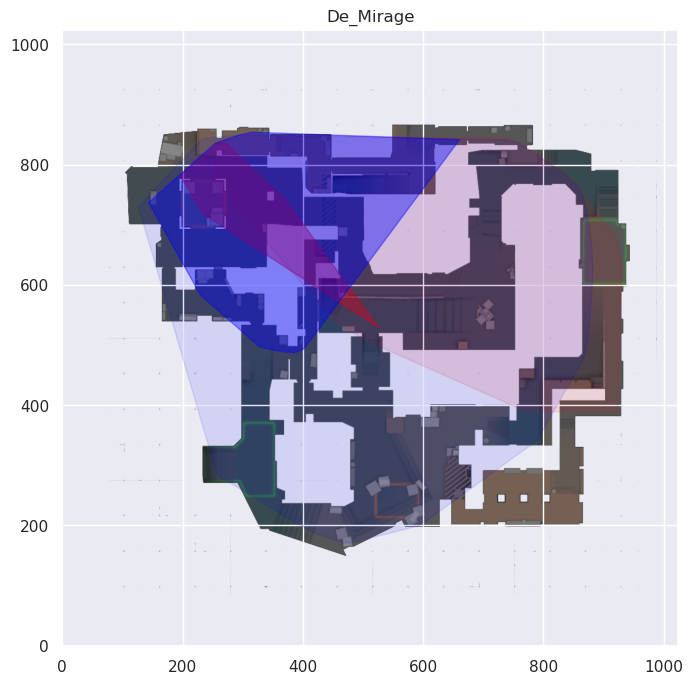

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import ConvexHull # For convex hull calculations
import os



fig,ax =  plot_map(selected_map, (10, 8))

tf_loc = transformed_loc[["tick","side","steam_id","x","y"]]
display(tf_loc)

min_time,max_time = tf_loc.tick.min(),tf_loc.tick.max()

time_interval = 12800
time_points = np.arange(min_time,max_time+time_interval,time_interval)

for side in tf_loc.side.unique():
    side_players = tf_loc[tf_loc["side"]==side]
    team_color = side_color.get(side.lower(),'greens').lower()[:-1]
    for time in time_points:
        time_window_df = side_players[
                (side_players['tick'] >= time) &
                (side_players['tick'] < time + time_interval)
            ]
        points = time_window_df[['x', 'y']].values

            # Only calculate hull if there are at least 3 distinct points
        if len(points) >= 3 and len(np.unique(points, axis=0)) >= 3: # Check for distinct points too
            try:
                hull = ConvexHull(points)
                # Get vertices of the hull in order
                hull_points = points[hull.vertices]
                # Plot the convex hull as a filled polygon
                ax.fill(hull_points[:,0], hull_points[:,1],
                        color=team_color,
                        alpha=0.1 + 0.4 * (time - min_time) / (max_time - min_time + 1e-9), # Fade in over time
                        zorder=2) # Hull over individual paths but under centroid/markers

                # Optional: Plot the hull's boundary for clearer shape
                ax.plot(hull_points[np.append(hull.vertices, hull.vertices[0]), 0],
                        hull_points[np.append(hull.vertices, hull.vertices[0]), 1],
                        color=team_color,
                        linewidth=1, linestyle='--', alpha=0.5, zorder=2)
            except Exception as e:
                print(e)
                pass
        elif len(points) > 0: # If 1 or 2 points, plot as scatter/line (no hull)
            ax.scatter(points[:,0], points[:,1], color=team_color, s=50, alpha=0.2 + 0.3 * (current_time - min_time) / (max_time - min_time + 1e-9), zorder=2)
        
    

### cluster evolution

In [24]:
def eu_dist(x1,y1,x2,y2):
    return np.sqrt((x2-x1)**2+(y2-y1)**2)

In [25]:
from scipy.cluster.hierarchy import fcluster,linkage
result = pd.DataFrame()
distance_threshold = 100
sample_rate = 50

vmin = tf_loc["tick"].min()
vmax = tf_loc["tick"].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)

marker_styles = ["o","|","^","s","p"]

filter_nan = lambda l : [item for item in l if not pd.isna(item)]

for tick in tf_loc.tick.unique()[::sample_rate]:
    for side in tf_loc.side.unique():
        tick_side_players = tf_loc[(tf_loc.tick == tick) & (tf_loc.side == side)][["tick","side","x","y","steam_id"]]
        z = linkage(tick_side_players[["x","y"]].values,method="ward",metric="euclidean")
        c_label = fcluster(z, t=distance_threshold, criterion='distance')
        tick_side_players["cluster"] = c_label
        tick_side_players[["start","end"]] = [tick,tick]
        clsdf = tick_side_players.groupby(["tick","side","cluster"],observed=True).agg(x=('x',"mean"),y=("y","mean"),
                                                                                       size=("steam_id","count"),
                                                                                       start=("start","mean"),end=("end","mean")).dropna(how='all')
        for c in np.unique(c_label):
            pc = tick_side_players[tick_side_players.cluster == c].reset_index()["steam_id"].to_list()
            pc = pc + [np.nan]*(5-len(pc))
            clsdf.loc[(tick,side,c),[f"p{i}" for i in range(1,6)]] = pc
            
        result = pd.concat([result,clsdf])
        
result.dropna(subset=["x","y"],inplace=True)
time_points = result.index.get_level_values(0).unique().to_list()

new_result = result.copy()
new_result["show"] = True

In [26]:
# result_dict = {
#     "CT" : [],
#     "T" : []
# }
# for tick in tf_loc.tick.unique()[::50]:
#     for side in tf_loc.side.unique():
#         tick_side_players = tf_loc[(tf_loc.tick == tick) & (tf_loc.side == side)][["tick","side","x","y","steam_id"]]
#         z = linkage(tick_side_players[["x","y"]].values,method="ward",metric="euclidean")
#         c_label = fcluster(z, t=distance_threshold, criterion='distance')
#         tick_side_players["cluster"] = c_label

#         clsdf = tick_side_players.groupby(["tick","side","cluster"],observed=True).agg(x=('x',"mean"),y=("y","mean"),
#                                                                                        size=("steam_id","count")).dropna(how='all')

#         cls_dict = clsdf.T.to_dict()
#         for c in np.unique(c_label):
#             pc = tick_side_players[tick_side_players.cluster == c].reset_index()["steam_id"].to_list()
#             cls_dict[(tick,side,c)]["players"] = pc

#         for (tick,side,c),value in cls_dict.items():
#             result_dict[side].append({
#                 f"{tick}_{c}" : value
#             })
            
# display(result_dict)

In [27]:
# with pd.option_context("display.max_rows",None):
#     display(result)
display(result.tail(40))

x           y  size    start      end  \
tick  side cluster                                                   
2594  T    1        902.287781  647.973206     5   2594.0   2594.0   
      CT   1        309.624359  305.343903     5   2594.0   2594.0   
5794  T    1        437.496887  736.937622     1   5794.0   5794.0   
           2        602.750122  781.814453     1   5794.0   5794.0   
           3        743.434204  539.468750     2   5794.0   5794.0   
           4        867.125000  430.600098     1   5794.0   5794.0   
      CT   1        235.800873  582.387817     2   5794.0   5794.0   
           2        609.766724  255.686401     2   5794.0   5794.0   
           3        381.753296  212.506470     1   5794.0   5794.0   
8994  T    1        475.582336  658.728210     1   8994.0   8994.0   
           2        478.692444  536.165894     1   8994.0   8994.0   
           3        638.894775  593.445862     1   8994.0   8994.0   
           4        560.817627  765.291870     1   8994.0   8994.0   
           5        919.275696  493.520813     1   8994.0   8994.0   
      CT   1        654.786743  381.737305     2   8994.0   8994.0   
           2        471.258942  229.222473     1   8994.0   8994.0   
           3        577.073914  246.614380     1   8994.0   8994.0   
           4        190.685257  672.053406     1   8994.0   8994.0   
12194 T    1        572.402283  796.224365     3  12194.0  12194.0   
           2        436.135162  657.693848     1  12194.0  12194.0   
           3        526.539429  528.613464     1  12194.0  12194.0   
      CT   1        324.843536  533.136353     1  12194.0  12194.0   
           2        147.199753  739.846069     1  12194.0  12194.0   
           3        641.268555  397.753784     1  12194.0  12194.0   
           4        784.171448  347.990540     1  12194.0  12194.0   
           5        464.142151  175.704285     1  12194.0  12194.0   
15394 T    1        257.626007  818.120850     3  15394.0  15394.0   
           2        371.830566  740.210205     1  15394.0  15394.0   
           3        526.539429  528.613464     1  15394.0  15394.0   
      CT   1        252.900024  678.815491     1  15394.0  15394.0   
           2        143.831009  736.607056     1  15394.0  15394.0   
           3        434.819031  538.802063     1  15394.0  15394.0   
           4        295.175110  545.565857     1  15394.0  15394.0   
           5        660.588623  841.371338     1  15394.0  15394.0   
18594 T    1        263.618591  816.875793     3  18594.0  18594.0   
           2        371.830566  740.210205     1  18594.0  18594.0   
           3        526.539429  528.613464     1  18594.0  18594.0   
      CT   1        246.808044  731.159668     3  18594.0  18594.0   
           2        143.831009  736.607056     1  18594.0  18594.0   
           3        279.591583  560.860352     1  18594.0  18594.0   

                              p1            p2            p3            p4  \
tick  side cluster                                                           
2594  T    1        7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   
      CT   1        7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   
5794  T    1        7.656120e+16           NaN           NaN           NaN   
           2        7.656120e+16           NaN           NaN           NaN   
           3        7.656120e+16  7.656120e+16           NaN           NaN   
           4        7.656120e+16           NaN           NaN           NaN   
      CT   1        7.656120e+16  7.656120e+16           NaN           NaN   
           2        7.656120e+16  7.656120e+16           NaN           NaN   
           3        7.656120e+16           NaN           NaN           NaN   
8994  T    1        7.656120e+16           NaN           NaN           NaN   
           2        7.656120e+16           NaN           NaN           NaN   
           3        7.656120e+16           NaN           NaN           NaN

In [28]:
def get_cluster_lineage(result_df, tick, side, cluster, time_points=time_points):
    
    """
    Trace the lineage of a cluster back through time based on exact player match
    """
    result = []
    if tick == time_points[0]:
        return result
    
    current_data = result_df.loc[(tick, side, cluster)]
    current_players = set(filter_nan(current_data[5:-1]))  # Players are in positions 3+

    if current_data["start"] != current_data["end"]:
        prev_tick = current_data["start"]
    else:
        prev_tick = time_points[time_points.index(tick) - 1]
    prev_clusters = result_df.loc[(prev_tick, side)]
    
    prev_points = []
    # Find previous cluster with exact player match
    for prev_cluster_id, prev_data in prev_clusters.iterrows():
        prev_players = set(filter_nan(prev_data[5:-1]))

        if (prev_players == current_players):
            prev_points.append((prev_tick,side,prev_cluster_id))
            if eu_dist(*prev_data[:2],*current_data[:2]) < distance_threshold:
                result.extend(get_cluster_lineage(result_df,prev_tick,side,prev_cluster_id))
        elif current_players.intersection(prev_players):
            prev_points.append((prev_tick,side,prev_cluster_id))

    
    if prev_points:
        result.append(prev_points)
    return result

# get_cluster_lineage(result,time_points[-1],"CT",1)

In [29]:
new_result.shape

(40, 11)

In [30]:
from pandas.errors import InvalidIndexError

to_delete_indices = set()
for idx,row in new_result[::-1].iterrows():
    lineage = get_cluster_lineage(new_result,*idx)

    if lineage and len(lineage) > 1:
        trace_idx = [idx] + [i[0] for i in lineage]
        display(new_result[new_result.index.isin(trace_idx)])
        first_group_cluster = new_result.loc[lineage[0][0]]
        new_result.loc[idx,"start"] = first_group_cluster.start

        to_delete_indices.update([i[0] for i in lineage[1:]])

mask = ~new_result.index.isin(to_delete_indices)
new_result["show"] = mask

,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
12194,CT,5,464.142151,175.704285,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True
15394,CT,4,295.175110,545.565857,1,15394.0,15394.0,7.656120e+16,NaN,NaN,NaN,NaN,True
18594,CT,3,279.591583,560.860352,1,18594.0,18594.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
5794,CT,1,235.800873,582.387817,2,5794.0,5794.0,7.656120e+16,7.656120e+16,NaN,NaN,NaN,True
8994,CT,4,190.685257,672.053406,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True
12194,CT,2,147.199753,739.846069,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True
15394,CT,2,143.831009,736.607056,1,15394.0,15394.0,7.656120e+16,NaN,NaN,NaN,NaN,True
18594,CT,2,143.831009,736.607056,1,18594.0,18594.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
5794,T,1,437.496887,736.937622,1,5794.0,5794.0,7.656120e+16,NaN,NaN,NaN,NaN,True
8994,T,2,478.692444,536.165894,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True
12194,T,3,526.539429,528.613464,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True
15394,T,3,526.539429,528.613464,1,15394.0,15394.0,7.656120e+16,NaN,NaN,NaN,NaN,True
18594,T,3,526.539429,528.613464,1,18594.0,18594.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
12194,T,2,436.135162,657.693848,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True
15394,T,2,371.830566,740.210205,1,15394.0,15394.0,7.656120e+16,NaN,NaN,NaN,NaN,True
18594,T,2,371.830566,740.210205,1,18594.0,18594.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
12194,T,1,572.402283,796.224365,3,12194.0,12194.0,7.656120e+16,7.656120e+16,7.656120e+16,NaN,NaN,True
15394,T,1,257.626007,818.120850,3,15394.0,15394.0,7.656120e+16,7.656120e+16,7.656120e+16,NaN,NaN,True
18594,T,1,263.618591,816.875793,3,18594.0,18594.0,7.656120e+16,7.656120e+16,7.656120e+16,NaN,NaN,True


...

,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
5794,CT,1,235.800873,582.387817,2,5794.0,5794.0,7.656120e+16,7.656120e+16,NaN,NaN,NaN,True
8994,CT,4,190.685257,672.053406,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True
12194,CT,2,147.199753,739.846069,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
5794,T,1,437.496887,736.937622,1,5794.0,5794.0,7.656120e+16,NaN,NaN,NaN,NaN,True
8994,T,2,478.692444,536.165894,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True
12194,T,3,526.539429,528.613464,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
5794,T,3,743.434204,539.468750,2,5794.0,5794.0,7.656120e+16,7.656120e+16,NaN,NaN,NaN,True
8994,T,1,475.582336,658.728210,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True
12194,T,2,436.135162,657.693848,1,12194.0,12194.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
2594,T,1,902.287781,647.973206,5,2594.0,2594.0,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16,True
5794,T,4,867.125000,430.600098,1,5794.0,5794.0,7.656120e+16,NaN,NaN,NaN,NaN,True
8994,T,5,919.275696,493.520813,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True


,,,x,y,size,start,end,p1,p2,p3,p4,p5,show
tick,side,cluster,,,,,,,,,,,
2594,T,1,902.287781,647.973206,5,2594.0,2594.0,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16,True
5794,T,2,602.750122,781.814453,1,5794.0,5794.0,7.656120e+16,NaN,NaN,NaN,NaN,True
8994,T,4,560.817627,765.291870,1,8994.0,8994.0,7.656120e+16,NaN,NaN,NaN,NaN,True


In [31]:
with pd.option_context("display.max_rows",None):
    display(new_result)

x           y  size    start      end  \
tick  side cluster                                                   
2594  T    1        902.287781  647.973206     5   2594.0   2594.0   
      CT   1        309.624359  305.343903     5   2594.0   2594.0   
5794  T    1        437.496887  736.937622     1   5794.0   5794.0   
           2        602.750122  781.814453     1   5794.0   5794.0   
           3        743.434204  539.468750     2   5794.0   5794.0   
           4        867.125000  430.600098     1   5794.0   5794.0   
      CT   1        235.800873  582.387817     2   5794.0   5794.0   
           2        609.766724  255.686401     2   5794.0   5794.0   
           3        381.753296  212.506470     1   5794.0   5794.0   
8994  T    1        475.582336  658.728210     1   8994.0   8994.0   
           2        478.692444  536.165894     1   8994.0   8994.0   
           3        638.894775  593.445862     1   8994.0   8994.0   
           4        560.817627  765.291870     1   2594.0   8994.0   
           5        919.275696  493.520813     1   2594.0   8994.0   
      CT   1        654.786743  381.737305     2   8994.0   8994.0   
           2        471.258942  229.222473     1   8994.0   8994.0   
           3        577.073914  246.614380     1   8994.0   8994.0   
           4        190.685257  672.053406     1   8994.0   8994.0   
12194 T    1        572.402283  796.224365     3  12194.0  12194.0   
           2        436.135162  657.693848     1   5794.0  12194.0   
           3        526.539429  528.613464     1   5794.0  12194.0   
      CT   1        324.843536  533.136353     1  12194.0  12194.0   
           2        147.199753  739.846069     1   5794.0  12194.0   
           3        641.268555  397.753784     1  12194.0  12194.0   
           4        784.171448  347.990540     1  12194.0  12194.0   
           5        464.142151  175.704285     1  12194.0  12194.0   
15394 T    1        257.626007  818.120850     3  15394.0  15394.0   
           2        371.830566  740.210205     1  15394.0  15394.0   
           3        526.539429  528.613464     1   5794.0  15394.0   
      CT   1        252.900024  678.815491     1  15394.0  15394.0   
           2        143.831009  736.607056     1   5794.0  15394.0   
           3        434.819031  538.802063     1  15394.0  15394.0   
           4        295.175110  545.565857     1  15394.0  15394.0   
           5        660.588623  841.371338     1  15394.0  15394.0   
18594 T    1        263.618591  816.875793     3  12194.0  18594.0   
           2        371.830566  740.210205     1  12194.0  18594.0   
           3        526.539429  528.613464     1   5794.0  18594.0   
      CT   1        246.808044  731.159668     3  18594.0  18594.0   
           2        143.831009  736.607056     1   5794.0  18594.0   
           3        279.591583  560.860352     1  12194.0  18594.0   

                              p1            p2            p3            p4  \
tick  side cluster                                                           
2594  T    1        7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   
      CT   1        7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   
5794  T    1        7.656120e+16           NaN           NaN           NaN   
           2        7.656120e+16           NaN           NaN           NaN   
           3        7.656120e+16  7.656120e+16           NaN           NaN   
           4        7.656120e+16           NaN           NaN           NaN   
      CT   1        7.656120e+16  7.656120e+16           NaN           NaN   
           2        7.656120e+16  7.656120e+16           NaN           NaN   
           3        7.656120e+16           NaN           NaN           NaN   
8994  T    1        7.656120e+16           NaN           NaN           NaN   
           2        7.656120e+16           NaN           NaN           NaN   
           3        7.656120e+16           NaN           NaN           NaN

<Axes: xlabel='show'>

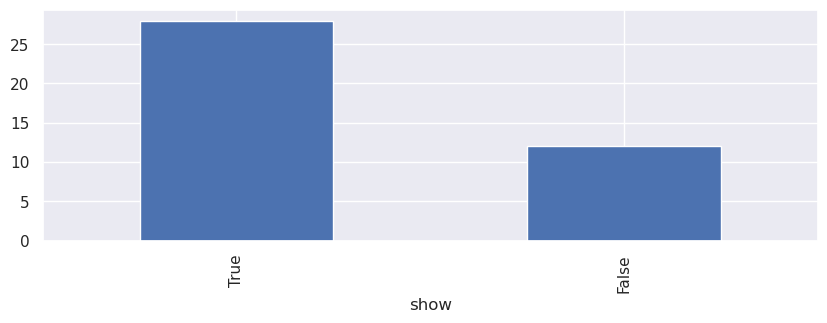

In [32]:
new_result.show.value_counts().plot.bar()

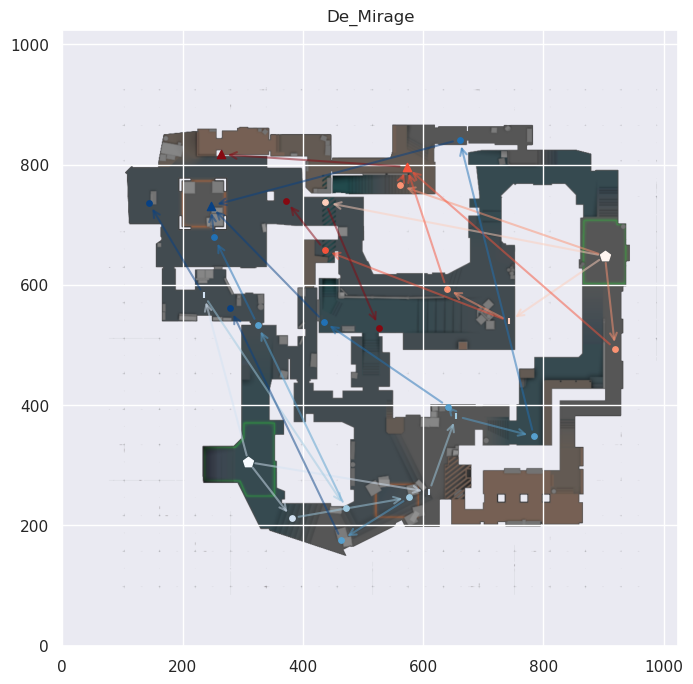

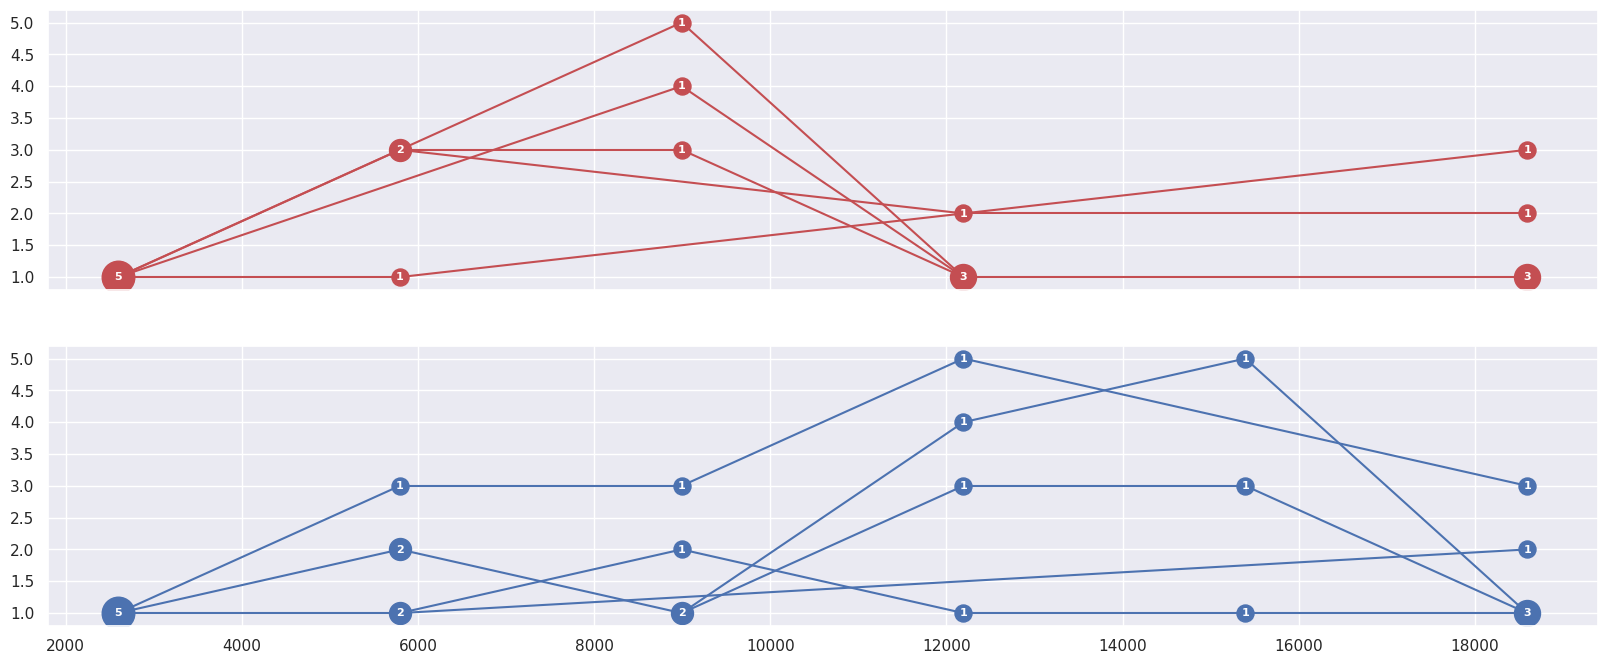

In [33]:
img_fig,ax = plot_map(selected_map,(10,8))
fig, axes = plt.subplots(2, 1, figsize=(20,8), sharex=True)
side_single_color = {"CT" : "b","T":"r"}

connections = set()
for (tick,side,c),(x,y,size,*p,show) in new_result.iterrows():
    color = plt.get_cmap(side_color[side.lower()])(norm(tick))

    if show:
        ax.scatter(x,y,color=color,marker=marker_styles[int(size)-1],s=5 + size*10)
        axes[len(side)-1].scatter(tick,c,s=50 + size*100,color=side_single_color[side])
        axes[len(side)-1].annotate(f'{size}', (tick, c), xytext=(0, 0), 
                           textcoords='offset points', ha='center', va='center',
                           fontsize=8, fontweight='bold', color='white')
        
        lineage = get_cluster_lineage(new_result,tick,side,c)
        if lineage:
            lineage = lineage[0]

        for prev_tick, prev_side, prev_c in list(lineage):
            prev_data = new_result.loc[(prev_tick, prev_side, prev_c)]
            prev_x, prev_y = prev_data[:2]
            
            ax.annotate('', xy=(x, y), xytext=(prev_x, prev_y),
                       arrowprops=dict(arrowstyle='->', 
                                      color=color, 
                                      alpha=0.5,
                                      lw=1.5,
                                      shrinkA=5,
                                      shrinkB=5))
            axes[len(side)-1].plot([prev_tick,tick],[prev_c,c],color=side_single_color[side])


### trying leiden algo

In [34]:
import networkx as nx,igraph as ig
import leidenalg as la

In [35]:
tf_loc

tick side           steam_id  \
match_id                             round_num                                  
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5           2594    T  76561198004854956   
                                     5           2594    T  76561198113666193   
                                     5           2594    T  76561197989744167   
                                     5           2594    T  76561198081528911   
                                     5           2594    T  76561197983956651   
...                                               ...  ...                ...   
                                     5          19692   CT  76561198004115516   
                                     5          19692   CT  76561198160709585   
                                     5          19692   CT  76561198064864198   
                                     5          19692   CT  76561197996678278   
                                     5          19692   CT  76561198022365638   

                                                         x           y  
match_id                             round_num                          
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          873.655640  636.459656  
                                     5          887.069214  684.103394  
                                     5          904.028503  617.165894  
                                     5          926.019043  624.055847  
                                     5          920.666382  678.081238  
...                                                    ...         ...  
                                     5          143.831009  736.607056  
                                     5          390.214355  732.689697  
                                     5          279.211975  573.197205  
                                     5          252.900024  678.815491  
                                     5          279.591583  560.860352  

[2680 rows x 5 columns]

In [36]:
import pandas as pd
import numpy as np
import igraph as ig    # Import igraph
import leidenalg as la # Import leidenalg



distance_threshold = 100
epsilon = 1e-6
leiden_resolution = 1.0 # Resolution parameter for Leiden
sampling_rate = 50

tick_partitions = {}
all_ticks = sorted(tf_loc['tick'].unique())
all_ticks = all_ticks[::sampling_rate]

# --- Loop through each tick ---
for tick in all_ticks:
    tick_df = tf_loc[tf_loc['tick'] == tick].copy()
    
    players_in_tick = tick_df['steam_id'].unique()
    
    # --- Prepare edge data for igraph.Graph.TupleList ---
    # We will store (source_steam_id, target_steam_id, weight) directly
    edges_and_weights_for_igraph = []
    
    pos_data = tick_df.set_index('steam_id')[['x', 'y', 'side']].to_dict('index')

    for i in range(len(players_in_tick)):
        player_a_id = players_in_tick[i]
        
        # Ensure player_a is present in pos_data for this tick
        if player_a_id not in pos_data:
            continue
            
        for j in range(i+1,len(players_in_tick)):
            player_b_id = players_in_tick[j]
            
            # Ensure player_b is present in pos_data and on the same side as player_a
            if player_b_id not in pos_data or pos_data[player_a_id]['side'] != pos_data[player_b_id]['side']:
                continue
            
            # Calculate distance
            coords_a = np.array([pos_data[player_a_id]['x'], pos_data[player_a_id]['y']])
            coords_b = np.array([pos_data[player_b_id]['x'], pos_data[player_b_id]['y']])
            dist = np.linalg.norm(coords_a - coords_b)
            
            # Add edge only if within distance_threshold
            if dist < distance_threshold:
                weight = 1.0 / (dist + epsilon) # Inverse distance as weight
                
                # Append the tuple (source_steam_id, target_steam_id, weight)
                edges_and_weights_for_igraph.append((player_a_id, player_b_id, weight))
    
    # --- Create igraph graph for the current tick ---
    current_tick_partition_dict = {}

    # If there are no edges, create a graph with just the players as isolated vertices
    if not edges_and_weights_for_igraph:
        g_ig_tick = ig.Graph(directed=False)
        g_ig_tick.add_vertices(list(players_in_tick)) # Add players as isolated vertices by their names
    else:
        # igraph.Graph.TupleList can directly take (source_name, target_name, weight) tuples
        # It automatically creates vertices and sets their 'name' attribute
        g_ig_tick = ig.Graph.TupleList(edges_and_weights_for_igraph, 
                                      directed=False, 
                                      weights=True)
        
        # Ensure all players are in the graph, even those with no connections
        # TupleList only adds vertices that appear in the edge list.
        # Add any missing isolated players explicitly.
        existing_names = set(v['name'] for v in g_ig_tick.vs)
        for player_id in players_in_tick:
            if player_id not in existing_names:
                g_ig_tick.add_vertex(name=player_id)
        
    # --- Apply Leiden algorithm ---
    if g_ig_tick.vcount() > 0: # Ensure there are players in the graph
        if g_ig_tick.ecount() > 0: # Ensure there are edges for meaningful communities
            partition_ig = la.find_partition(
                g_ig_tick,
                la.ModularityVertexPartition, 
                weights='weight',
            )
        else:
            # If no edges, each player is their own community.
            # Create a partition where each vertex is in its own community (membership = 0, 1, 2...)
            partition_ig = ig.VertexClustering(g_ig_tick, membership=list(range(g_ig_tick.vcount())))

        # Convert igraph's partition membership back to steam_id dictionary
        current_tick_partition_dict = {
            g_ig_tick.vs[i]['name']: partition_ig.membership[i] # g_ig_tick.vs[i]['name'] gives the steam_id string
            for i in range(g_ig_tick.vcount())
        }
    
    tick_partitions[tick] = current_tick_partition_dict


# Example of how to iterate and print a few partitions:
# print("\nSample Partitions:")
# for i, tick in enumerate(all_ticks[-5:]): # Print for the first 5 ticks
#     print(f"\nTick {tick}:")
#     if tick_partitions[tick]:
#         for player, community_id in sorted(tick_partitions[tick].items()):
#             print(f"  {player}: Community {community_id}")
#     else:
#         print("  No active player communities (or not enough players/edges).")



In [37]:
result = tf_loc.reset_index().drop(["match_id","round_num"],axis=1).set_index("tick")
for tick in all_ticks:
    result.loc[tick,"c"] = result.loc[tick,"steam_id"].map(tick_partitions[tick])
    

display(result)

,side,steam_id,x,y,c
tick,,,,,
2594,T,76561198004854956,873.655640,636.459656,1.0
2594,T,76561198113666193,887.069214,684.103394,1.0
2594,T,76561197989744167,904.028503,617.165894,1.0
2594,T,76561198081528911,926.019043,624.055847,1.0
2594,T,76561197983956651,920.666382,678.081238,1.0
...,...,...,...,...,...
19692,CT,76561198004115516,143.831009,736.607056,NaN
19692,CT,76561198160709585,390.214355,732.689697,NaN
19692,CT,76561198064864198,279.211975,573.197205,NaN


In [38]:
# img_loc_fig, img_loc_ax = plot_map(selected_map, (10, 8))


# tick_start, tick_end = 0,50
# windowed_df = result.iloc[tick_start*10:tick_end*10]

# side_marker = {"CT": "s", "T": "^"}

# unique_communities = sorted(windowed_df['c'].unique())
# # Create a colormap for communities
# community_colors = plt.cm.get_cmap('viridis', len(unique_communities))

# for idx, row in windowed_df.iterrows():
#     marker_for_side = side_marker.get(row['side'], 'o') # Default to circle if side not found
#     color_for_community = community_colors(unique_communities.index(row['c'])) # Get color from cmap
    
#     img_loc_ax.scatter(x=row['x'], y=row['y'],
#                        marker=marker_for_side,
#                        color=color_for_community,
#                        s=100, # Size of the marker
#                        edgecolor='black', # Add a border for visibility
#                        linewidth=0.5,
#                        alpha=0.8)

In [39]:
new_result = result.reset_index().groupby(["tick","side","c"],observed=True).agg(x=('x',"mean"),y=("y","mean"),
                                                                                       size=("steam_id","count"),
                                                                                       start=("tick","mean"),end=("tick","mean")).dropna(how='all')

new_result[["p1","p2","p3","p4","p5"]]=np.nan
for (tick,side,c),row in new_result.iterrows():
    c_players = result[(result.index == tick) & (result.side == side) & (result.c == c)]["steam_id"].to_list()
    new_result.loc[(tick,side,c),[f"p{i}" for i in range(1,len(c_players)+1)]] = c_players

new_result["show"] = True

In [40]:
new_result

x           y  size    start      end            p1  \
tick  side c                                                                   
2594  CT   0.0  309.624359  305.343903     5   2594.0   2594.0  7.656120e+16   
      T    1.0  902.287781  647.973206     5   2594.0   2594.0  7.656120e+16   
5794  CT   1.0  609.766724  255.686401     2   5794.0   5794.0  7.656120e+16   
           2.0  235.800873  582.387817     2   5794.0   5794.0  7.656120e+16   
           6.0  381.753296  212.506470     1   5794.0   5794.0  7.656120e+16   
      T    0.0  743.434204  539.468750     2   5794.0   5794.0  7.656120e+16   
           3.0  437.496887  736.937622     1   5794.0   5794.0  7.656120e+16   
           4.0  867.125000  430.600098     1   5794.0   5794.0  7.656120e+16   
           5.0  602.750122  781.814453     1   5794.0   5794.0  7.656120e+16   
8994  CT   0.0  654.786743  381.737305     2   8994.0   8994.0  7.656120e+16   
           6.0  471.258942  229.222473     1   8994.0   8994.0  7.656120e+16   
           7.0  190.685257  672.053406     1   8994.0   8994.0  7.656120e+16   
           8.0  577.073914  246.614380     1   8994.0   8994.0  7.656120e+16   
      T    1.0  919.275696  493.520813     1   8994.0   8994.0  7.656120e+16   
           2.0  638.894775  593.445862     1   8994.0   8994.0  7.656120e+16   
           3.0  475.582336  658.728210     1   8994.0   8994.0  7.656120e+16   
           4.0  560.817627  765.291870     1   8994.0   8994.0  7.656120e+16   
           5.0  478.692444  536.165894     1   8994.0   8994.0  7.656120e+16   
12194 CT   3.0  324.843536  533.136353     1  12194.0  12194.0  7.656120e+16   
           4.0  147.199753  739.846069     1  12194.0  12194.0  7.656120e+16   
           5.0  464.142151  175.704285     1  12194.0  12194.0  7.656120e+16   
           6.0  641.268555  397.753784     1  12194.0  12194.0  7.656120e+16   
           7.0  784.171448  347.990540     1  12194.0  12194.0  7.656120e+16   
      T    0.0  572.402283  796.224365     3  12194.0  12194.0  7.656120e+16   
           1.0  436.135162  657.693848     1  12194.0  12194.0  7.656120e+16   
           2.0  526.539429  528.613464     1  12194.0  12194.0  7.656120e+16   
15394 CT   3.0  252.900024  678.815491     1  15394.0  15394.0  7.656120e+16   
           4.0  660.588623  841.371338     1  15394.0  15394.0  7.656120e+16   
           5.0  434.819031  538.802063     1  15394.0  15394.0  7.656120e+16   
           6.0  143.831009  736.607056     1  15394.0  15394.0  7.656120e+16   
           7.0  295.175110  545.565857     1  15394.0  15394.0  7.656120e+16   
      T    0.0  257.626007  818.120850     3  15394.0  15394.0  7.656120e+16   
           1.0  526.539429  528.613464     1  15394.0  15394.0  7.656120e+16   
           2.0  371.830566  740.210205     1  15394.0  15394.0  7.656120e+16   
18594 CT   0.0  221.063782  732.521545     4  18594.0  18594.0  7.656120e+16   
           4.0  279.591583  560.860352     1  18594.0  18594.0  7.656120e+16   
      T    1.0  263.618591  816.875793     3  18594.0  18594.0  7.656120e+16   
           2.0  371.830566  740.210205     1  18594.0  18594.0  7.656120e+16   
           3.0  526.539429  528.613464     1  18594.0  18594.0  7.656120e+16   

                          p2            p3            p4            p5  show  
tick  side c                                                                  
2594  CT   0.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16  True  
      T    1.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16  True  
5794  CT   1.0  7.656120e+16           NaN           NaN           NaN  True  
           2.0  7.656120e+16           NaN           NaN           NaN  True  
           6.0           NaN           NaN           NaN           NaN  True  
      T    0.0  7.656120e+16           NaN           NaN           NaN  True  
           3.0           NaN           NaN           NaN           NaN  True  
           4.0           NaN     

In [41]:
from pandas.errors import InvalidIndexError

time_points = new_result.index.get_level_values(0).unique().to_list()
def get_cluster_lineage(result_df, tick, side, cluster, time_points=time_points):
    
    """
    Trace the lineage of a cluster back through time based on exact player match
    """
    result = []
    if tick == time_points[0]:
        return result
    
    current_data = result_df.loc[(tick, side, cluster)]
    current_players = set(filter_nan(current_data[5:-1]))  # Players are in positions 3+

    
    if current_data["start"] != current_data["end"]:
        prev_tick = current_data["start"]
    else:
        prev_tick = time_points[time_points.index(tick) - 1]
    prev_clusters = result_df.loc[(prev_tick, side)]
    
    prev_points = []
    # Find previous cluster with exact player match
    for prev_cluster_id, prev_data in prev_clusters.iterrows():
        prev_players = set(filter_nan(prev_data[5:-1]))

        if (prev_players == current_players):
            prev_points.append((prev_tick,side,prev_cluster_id))
            if eu_dist(*prev_data[:2],*current_data[:2]) < distance_threshold:
                result.extend(get_cluster_lineage(result_df,prev_tick,side,prev_cluster_id))
        elif current_players.intersection(prev_players):
            prev_points.append((prev_tick,side,prev_cluster_id))

    
    if prev_points:
        result.append(prev_points)
    return result

# get_cluster_lineage(new_result,all_ticks[-1],"CT",1)

to_delete_indices = set()
for idx,row in new_result[::-1].iterrows():
    lineage = get_cluster_lineage(new_result,*idx)

    if lineage and len(lineage) > 1:
        trace_idx = [idx] + [i[0] for i in lineage]
        # display(new_result[new_result.index.isin(trace_idx)])
        first_group_cluster = new_result.loc[lineage[0][0]]
        new_result.loc[idx,"start"] = first_group_cluster.start

        to_delete_indices.update([i[0] for i in lineage[1:]])

mask = ~new_result.index.isin(to_delete_indices)
new_result["show"] = mask

In [42]:
new_result

x           y  size    start      end            p1  \
tick  side c                                                                   
2594  CT   0.0  309.624359  305.343903     5   2594.0   2594.0  7.656120e+16   
      T    1.0  902.287781  647.973206     5   2594.0   2594.0  7.656120e+16   
5794  CT   1.0  609.766724  255.686401     2   5794.0   5794.0  7.656120e+16   
           2.0  235.800873  582.387817     2   5794.0   5794.0  7.656120e+16   
           6.0  381.753296  212.506470     1   5794.0   5794.0  7.656120e+16   
      T    0.0  743.434204  539.468750     2   5794.0   5794.0  7.656120e+16   
           3.0  437.496887  736.937622     1   5794.0   5794.0  7.656120e+16   
           4.0  867.125000  430.600098     1   5794.0   5794.0  7.656120e+16   
           5.0  602.750122  781.814453     1   5794.0   5794.0  7.656120e+16   
8994  CT   0.0  654.786743  381.737305     2   8994.0   8994.0  7.656120e+16   
           6.0  471.258942  229.222473     1   8994.0   8994.0  7.656120e+16   
           7.0  190.685257  672.053406     1   8994.0   8994.0  7.656120e+16   
           8.0  577.073914  246.614380     1   8994.0   8994.0  7.656120e+16   
      T    1.0  919.275696  493.520813     1   2594.0   8994.0  7.656120e+16   
           2.0  638.894775  593.445862     1   8994.0   8994.0  7.656120e+16   
           3.0  475.582336  658.728210     1   8994.0   8994.0  7.656120e+16   
           4.0  560.817627  765.291870     1   2594.0   8994.0  7.656120e+16   
           5.0  478.692444  536.165894     1   8994.0   8994.0  7.656120e+16   
12194 CT   3.0  324.843536  533.136353     1  12194.0  12194.0  7.656120e+16   
           4.0  147.199753  739.846069     1   5794.0  12194.0  7.656120e+16   
           5.0  464.142151  175.704285     1  12194.0  12194.0  7.656120e+16   
           6.0  641.268555  397.753784     1  12194.0  12194.0  7.656120e+16   
           7.0  784.171448  347.990540     1  12194.0  12194.0  7.656120e+16   
      T    0.0  572.402283  796.224365     3  12194.0  12194.0  7.656120e+16   
           1.0  436.135162  657.693848     1   5794.0  12194.0  7.656120e+16   
           2.0  526.539429  528.613464     1   5794.0  12194.0  7.656120e+16   
15394 CT   3.0  252.900024  678.815491     1  15394.0  15394.0  7.656120e+16   
           4.0  660.588623  841.371338     1  15394.0  15394.0  7.656120e+16   
           5.0  434.819031  538.802063     1  15394.0  15394.0  7.656120e+16   
           6.0  143.831009  736.607056     1   5794.0  15394.0  7.656120e+16   
           7.0  295.175110  545.565857     1  15394.0  15394.0  7.656120e+16   
      T    0.0  257.626007  818.120850     3  15394.0  15394.0  7.656120e+16   
           1.0  526.539429  528.613464     1   5794.0  15394.0  7.656120e+16   
           2.0  371.830566  740.210205     1  15394.0  15394.0  7.656120e+16   
18594 CT   0.0  221.063782  732.521545     4  18594.0  18594.0  7.656120e+16   
           4.0  279.591583  560.860352     1  12194.0  18594.0  7.656120e+16   
      T    1.0  263.618591  816.875793     3  12194.0  18594.0  7.656120e+16   
           2.0  371.830566  740.210205     1  12194.0  18594.0  7.656120e+16   
           3.0  526.539429  528.613464     1   5794.0  18594.0  7.656120e+16   

                          p2            p3            p4            p5   show  
tick  side c                                                                   
2594  CT   0.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   True  
      T    1.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16   True  
5794  CT   1.0  7.656120e+16           NaN           NaN           NaN   True  
           2.0  7.656120e+16           NaN           NaN           NaN   True  
           6.0           NaN           NaN           NaN           NaN   True  
      T    0.0  7.656120e+16           NaN           NaN           NaN   True  
           3.0           NaN           NaN           NaN           NaN   True  
           4.0          

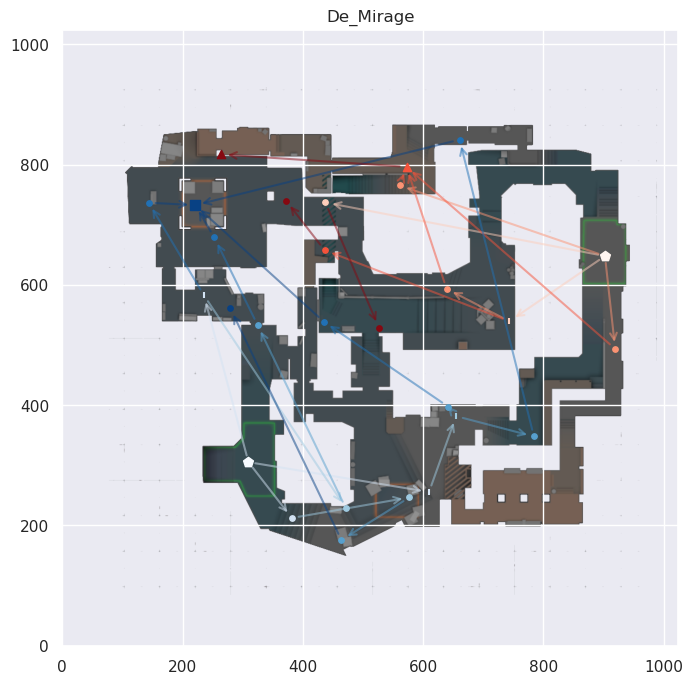

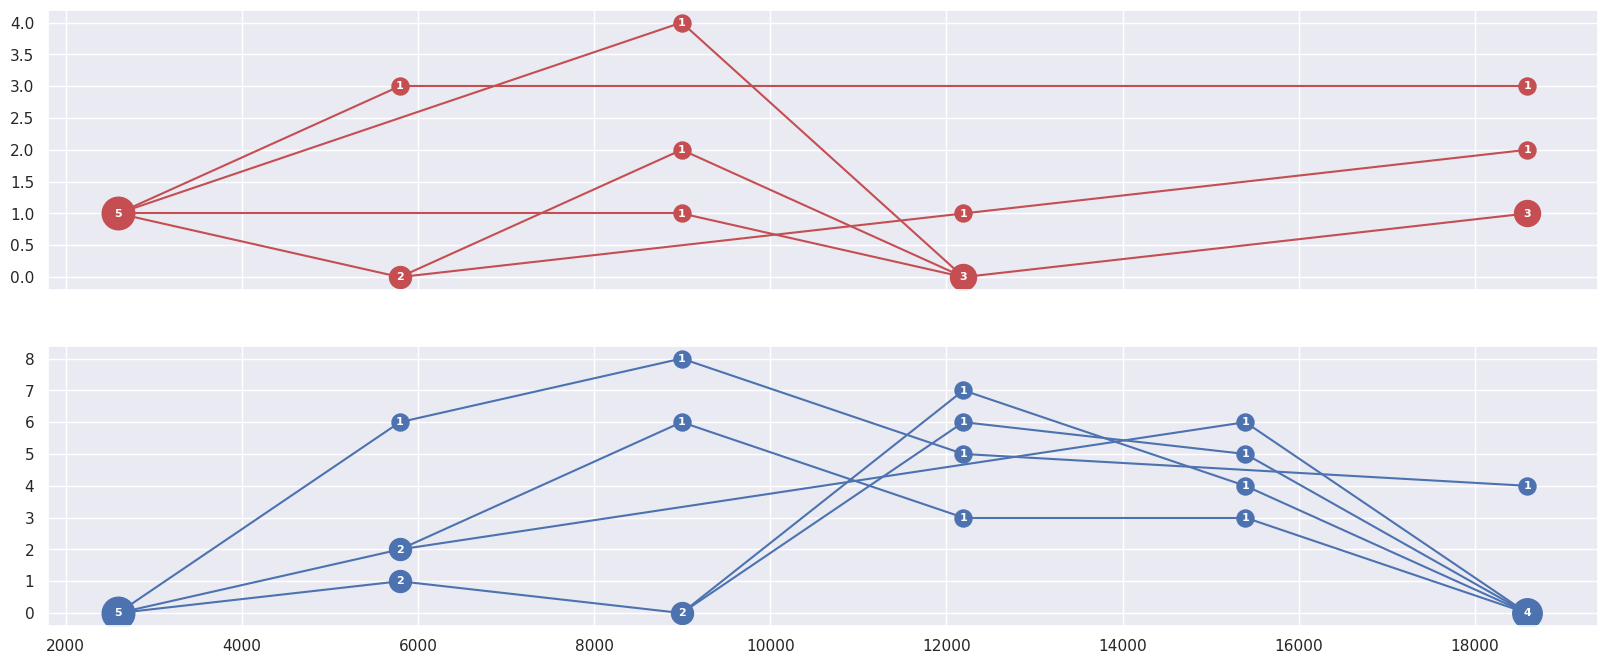

In [43]:
img_fig,ax = plot_map(selected_map,(10,8))
fig, axes = plt.subplots(2, 1, figsize=(20,8), sharex=True)
side_single_color = {"CT" : "b","T":"r"}

connections = set()
for (tick,side,c),(x,y,size,*p,show) in new_result.iterrows():
    color = plt.get_cmap(side_color[side.lower()])(norm(tick))

    if show:
        ax.scatter(x,y,color=color,marker=marker_styles[int(size)-1],s=5 + size*10)
        axes[len(side)-1].scatter(tick,c,s=50 + size*100,color=side_single_color[side])
        axes[len(side)-1].annotate(f'{size}', (tick, c), xytext=(0, 0), 
                           textcoords='offset points', ha='center', va='center',
                           fontsize=8, fontweight='bold', color='white')
        
        lineage = get_cluster_lineage(new_result,tick,side,c)
        if lineage:
            lineage = lineage[0]

        for prev_tick, prev_side, prev_c in list(lineage):
            prev_data = new_result.loc[(prev_tick, prev_side, prev_c)]
            prev_x, prev_y = prev_data[:2]
            
            ax.annotate('', xy=(x, y), xytext=(prev_x, prev_y),
                       arrowprops=dict(arrowstyle='->', 
                                      color=color, 
                                      alpha=0.5,
                                      lw=1.5,
                                      shrinkA=5,
                                      shrinkB=5))
            axes[len(side)-1].plot([prev_tick,tick],[prev_c,c],color=side_single_color[side])


### temp

In [44]:
grouped_loc = new_result[["x","y"]].reset_index()

x           y  size   start     end            p1  \
tick side c                                                                 
2594 CT   0.0  309.624359  305.343903     5  2594.0  2594.0  7.656120e+16   
     T    1.0  902.287781  647.973206     5  2594.0  2594.0  7.656120e+16   
5794 CT   1.0  609.766724  255.686401     2  5794.0  5794.0  7.656120e+16   
          2.0  235.800873  582.387817     2  5794.0  5794.0  7.656120e+16   
          6.0  381.753296  212.506470     1  5794.0  5794.0  7.656120e+16   

                         p2            p3            p4            p5  show  
tick side c                                                                  
2594 CT   0.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16  True  
     T    1.0  7.656120e+16  7.656120e+16  7.656120e+16  7.656120e+16  True  
5794 CT   1.0  7.656120e+16           NaN           NaN           NaN  True  
          2.0  7.656120e+16           NaN           NaN           NaN  True  
          6.0           NaN           NaN           NaN           NaN  True

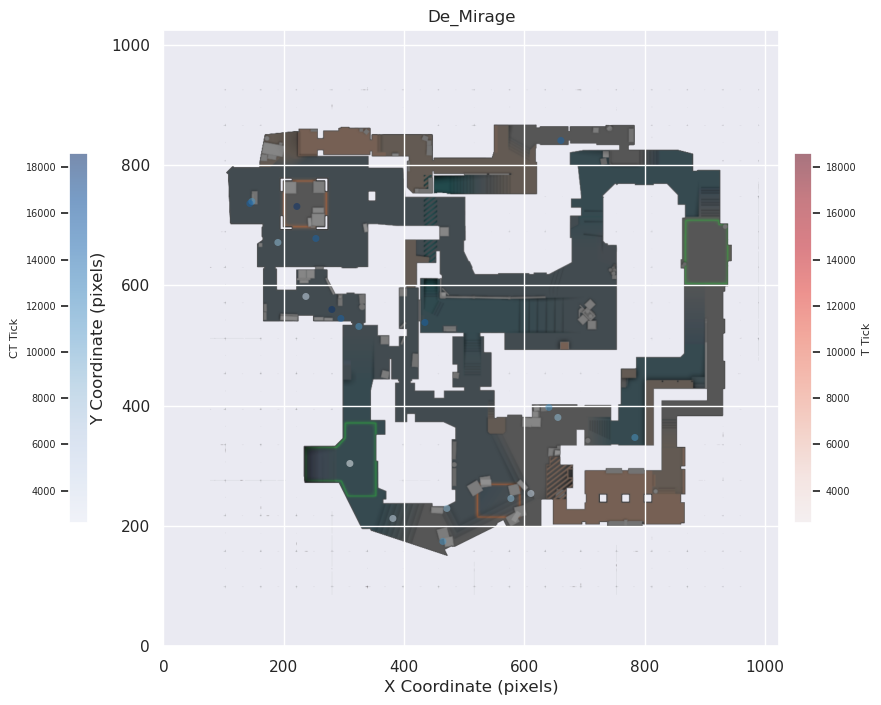

In [45]:
display(new_result.head())
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))

loc_fig, loc_ax = plot_loc_img_unicode(grouped_loc[grouped_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)


tick side           steam_id  \
match_id                             round_num                                  
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5           2914   CT  76561198160709585   
                                     5           2914   CT  76561197996678278   
                                     5           2914   CT  76561198004115516   
                                     5           2914   CT  76561198022365638   
                                     5           2914   CT  76561198064864198   
...                                               ...  ...                ...   
                                     5          19692   CT  76561198004115516   
                                     5          19692   CT  76561198160709585   
                                     5          19692   CT  76561198064864198   
                                     5          19692   CT  76561197996678278   
                                     5          19692   CT  76561198022365638   

                                                         x           y  
match_id                             round_num                          
0839a031-0e2c-4c03-b4bc-b5ba05fe669a 5          427.195068  205.514526  
                                     5          319.298523  451.389648  
                                     5          326.645691  433.896790  
                                     5          326.141144  465.093384  
                                     5          365.940979  231.880493  
...                                                    ...         ...  
                                     5          143.831009  736.607056  
                                     5          390.214355  732.689697  
                                     5          279.211975  573.197205  
                                     5          252.900024  678.815491  
                                     5          279.591583  560.860352  

[1315 rows x 5 columns]

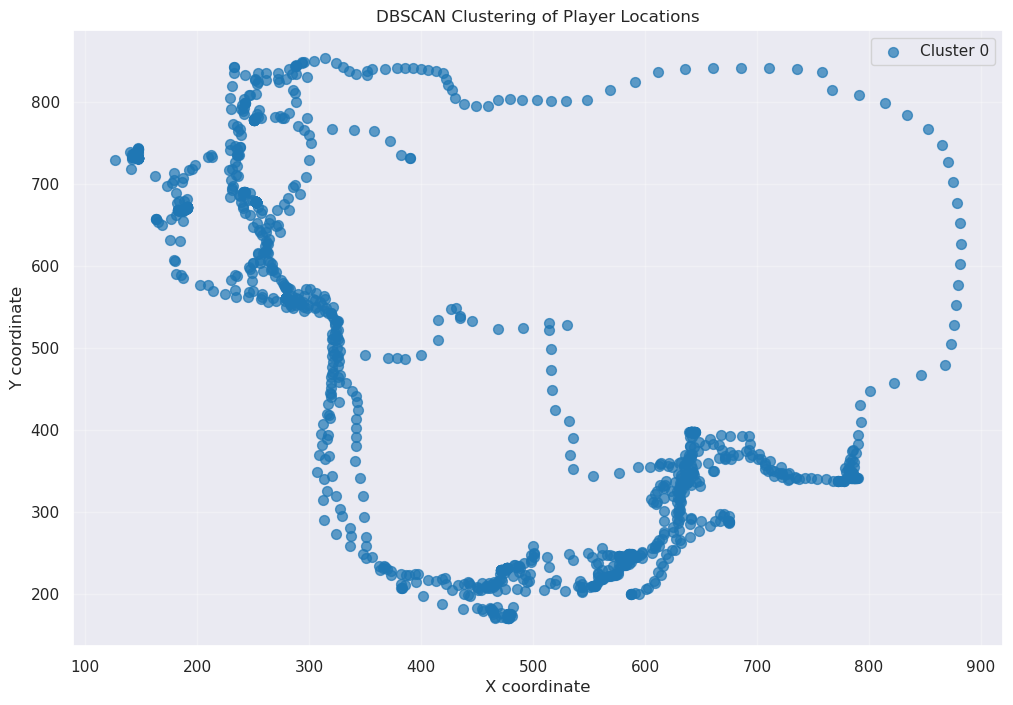

Number of clusters: 1
Number of noise points: 0
Total points: 1315
Cluster 0: 1315 points


In [46]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Extract x, y coordinates for clustering
# Assuming your data is in a DataFrame called 'data' or similar
side_loc = tf_loc[tf_loc.side == "CT"]
time_points = side_loc.tick.unique()
side_loc = side_loc[side_loc.tick.isin(time_points[5:])]
display(side_loc)
coordinates = side_loc[['x', 'y']].values

# Apply DBSCAN clustering
# eps: maximum distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: number of samples in a neighborhood for a point to be considered as a core point
dbscan = DBSCAN(eps=50,min_samples=5)  # You may need to adjust these parameters
cluster_labels = dbscan.fit_predict(coordinates)

# Add cluster labels to your data
side_loc['cluster'] = cluster_labels

# Plot the clusters
plt.figure(figsize=(12, 8))

# Get unique cluster labels
unique_labels = set(cluster_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise points
        col = 'black'
        marker = 'x'
        label = 'Noise'
    else:
        marker = 'o'
        label = f'Cluster {k}'
    
    class_member_mask = (cluster_labels == k)
    xy = coordinates[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50, alpha=0.7, label=label)

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('DBSCAN Clustering of Player Locations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print cluster statistics
print(f"Number of clusters: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Number of noise points: {list(cluster_labels).count(-1)}")
print(f"Total points: {len(cluster_labels)}")

# Show cluster distribution
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    if cluster_id == -1:
        print(f"Noise points: {count}")
    else:
        print(f"Cluster {cluster_id}: {count} points")

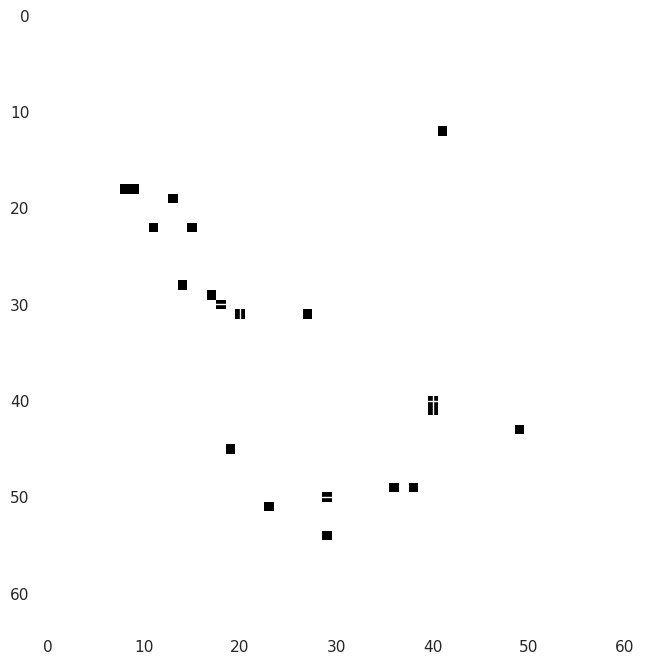

In [47]:
cluster_loc = new_result[["x","y"]].astype(int).reset_index()
side_loc = cluster_loc[cluster_loc.side == "CT"]
shrink_factor = 16
matrix_map = np.ones((image_dim//shrink_factor,image_dim//shrink_factor))

for idx,(*_,x,y) in side_loc.iterrows():
    matrix_map[-(y//shrink_factor),x//shrink_factor] = 0

fig,ax = plt.subplots(figsize=(8,8))
ax.imshow(matrix_map, cmap='grey', interpolation='nearest')
plt.grid(True)
plt.show()

### pca

In [48]:
side_df = pd.DataFrame()
side = "CT"
raw_loc_df = tf_loc[tf_loc.side == side].reset_index().drop(["match_id","round_num"],axis=1)
player_encode = {k:f"{p}" for p,k in enumerate(sorted(raw_loc_df.steam_id.unique()),start=1)}

index = []
for i in range(1,len(raw_loc_df.steam_id.unique())+1):
    index.append(f"p{i}x")
    index.append(f"p{i}y")
for tick in all_ticks:
    p_coords= list(raw_loc_df[raw_loc_df.tick == tick].sort_values("steam_id")[["x","y"]].values.reshape(1,-1)[0])
    side_df.loc[tick,index] = p_coords

side_df.index.set_names(["tick"],inplace=True)
print(side_df.shape)
display(side_df.head())

(6, 10)


,p1x,p1y,p2x,p2y,p3x,p3y,p4x,p4y,p5x,p5y
tick,,,,,,,,,,
2594,315.411591,327.957642,324.543274,310.074585,326.456848,341.275879,257.403259,284.338928,324.306793,263.07251
5794,269.496368,587.757446,202.105377,577.01825,381.753296,212.50647,630.915833,266.125916,588.617676,245.246887
8994,471.258942,229.222473,190.685257,672.053406,577.073914,246.61438,641.352783,369.819641,668.220642,393.654968
12194,324.843536,533.136353,147.199753,739.846069,464.142151,175.704285,641.268555,397.753784,784.171448,347.99054
15394,252.900024,678.815491,143.831009,736.607056,295.17511,545.565857,434.819031,538.802063,660.588623,841.371338


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(side_df.values)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_columns = [f'PC{i+1}' for i in range(pca_result.shape[1])]
side_df_pca = pd.DataFrame(data=pca_result, columns=pca_columns, index=side_df.index)

# --- Optional: Analyze Explained Variance ---
# This tells you how much information (variance) each PC captures.
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio for each Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

print(f"\nTotal Explained Variance by 2 PCs: {np.sum(explained_variance_ratio):.4f}")

# --- Display the head of the PCA-transformed DataFrame ---
print("\nside_df_pca (first 5 Principal Components):")
display(side_df_pca.head())

# --- Optional: Access PCA components (loadings) ---
# This shows how much each original 'pXy' feature contributes to each PC.
# This can be useful for interpreting the meaning of your PCs.
# Each row is a PC, each column is an original feature.
pca_components_df = pd.DataFrame(pca.components_, columns=side_df.columns, index=pca_columns)
print("\nPCA Components (Loadings - how original features contribute to PCs):")
display(pca_components_df)

Explained Variance Ratio for each Principal Component:
PC1: 0.5255
PC2: 0.3179

Total Explained Variance by 2 PCs: 0.8434

side_df_pca (first 5 Principal Components):


,PC1,PC2
tick,,
2594,-0.974724,3.672770
5794,-1.111931,0.065855
8994,-2.809138,-1.117071
12194,-1.277662,-1.797320
15394,2.469362,-1.030045



PCA Components (Loadings - how original features contribute to PCs):


,p1x,p1y,p2x,p2y,p3x,p3y,p4x,p4y,p5x,p5y
PC1,-0.329203,0.350987,-0.187754,0.158997,-0.361271,0.398672,-0.292859,0.378298,-0.212176,0.38020
PC2,-0.098841,-0.162651,0.501608,-0.515349,-0.251020,0.078052,-0.382135,-0.151539,-0.422906,-0.17215


-1.3832624388553814 1.6671534764532288
-0.6532953545358964 -0.9236373420372056
{'PC1': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (132.5667486468237, 518.7395414703883)}, 'PC2': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (226.00253543971778, 187.11831670361272)}}


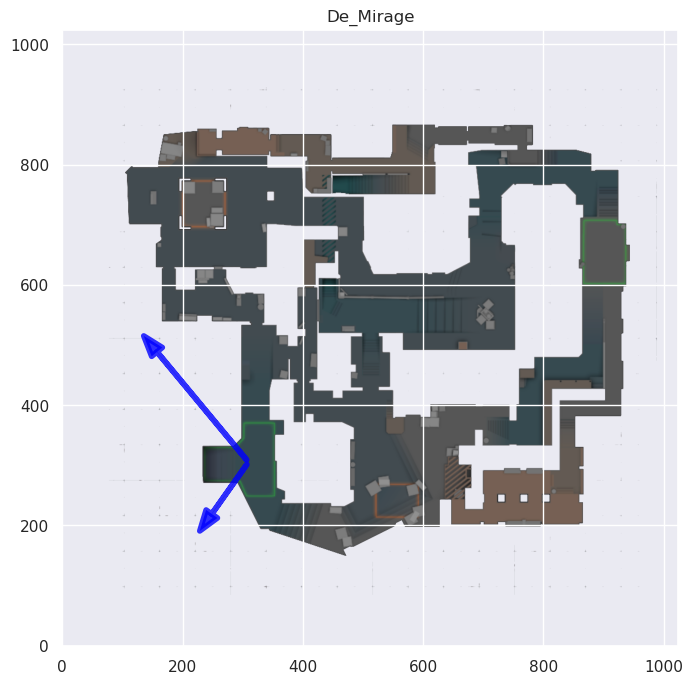

In [51]:
from matplotlib.patches import FancyArrowPatch

img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))

start_pos = side_df.iloc[0,::2].mean(),side_df.iloc[0,1::2].mean()
vectors = {}
scale_factor = 128
for pc,row in pca_components_df.iterrows():
    dx,dy = row[::2].sum(),row[1::2].sum()
    print(dx,dy)
    vectors[pc] = {
        "start_pos" : start_pos,
        "end_pos" : (start_pos[0]+dx*scale_factor
                     ,start_pos[1]+dy*scale_factor)
    }

print(vectors)
for pc,vector in vectors.items():
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            color="blue",
                            alpha=0.8,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

In [52]:
def angle_between_vectors(v1, v2, degree=True):
    """
    Calculate angle between two vectors.
    
    Args:
        v1, v2 (np.array): Input vectors
        degree (bool): If True, return angle in degrees; if False, return in radians
        
    Returns:
        float: Angle in degrees (default) or radians
    """
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle_rad = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    
    if degree:
        return np.degrees(angle_rad)
    return angle_rad

In [53]:
def create_sliding_windows(df_length, window_size=15, overlap=5):
    """
    Create sliding windows for temporal analysis.
    
    Args:
        df_length (int): Length of the dataframe
        window_size (int): Size of each window
        overlap (int): Overlap between consecutive windows
        
    Returns:
        list: List of slice objects representing windows
    """
    windows = []
    window_start = 0
    
    # Create sliding windows
    while window_start + window_size <= df_length:
        window_end = window_start + window_size
        windows.append(slice(window_start, window_end))
        window_start += (window_size - overlap)
    
    # Handle remaining data
    if len(windows) > 0:
        last_end = windows[-1].stop
        if last_end < df_length:
            remaining = df_length - last_end
            min_window_size = max(window_size // 2, 1)
            
            if remaining >= min_window_size:
                new_start = max(last_end - overlap, 0)
                windows.append(slice(new_start, df_length))
            else:
                windows[-1] = slice(windows[-1].start, df_length)
    
    # Ensure at least one window exists
    if not windows:
        windows.append(slice(0, df_length))
    
    return windows

In [54]:
def perform_pca_on_window(X,max_cmps=5):
    """
    Perform PCA analysis on a single window of data.
    
    Args:
        X (pd.DataFrame): Window data
        
    Returns:
        dict: Dictionary containing PCA results
    """
    n_components = min(max_cmps, len(X) - 1, X.shape[1])
    
    scaler = StandardScaler()
    pca = PCA(n_components=n_components)
    
    X_scaled = scaler.fit_transform(X.values)
    pca_result = pca.fit_transform(X_scaled)
    
    components = pd.DataFrame(
        pca.components_, 
        columns=X.columns, 
        index=[f'PC{i+1}' for i in range(pca_result.shape[1])]
    )


    return {
        "pca": pca,
        "scaler": scaler,
        "pca_result": pd.DataFrame(
            pca_result, 
            columns=[f"PC{i}" for i in range(1, n_components + 1)]
        ),
        "components": components,
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }

In [55]:
def calculate_start_position(X):
    """
    Calculate the starting position from position columns.
    
    Args:
        X (pd.DataFrame): Window data
        
    Returns:
        tuple: (x, y) starting position, or None if no position columns found
    """
    x_cols = [col for col in X.columns if col.endswith('x') and col.startswith('p')]
    y_cols = [col for col in X.columns if col.endswith('y') and col.startswith('p')]
    
    if x_cols and y_cols:
        return (
            X.iloc[0][x_cols].mean(),
            X.iloc[0][y_cols].mean()
        )
    return None

In [56]:
def calculate_pc_vectors(components, start_pos, scale_factor=128):
    """
    Calculate PC vectors from components and starting position.
    
    Args:
        components (pd.DataFrame): PCA components
        start_pos (tuple): Starting position (x, y)
        scale_factor (float): Scaling factor for vectors
        
    Returns:
        list: List of vector dictionaries with start_pos and end_pos
    """
    if start_pos is None:
        return dict()
    
    x_cols = [col for col in components.columns if col.endswith('x') and col.startswith('p')]
    y_cols = [col for col in components.columns if col.endswith('y') and col.startswith('p')]
    
    vectors = dict()
    for pc,row in components.iterrows():
        dx = row[x_cols].sum()
        dy = row[y_cols].sum()
        
        end_pos = (
            start_pos[0] + dx * scale_factor,
            start_pos[1] + dy * scale_factor
        )
        vectors[pc] = {
            "start_pos": start_pos,
            "end_pos": end_pos
        }
    
    return vectors

In [57]:
import copy
def filter_pc_by_group(pc_vectors,pc_groups,components):
    filtered_vecs = copy.deepcopy(pc_vectors)
    filtered_groups = copy.deepcopy(pc_groups)
    filtered_cmps = components.copy()
    for pc,group in pc_groups.items():
        if not group:
            del filtered_groups[pc]
            del filtered_vecs[pc]
            filtered_cmps.drop([pc],inplace=True)
            
    return (filtered_vecs,filtered_groups,filtered_cmps)
            

In [58]:
from sklearn.cluster import AgglomerativeClustering,KMeans
def filter_pc_by_similarity(pc_vectors,pc_groups,components):
    filtered_vecs = copy.deepcopy(pc_vectors)
    filtered_groups = copy.deepcopy(pc_groups)
    filtered_cmps = components.copy()

    vecs_df = pd.DataFrame()
    for pc,vec in pc_vectors.items():
        vecs_df.loc[pc,["x","y"]] = np.array(vec["end_pos"])-np.array(vec["start_pos"])

    clustering = AgglomerativeClustering(n_clusters=None,
                                         distance_threshold=0.3,
                                         metric="cosine",linkage="average").fit(vecs_df.values)
    vecs_df["label"] = clustering.labels_
    for label in np.unique(clustering.labels_):
        all_vecs = vecs_df[vecs_df.label == label].index
        n_vec = all_vecs.size
        new_pc = "PC" + "".join([pc[-1] for pc in all_vecs])
        filtered_cmps.loc[new_pc] = components.loc[all_vecs].mean()
        filtered_cmps.drop(all_vecs,inplace=True)


        new_sx,new_sy,new_ex,new_ey = 0,0,0,0
        new_pc_group = []
        for vec in all_vecs:
            new_sx += pc_vectors[vec]["start_pos"][0] / n_vec
            new_sy += pc_vectors[vec]["start_pos"][1] / n_vec
            
            new_ex += pc_vectors[vec]["end_pos"][0] / n_vec
            new_ey += pc_vectors[vec]["end_pos"][1] / n_vec
            del filtered_vecs[vec]

            
            new_pc_group += pc_groups[vec]
            
            del filtered_groups[vec]


        filtered_vecs[new_pc] = {
            "start_pos" : (new_sx,new_sy),
            "end_pos" : (new_ex,new_ey),
        }

        filtered_groups[new_pc] = new_pc_group

    return (filtered_vecs,filtered_groups,filtered_cmps)

In [59]:
def group_points_by_pc(components):
    """
    Group points by their alignment with principal components.
    
    Args:
        components (pd.DataFrame): PCA components
        
    Returns:
        dict: Dictionary grouping points by PC1 and PC2
    """
    x_cols = [col for col in components.columns if col.endswith('x') and col.startswith('p')]
    y_cols = [col for col in components.columns if col.endswith('y') and col.startswith('p')]
    
    pc_groups = {pc:[] for pc in components.index}
    
    if not x_cols or not y_cols:
        return pc_groups
    
    
    for p_idx in range(1, (components.columns.size // 2) + 1):
        best_vec = None
        min_angle = float("inf")

        for pc,row in components.iterrows():
            p_vec = components.loc[pc, [f"p{p_idx}x", f"p{p_idx}y"]].values
            c_vec = np.array([
                row[x_cols].sum(),
                row[y_cols].sum()
            ])

            angle = angle_between_vectors(p_vec,c_vec)

            if angle < min_angle:
                best_vec = pc
                min_angle=angle
        pc_groups[best_vec].append(f"p{p_idx}")
    
    return pc_groups

In [60]:
def process_single_window(X, win_key, scale_factor=128):
    """
    Process a single window with complete PCA analysis.
    
    Args:
        X (pd.DataFrame): Window data
        win_key (str): Window identifier
        scale_factor (float): Scaling factor for vectors
        
    Returns:
        dict: Complete analysis results for the window
    """
    # Perform PCA
    pca_results = perform_pca_on_window(X)
    
    
    # Calculate positions and vectors
    start_pos = calculate_start_position(X)
    pc_vectors = calculate_pc_vectors(pca_results["components"], start_pos, scale_factor)
    # pc_vectors = calculate_dynamic_pc_vectors(pca_results["components"],pca_results["explained_variance_ratio"], start_pos, scale_factor)
    pc_groups = group_points_by_pc(pca_results["components"])
    print(f"{'-'*25} before filter {'-'*25}")
    print(pc_vectors)
    print(pc_groups)
    print(pca_results["components"])

    pc_vectors,pc_groups,cmps = filter_pc_by_group(pc_vectors,pc_groups,pca_results["components"])
    print(f"{'-'*25} group filtered {'-'*25}")
    print(pc_vectors)
    print(pc_groups)
    print(cmps)
    pc_vectors,pc_groups,cmps = filter_pc_by_similarity(pc_vectors,pc_groups,cmps)
    print(f"{'-'*25} similarity filtered {'-'*25}")
    print(pc_vectors)
    print(pc_groups)
    print(cmps)

    pca_results["components"]=cmps
    # Combine all results
    result = {
        "start": X.index[0] if 'tick' not in X.columns else X['tick'].min(),
        "end": X.index[-1] if 'tick' not in X.columns else X['tick'].max(),
        **pca_results,
        "pc_vectors": pc_vectors,
        "pc_groups": pc_groups
    }

    for pc in result["pc_vectors"].keys():
        result["pc_vectors"][pc]["tick"] = (result["end"]+result["start"])//2
    # Add start_pos only if position columns exist
    if start_pos is not None:
        result["start_pos"] = start_pos
    
    return result

In [61]:
def temporal_pca(df, window_size=15, overlap=5, scale_factor=128):
    """
    Perform temporal PCA analysis on sliding windows of data.
    
    Args:
        df (pd.DataFrame): Input dataframe
        window_size (int): Size of each sliding window
        overlap (int): Overlap between consecutive windows
        scale_factor (float): Scaling factor for PC vectors
        
    Returns:
        dict: Results for each window
    """
    windows = create_sliding_windows(len(df), window_size, overlap)
    result = {}
    
    for n_win, slc in enumerate(windows, start=1):
        win_key = f"window_{n_win}"
        X = df.iloc[slc]
        result[win_key] = process_single_window(X, win_key, scale_factor)
    
    return result

In [62]:
def inverse_pc_groups(pc_groups):
    """
    Inversing from list of player into dict of player and their PC

    Args:
        pc_groups (dict(List[])): pc_groups result from temporal_pca

    Returns:
        dict: Player and their PC
    """

    result = dict()
    for pc,players in pc_groups.items():
        for player in players:
            result[player] = pc
    return result

In [63]:
temporal_pca_results = temporal_pca(side_df,10,5,scale_factor=128)
# print(temporal_pca_results)
test_result = temporal_pca_results["window_1"]
print(test_result)

------------------------- before filter -------------------------
{'PC1': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (132.5667486468237, 518.7395414703883)}, 'PC2': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (226.00253543971778, 187.11831670361272)}, 'PC3': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (363.6087536775054, 368.2508559099601)}, 'PC4': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (404.86837949935983, 332.74230047399817)}, 'PC5': {'start_pos': (309.6243408203125, 305.343896484375), 'end_pos': (285.00798167406566, 272.2617071319407)}}
{'PC1': ['p2', 'p3', 'p4', 'p5'], 'PC2': [], 'PC3': [], 'PC4': [], 'PC5': ['p1']}
          p1x       p1y       p2x       p2y       p3x       p3y       p4x  \
PC1 -0.329203  0.350987 -0.187754  0.158997 -0.361271  0.398672 -0.292859   
PC2 -0.098841 -0.162651  0.501608 -0.515349 -0.251020  0.078052 -0.382135   
PC3  0.576499 -0.466724  0.001225  0.099042  0.296478  

In [64]:
print(inverse_pc_groups(test_result["pc_groups"]))

{'p1': 'PC5', 'p2': 'PC1', 'p3': 'PC1', 'p4': 'PC1', 'p5': 'PC1'}


In [65]:
print(temporal_pca_results['window_1']["components"])

Empty DataFrame
Columns: [p1x, p1y, p2x, p2y, p3x, p3y, p4x, p4y, p5x, p5y]
Index: []


In [66]:
test_result["components"]

,p1x,p1y,p2x,p2y,p3x,p3y,p4x,p4y,p5x,p5y


PC5


KeyError: 'PC5'

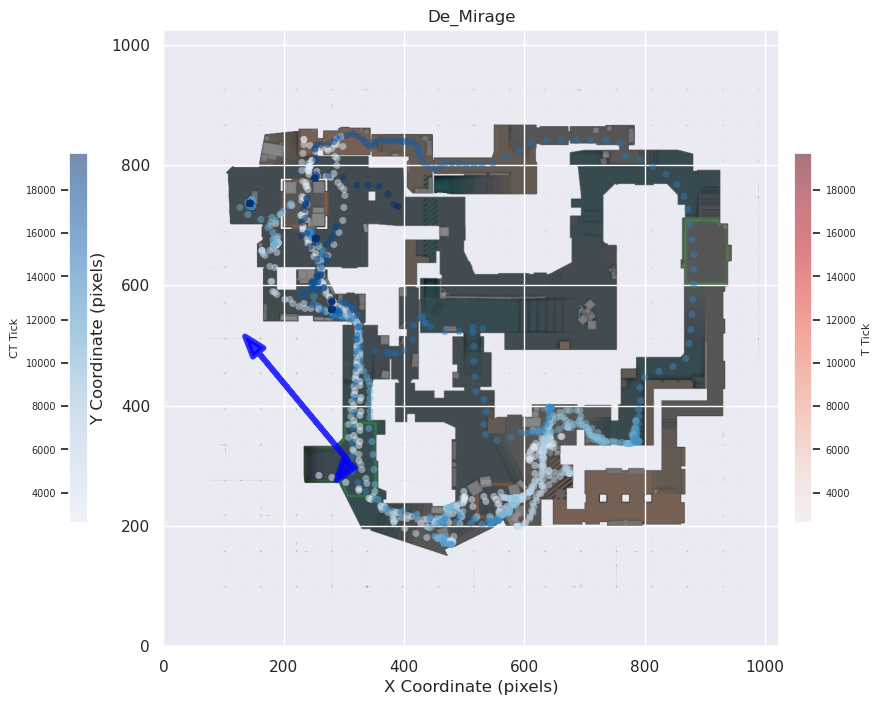

In [67]:
from matplotlib.patches import FancyArrowPatch

vectors = test_result["pc_vectors"].values()
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in vectors:
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color="blue",
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

for player,pc in inverse_pc_groups(test_result["pc_groups"]).items():
    print(pc)
    p_coord_cols = [player+"x",player+"y"]
    psx,psy = side_df.loc[test_result["start"],p_coord_cols]
    pdx,pdy = test_result["components"].loc[pc,p_coord_cols] 
    # img_loc_ax = plt.quiver(psx,psy,pdx,pdy,zorder=20)


In [ ]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))
for window in temporal_pca_results.values():
    for pc,vector in window["pc_vectors"].items():
        color = plt.get_cmap("viridis")(norm(vector["tick"]))
        arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
        img_loc_ax.add_patch(arrow)

        
        vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
        vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
        
        # Small offset factor from the end of the arrow
        text_offset_factor = 15 
        
        # Adjust offset based on direction of the vector
        # This tries to place text slightly to the "outside" or "ahead" of the arrow
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)
    
        # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
        if abs(vec_dx) > abs(vec_dy): # More horizontal
            text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
        else: # More vertical
            text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset
    
    
        img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                        vector['end_pos'][1]+ text_y_offset,
                        f'{pc}', # Use the 'pc_name' from your vector dictionary
                        color=color, # Use the same color as the arrow
                        fontsize=10, # Adjust font size as needed
                        weight='bold',
                        ha='center', va='center', # Center alignment relative to the text point
                        zorder=11) # Ensure text is above arrows

In [ ]:
def group_similarity(group1,group2):
    group1 = set(group1)
    group2 = set(group2)

    return len(group1.intersection(group2)) / len(group1.union(group2))

In [ ]:
import copy
def chain_pc_vectors(tpca_result):
    list_results = [copy.deepcopy(window_data) for window_data in tpca_result.values()]
    chained_vecs = []
    for pc,vec in list_results[0]["pc_vectors"].items():
        new_vec = copy.deepcopy(vec)
        new_vec["name"] = pc
        chained_vecs.append(new_vec)

    for index in range(1,len(list_results)):
        print(index)
        for cpc,cg in list_results[index]["pc_groups"].items():
            if not cg:
                continue
            print(f"\t{cpc=} with {cg=}")
            max_sim = 0
            max_group = None
            max_pc = None
            min_dist = float("inf")
            for ppc,pg in list_results[index-1]["pc_groups"].items():
                group_sim=group_similarity(cg,pg)
                start = list_results[index]["pc_vectors"][cpc]["start_pos"]
                end = list_results[index-1]["pc_vectors"][ppc]["end_pos"]
                dist = eu_dist(*start,*end)
                print(f"\t\tchecking with {ppc=} have {pg=} with {group_sim=} also {dist=} that {start=},{end=}",end="")
                if (group_sim > max_sim) or ((group_sim == max_sim) and (dist < min_dist)):
                    max_sim = group_sim
                    max_pc = ppc
                    min_dist = dist
                    max_group=pg
                    print("✅")
                else:
                    print("")
                    
                    

            print(f"\tbest match with {max_pc} have {max_group} with {max_sim=}")
            print()
    
            current_vector = list_results[index]["pc_vectors"][cpc]
            dx = current_vector["end_pos"][0] - current_vector["start_pos"][0]
            dy = current_vector["end_pos"][1] - current_vector["start_pos"][1]
            start_pos = list_results[index-1]["pc_vectors"][max_pc]['end_pos']
            end_pos = (start_pos[0]+dx,start_pos[1]+dy)
            new_vec = {
                "start_pos" : start_pos,
                "end_pos" : end_pos,
                "tick" : list_results[index]["pc_vectors"][cpc]["tick"],
                "name" : cpc
            }
            chained_vecs.append(new_vec)
    
            list_results[index]["pc_vectors"][cpc] = new_vec
    return chained_vecs

chained_vecs = chain_pc_vectors(temporal_pca_results)

In [ ]:
for window in temporal_pca_results.values():
    for pc,vec in window["pc_vectors"].items():
        print(vec)

In [ ]:
print(len(chained_vecs))
print(chained_vecs)

In [ ]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8))
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in chained_vecs[:]:
    color = plt.get_cmap("viridis")(norm(vector["tick"]))
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

    vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
    vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
    
    # Small offset factor from the end of the arrow
    text_offset_factor = 15 
    
    # Adjust offset based on direction of the vector
    # This tries to place text slightly to the "outside" or "ahead" of the arrow
    text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
    text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)

    # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
    if abs(vec_dx) > abs(vec_dy): # More horizontal
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
    else: # More vertical
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset


    img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                    vector['end_pos'][1]+ text_y_offset,
                    f'{vector["name"]}', # Use the 'pc_name' from your vector dictionary
                    color=color, # Use the same color as the arrow
                    fontsize=10, # Adjust font size as needed
                    weight='bold',
                    ha='center', va='center', # Center alignment relative to the text point
                    zorder=11) # Ensure text is above arrows

### Interactive Plot

In [159]:
from ipywidgets import interact, IntSlider, Layout, HBox, VBox, FloatSlider, Checkbox
import ipywidgets as widgets
from IPython.display import display

# This function definition assumes plot_map, plot_loc_unicode, plot_line, and transform_coords 
# functions are already defined elsewhere in your code

def plot_actions_by_max_tick(max_tick=100, 
                            show_flash=True, 
                            show_kills=True, 
                            show_grenades=True,
                            flash_alpha=0.7,
                            kill_alpha=0.7,
                            grenade_alpha=0.7,
                            flash_size=10,
                            kill_size=10,
                            grenade_size=10,
                            show_lines=True):
    """
    Interactive plot of game actions filtered by maximum tick
    Everything from tick 0 up to max_tick will be shown
    """
    # Set min_tick to the minimum value or 0
    min_tick = global_min_tick
    
    # Clear previous plots
    plt.figure(figsize=(12, 10))
    
    # Start with map
    img_fig, img_ax = plot_map(selected_map, (12, 10))
    current_fig, current_ax = img_fig, img_ax
    
    # Filter actions by tick range
    flash_mask = (transformed_flash['tick'] >= min_tick) & (transformed_flash['tick'] <= max_tick)
    kill_mask = (transformed_kills['tick'] >= min_tick) & (transformed_kills['tick'] <= max_tick)
    grenade_mask = (transformed_grenades['throw_tick'] >= min_tick) & (transformed_grenades['throw_tick'] <= max_tick)
    
    filtered_flash = transformed_flash[flash_mask] if isinstance(transformed_flash, pd.DataFrame) else transformed_flash
    filtered_kills = transformed_kills[kill_mask] if isinstance(transformed_kills, pd.DataFrame) else transformed_kills
    filtered_grenades = transformed_grenades[grenade_mask] if isinstance(transformed_grenades, pd.DataFrame) else transformed_grenades

    flash_count = filtered_flash.attacker_side.notnull().sum()
    kill_count = filtered_kills.attacker_side.notnull().sum()
    grenade_count = filtered_grenades.thrower_side.notnull().sum()
    
    # Plot flashes if requested
    if show_flash and len(filtered_flash) > 0:
        flash_fig, flash_ax = plot_loc_img_unicode(filtered_flash, 
                                          gradient_by="tick", 
                                          size=flash_size,
                                          color_by="side",
                                          color_dict=side_color,
                                          marker_by="status",
                                          marker_dict=flash_marker,
                                          alpha=flash_alpha,
                                          fig=current_fig, 
                                          ax=current_ax)
        current_fig, current_ax = flash_fig, flash_ax
        
        # Plot flash lines if requested
        if show_lines:
            flash_co_mask = (tf_f_co["tick"] >= min_tick) & (tf_f_co["tick"] <= max_tick)
            filtered_f_co = tf_f_co[flash_co_mask] if isinstance(tf_f_co, pd.DataFrame) else tf_f_co
            if len(filtered_f_co) > 0:
                cf_fig, cf_ax = plot_line(filtered_f_co, "attacker", "player", "tick", 
                                         default_color="viridis", fig=current_fig, ax=current_ax)
                current_fig, current_ax = cf_fig, cf_ax
    
    # Plot kills if requested
    if show_kills and len(filtered_kills) > 0:
        kill_fig, kill_ax = plot_loc_img_unicode(filtered_kills, 
                                          gradient_by="tick", 
                                          size=kill_size,
                                          color_by="side",
                                          color_dict=side_color,
                                          marker_by="status",
                                          marker_dict=kill_marker,
                                          alpha=kill_alpha,
                                          fig=current_fig, 
                                          ax=current_ax)
        current_fig, current_ax = kill_fig, kill_ax
        
        # Plot kill lines if requested
        if show_lines:
            kill_co_mask = (tf_k_co["tick"] >= min_tick) & (tf_k_co["tick"] <= max_tick)
            filtered_k_co = tf_k_co[kill_co_mask] if isinstance(tf_k_co, pd.DataFrame) else tf_k_co
            if len(filtered_k_co) > 0:
                ck_fig, ck_ax = plot_line(filtered_k_co, "attacker", "victim", "tick", 
                                         default_color="Reds", fig=current_fig, ax=current_ax)
                current_fig, current_ax = ck_fig, ck_ax
    
    # Plot grenades if requested
    if show_grenades and len(filtered_grenades) > 0:
        grenade_fig, grenade_ax = plot_loc_img_unicode(filtered_grenades, 
                                              gradient_by="throw_tick", 
                                              size=grenade_size,
                                              color_by="side",
                                              color_dict=side_color,
                                              marker_by="status",
                                              marker_dict=grenade_marker,
                                              alpha=grenade_alpha,
                                              fig=current_fig, 
                                              ax=current_ax)
        current_fig, current_ax = grenade_fig, grenade_ax
        
        # Plot grenade lines if requested
        if show_lines:
            grenade_co_mask = (tf_g_co["throw_tick"] >= min_tick) & (tf_g_co["throw_tick"] <= max_tick)
            filtered_g_co = tf_g_co[grenade_co_mask] if isinstance(tf_g_co, pd.DataFrame) else tf_g_co
            if len(filtered_g_co) > 0:
                cg_fig, cg_ax = plot_line(filtered_g_co, "thrower", "grenade", "throw_tick", 
                                         default_color="Greens", fig=current_fig, ax=current_ax)
    
    # Add title with tick range info
    plt.title(f'Game Actions (Tick range: {min_tick} - {max_tick})', fontsize=14)

    # Show number of events in the filtered range
    
    # Add a text box with event counts
    info_text = f"Events in range: {flash_count} flashes, {kill_count} kills, {grenade_count} grenades"
    plt.figtext(0.5, 0.01, info_text, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


global_min_tick = idx_pf_df.loc[sel_idx].tick.min()
global_max_tick = idx_pf_df.loc[sel_idx].tick.max()


# Create the interactive widgets
max_tick_slider = IntSlider(
    value=global_max_tick,
    min=global_min_tick,
    max=global_max_tick,
    step=1,
    description='Max Tick:',
    style={'description_width': 'initial'},
    layout=Layout(width='600px')
)

flash_checkbox = Checkbox(
    value=True,
    description='Show Flashes',
    style={'description_width': 'initial'}
)

kill_checkbox = Checkbox(
    value=True,
    description='Show Kills',
    style={'description_width': 'initial'}
)

grenade_checkbox = Checkbox(
    value=True,
    description='Show Grenades',
    style={'description_width': 'initial'}
)

lines_checkbox = Checkbox(
    value=True,
    description='Show Lines',
    style={'description_width': 'initial'}
)

flash_alpha_slider = FloatSlider(
    value=0.7,
    min=0.1,
    max=1.0,
    step=0.1,
    description='Flash Opacity:',
    style={'description_width': 'initial'}
)

kill_alpha_slider = FloatSlider(
    value=0.7,
    min=0.1,
    max=1.0,
    step=0.1,
    description='Kill Opacity:',
    style={'description_width': 'initial'}
)

grenade_alpha_slider = FloatSlider(
    value=0.7,
    min=0.1,
    max=1.0,
    step=0.1,
    description='Grenade Opacity:',
    style={'description_width': 'initial'}
)

flash_size_slider = IntSlider(
    value=30,
    min=20,
    max=50,
    step=1,
    description='Flash Size:',
    style={'description_width': 'initial'}
)

kill_size_slider = IntSlider(
    value=30,
    min=20,
    max=50,
    step=1,
    description='Kill Size:',
    style={'description_width': 'initial'}
)

grenade_size_slider = IntSlider(
    value=30,
    min=20,
    max=50,
    step=1,
    description='Grenade Size:',
    style={'description_width': 'initial'}
)

# Organize the widgets into a more user-friendly layout
tick_controls = VBox([max_tick_slider])
event_controls = HBox([flash_checkbox, kill_checkbox, grenade_checkbox, lines_checkbox])

flash_controls = VBox([flash_alpha_slider, flash_size_slider])
kill_controls = VBox([kill_alpha_slider, kill_size_slider])
grenade_controls = VBox([grenade_alpha_slider, grenade_size_slider])

appearance_controls = HBox([flash_controls, kill_controls, grenade_controls])

all_controls = VBox([tick_controls, event_controls, appearance_controls])

# Create the interactive output
interactive_output = widgets.interactive_output(
    plot_actions_by_max_tick,
    {
        'max_tick': max_tick_slider,
        'show_flash': flash_checkbox,
        'show_kills': kill_checkbox,
        'show_grenades': grenade_checkbox,
        'flash_alpha': flash_alpha_slider,
        'kill_alpha': kill_alpha_slider,
        'grenade_alpha': grenade_alpha_slider,
        'flash_size': flash_size_slider,
        'kill_size': kill_size_slider,
        'grenade_size': grenade_size_slider,
        'show_lines': lines_checkbox
    }
)

display(all_controls)
display(interactive_output)



Output()

# player stats

In [ ]:
# import sys
# print(idx_pf_df.index)
# for idx in idx_pf_df.index.unique():
#     sel_pf = idx_pf_df.loc[idx]
#     print(f"working on {idx}",end="\r")
#     p_count = len(sel_pf.steam_id.unique())
#     if p_count != 10:
#         print(f"at {idx} player missing, only {p_count} player")
#     sys.stdout.flush()

In [ ]:
def get_players_stat(idx):
    
    all_players = idx_pf_df.loc[idx][["steam_id","name","team",]]\
    .drop_duplicates().set_index(["name"])
    max_round = idx_pf_df.loc[idx].index.max()
    
    sel_k = idx_k_df.loc[idx]
    sel_d = idx_d_df.loc[idx]
    
    
    for name in all_players.index:
        sel_player_kill_mask = sel_k.attacker_name == name
        sel_player_death_mask = sel_k.victim_name == name
        sel_player_assist_mask = sel_k.assister_name == name
        sel_player_flash_assist_mask = sel_k.flash_thrower_name == name
        sel_player_traded_mask = sel_k.player_traded_name == name
    
        
        k = sel_player_kill_mask.groupby("round_num").any()
        a = sel_player_assist_mask.groupby("round_num").any() | sel_player_flash_assist_mask.groupby("round_num").any()
        s = ~(sel_player_death_mask.groupby("round_num").any())
        t = sel_player_traded_mask.groupby("round_num").any()
    
        sel_player_kill = sel_k[sel_player_kill_mask]
        sel_player_death = sel_k[sel_player_death_mask]
        sel_player_assist = sel_k[sel_player_assist_mask]
        sel_player_flash_assist = sel_k[sel_player_flash_assist_mask]
        
        # display(sel_player_death)
        
        all_players.loc[name,"kills"] = len(sel_player_kill)
        all_players.loc[name,"deaths"] = len(sel_player_death)
        all_players.loc[name,"assist"] = len(sel_player_assist)
        all_players.loc[name,"flash_assist"] = len(sel_player_flash_assist)
        all_players.loc[name,"first_kill"] = sel_player_kill.is_first_kill.sum()
        all_players.loc[name,"first_death"] = sel_player_death.is_first_kill.sum()
        all_players.loc[name,"kast"] = (k|a|s|t).sum() / max_round
        
    
        sel_player_damage = sel_d[sel_d.attacker_name == name]
        sel_player_dmg_round = sel_player_damage.groupby("round_num").agg(
            rtd=("total_damage","sum")
        )
        all_players.loc[name,"ADR"] =sel_player_dmg_round.rtd.sum() / max_round
    return all_players
get_players_stat(selected_match.match_id)
    

# loc change over action

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots vertically
fig, axes = plt.subplots(3, 1, figsize=(8, 6))  # 3 rows, 1 column, adjust figsize as needed

# Location Change Data (Calculate only once)
sel_loc = idx_pf_df.loc[sel_idx][["tick", "side", "x", "y"]]
first_tick = 0
sel_loc["tick"] = sel_loc["tick"] - first_tick
curr_x = sel_loc.iloc[1:]["x"]
prev_x = sel_loc.iloc[:-1]["x"]
curr_y = sel_loc.iloc[1:]["y"]
prev_y = sel_loc.iloc[:-1]["y"]
loc_change = [0] + list(np.sqrt((curr_x - prev_x) ** 2 + (curr_y - prev_y) ** 2))
sel_loc["loc_change"] = loc_change
sel_team_loc = sel_loc.groupby(["side", "tick"]).agg(avg_loc_change=("loc_change", "mean"))

ct_loc_df = sel_team_loc.loc["CT"].reset_index()
t_loc_df = sel_team_loc.loc["T"].reset_index()

# 1st Subplot: Location Change with Flash
axes[0].plot(ct_loc_df["tick"], ct_loc_df["avg_loc_change"], label="CT Avg. Loc. Change", alpha=0.5)
axes[0].plot(t_loc_df["tick"], t_loc_df["avg_loc_change"], label="T Avg. Loc. Change", alpha=0.5)

sel_f = idx_f_df.loc[sel_idx].reset_index()
sel_f["tick"] = sel_f["tick"] - first_tick
for attacker_side in ["CT", "T"]:
    flash_ticks = sel_f[sel_f.attacker_side == attacker_side]["tick"]
    for tick_value in flash_ticks:
        if attacker_side == "CT":
            ct_f = axes[0].axvline(x=tick_value, color='b', linestyle='--', alpha=0.7, label="CT Flash")
        else:
            t_f = axes[0].axvline(x=tick_value, color='r', linestyle='--', alpha=0.7, label="T Flash")
axes[0].set_title("Location Change with Flash")
axes[0].legend(handles = [ct_f,t_f])

# 2nd Subplot: Location Change with Kills
axes[1].plot(ct_loc_df["tick"], ct_loc_df["avg_loc_change"], label="CT Avg. Loc. Change", alpha=0.5)  # Use pre-calculated location change
axes[1].plot(t_loc_df["tick"], t_loc_df["avg_loc_change"], label="T Avg. Loc. Change", alpha=0.5)  # Use pre-calculated location change

sel_k = idx_k_df.loc[sel_idx].reset_index()
sel_k["tick"] = sel_k["tick"] - first_tick
for attacker_side in ["CT", "T"]:
    kill_ticks = sel_k[sel_k.attacker_side == attacker_side]["tick"]
    for tick_value in kill_ticks:
        if attacker_side == "CT":
            ct_k = axes[1].axvline(x=tick_value, color="purple", linestyle='--', alpha=0.7, label="CT Kill")
        else:
            t_k = axes[1].axvline(x=tick_value, color='yellow', linestyle='--', alpha=0.7, label="T Kill")
axes[1].set_title("Location Change with Kills")
axes[1].legend(handles=[ct_k,t_k])

# 3rd Subplot: Location Change with Grenade
axes[2].plot(ct_loc_df["tick"], ct_loc_df["avg_loc_change"], label="CT Avg. Loc. Change", alpha=0.5)  # Use pre-calculated location change
axes[2].plot(t_loc_df["tick"], t_loc_df["avg_loc_change"], label="T Avg. Loc. Change", alpha=0.5)  # Use pre-calculated location change

sel_g = idx_g_df.loc[sel_idx].reset_index()
sel_g["throw_tick"] = sel_g["throw_tick"] - first_tick
for thrower_side in ["CT", "T"]:
    grenade_ticks = sel_g[sel_g.thrower_side == thrower_side]["throw_tick"]
    for tick_value in grenade_ticks:
        if thrower_side == "CT":
            ct_g = axes[2].axvline(x=tick_value, color="pink", linestyle='--', alpha=0.7, label="CT Grenade")
        else:
            t_g = axes[2].axvline(x=tick_value, color='teal', linestyle='--', alpha=0.7, label="T Grenade")
axes[2].set_title("Location Change with Grenade")
axes[2].legend(handles=[ct_g,t_g])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()


# statistical analysis over rounds

## extracting data for each round

In [ ]:
import re

def convert_to_snake_case(df,prefix):
    # Function to convert a string to snake_case
    def to_snake_case(text,prefix):
        # Convert to lowercase first
        s = text.lower()
        s = re.sub(r'\s+', '_', s)
        s = re.sub(r'[^\w_]', '', s)
        return f"{prefix}{s}"
    
    new_df = df.copy()
    new_df.index = [to_snake_case(idx,prefix) for idx in df.index]
    
    return new_df

In [ ]:
warnings.filterwarnings("ignore")

rounds_sum_df = idx_r_df[["n_ticks","bomb_plant_tick","winning_side","round_end_reason",
                     "ct_round_spend_money","ct_buy_type","ct_round_start_eq_val","ct_freeze_time_end_eq_val",
                     "t_round_spend_money","t_buy_type","t_round_start_eq_val","t_freeze_time_end_eq_val"]]

def check_nan(val,default = 0,show=False):
    result =  val if not pd.isna(val) else default
    if show and pd.isna(val):
        print(f"{val} => {result}")
    return result
for idx,row in list(rounds_sum_df.iterrows()):
    if idx in idx_f_df.index:
        sel_f_df = idx_f_df.loc[idx]
        ct_flasher_idx = sel_f_df["attacker_side"] == "CT"
        t_flasher_idx = sel_f_df["attacker_side"] == "T"
        ct_flashed_idx = sel_f_df["player_side"] == "CT"
        t_flashed_idx = sel_f_df["player_side"] == "T"
        
        rounds_sum_df.loc[idx,"ct_flash_opp"] = check_nan(ct_flasher_idx.sum().astype(int),0)
        rounds_sum_df.loc[idx,"t_flash_opp"] = check_nan(t_flasher_idx.sum().astype(int),0)
        rounds_sum_df.loc[idx,"ct_flashed"] = check_nan(ct_flashed_idx.sum().astype(int),0)
        rounds_sum_df.loc[idx,"t_flashed"] = check_nan(t_flashed_idx.sum().astype(int),0)
        
        rounds_sum_df.loc[idx,"ct_avg_flash_duration"] = check_nan(sel_f_df.loc[ct_flashed_idx,"flash_duration"].mean(),0)
        rounds_sum_df.loc[idx,"t_avg_flash_duration"] = check_nan(sel_f_df.loc[t_flashed_idx,"flash_duration"].mean(),0)
    else:
        flash_columns = ["ct_flash_opp", "t_flash_opp", "ct_flashed", "t_flashed", "ct_avg_flash_duration", "t_avg_flash_duration"]
        for col in flash_columns:
            rounds_sum_df.loc[idx, col] = 0

    if idx in idx_k_df.index:
        sel_k_df = idx_k_df.loc[idx]
        ct_atk_idx = sel_k_df["attacker_side"]=="CT"
        t_atk_idx = sel_k_df["attacker_side"]=="T"
        ct_vic_idx = sel_k_df["victim_side"]=="CT"
        t_vic_idx = sel_k_df["victim_side"]=="T"

        ct_n_k = sel_k_df.loc[ct_atk_idx].attacker_steam_id.nunique()
        t_n_k = sel_k_df.loc[t_atk_idx].attacker_steam_id.nunique()

        ct_n_a = sel_k_df.loc[ct_atk_idx].assister_steam_id.nunique(dropna=True)
        t_n_a = sel_k_df.loc[t_atk_idx].assister_steam_id.nunique(dropna=True)

        ct_n_s = 5-ct_vic_idx.sum()
        t_n_s = 5-t_vic_idx.sum()
        
        ct_n_t = sel_k_df.loc[ct_atk_idx].player_traded_steam_id.nunique(dropna=True)
        t_n_t = sel_k_df.loc[t_atk_idx].player_traded_steam_id.nunique(dropna=True)

        ct_kast = max(ct_n_k,ct_n_a,ct_n_s,ct_n_t)
        t_kast = max(t_n_k,t_n_a,t_n_s,t_n_t)
        
        rounds_sum_df.loc[idx,"ct_kills"] = ct_atk_idx.sum().astype(int)
        rounds_sum_df.loc[idx,"t_kills"] = t_atk_idx.sum().astype(int)
        rounds_sum_df.loc[idx,"ct_deaths"] = ct_vic_idx.sum().astype(int)
        rounds_sum_df.loc[idx,"t_deaths"] = t_vic_idx.sum().astype(int)

        # print(sel_k_df.loc[ct_atk_idx,"is_first_kill"].any(),sel_k_df.loc[t_atk_idx,"is_first_kill"].any())

        rounds_sum_df.loc[idx,"ct_first_kill"] = sel_k_df.loc[ct_atk_idx]["is_first_kill"].any().astype(int)
        rounds_sum_df.loc[idx,"t_first_kill"] = sel_k_df.loc[t_atk_idx]["is_first_kill"].any().astype(int)

        rounds_sum_df.loc[idx,"ct_hs_prob"] = check_nan(sel_k_df.loc[ct_atk_idx]["is_headshot"].mean(),0)
        rounds_sum_df.loc[idx,"t_hs_prob"] = check_nan(sel_k_df.loc[t_atk_idx]["is_headshot"].mean(),0)
        
        rounds_sum_df.loc[idx,"ct_trade_prob"] = check_nan(sel_k_df.loc[ct_atk_idx]["is_trade"].mean(),0)
        rounds_sum_df.loc[idx,"t_trade_prob"] = check_nan(sel_k_df.loc[t_atk_idx]["is_trade"].mean(),0)
        
        rounds_sum_df.loc[idx,"ct_flash_kill_prob"] = check_nan(sel_k_df.loc[ct_atk_idx]["victim_blinded"].mean(),0)
        rounds_sum_df.loc[idx,"t_flash_kill_prob"] = check_nan(sel_k_df.loc[t_atk_idx]["victim_blinded"].mean(),0)
        
        rounds_sum_df.loc[idx,"ct_assist_prob"] = check_nan(sel_k_df.loc[ct_atk_idx]["assister_steam_id"].notnull().mean(),0)
        rounds_sum_df.loc[idx,"t_assist_prob"] = check_nan(sel_k_df.loc[t_atk_idx]["assister_steam_id"].notnull().mean(),0)

        rounds_sum_df.loc[idx,"ct_kast_prob"] = ct_kast / 5
        rounds_sum_df.loc[idx,"t_kast_prob"] = t_kast / 5
    if idx in idx_d_df.index:
        sel_d_df = idx_d_df.loc[idx]
        
        ct_atk_idx = sel_d_df["attacker_side"]=="CT"
        t_atk_idx = sel_d_df["attacker_side"]=="T"
        ct_vic_idx = sel_d_df["victim_side"]=="CT"
        t_vic_idx = sel_d_df["victim_side"]=="T"

        rounds_sum_df.loc[idx,"ct_damage_done"] = sel_d_df.loc[ct_atk_idx,"total_damage"].sum().astype(int)
        rounds_sum_df.loc[idx,"t_damage_done"] = sel_d_df.loc[t_atk_idx,"total_damage"].sum().astype(int)
        
        rounds_sum_df.loc[idx,"ct_damage_taken"] = sel_d_df.loc[ct_vic_idx,"total_damage_taken"].sum().astype(int)
        rounds_sum_df.loc[idx,"t_damage_taken"] = sel_d_df.loc[t_vic_idx,"total_damage_taken"].sum().astype(int)

    if idx in idx_wf_df.index:
        sel_wf_df = idx_wf_df.loc[idx]
        
        ct_ply_idx = sel_wf_df["player_side"]=="CT"
        t_ply_idx = sel_wf_df["player_side"]=="T"

        rounds_sum_df.loc[idx,"ct_shot_fires"] = ct_ply_idx.sum().astype(int)
        rounds_sum_df.loc[idx,"t_shot_fires"] = t_ply_idx.sum().astype(int)

        rounds_sum_df.loc[idx,"ct_shot_connected_prob"] = sel_wf_df.loc[ct_ply_idx]["shot_connected"].mean()
        rounds_sum_df.loc[idx,"t_shot_connected_prob"] = sel_wf_df.loc[t_ply_idx]["shot_connected"].mean()
    if idx in idx_g_df.index:
        sel_g_df = idx_g_df.loc[idx]
        ct_g_idx = sel_g_df["thrower_side"]=="CT"
        t_g_idx = sel_g_df["thrower_side"]=="T"

        rounds_sum_df.loc[idx,"ct_grenades_thrown"] = check_nan(ct_g_idx.sum(),0).astype(int)
        rounds_sum_df.loc[idx,"t_grenades_thrown"] = check_nan(t_g_idx.sum(),0).astype(int)

        ct_g_type_counts = convert_to_snake_case(sel_g_df.loc[ct_g_idx].value_counts("grenade_type"),"ct_").fillna(0)
        t_g_type_counts = convert_to_snake_case(sel_g_df.loc[t_g_idx].value_counts("grenade_type"),"t_").fillna(0)

        for col in ct_g_type_counts.index:
            rounds_sum_df.loc[idx,col] = ct_g_type_counts[col]
        for col in t_g_type_counts.index:
            rounds_sum_df.loc[idx,col] = t_g_type_counts[col]
        rounds_sum_df.loc[idx,"ct_grenade_connected_prob"]=check_nan(sel_g_df[ct_g_idx].grenade_connected.mean(),0)
        rounds_sum_df.loc[idx,"t_grenade_connected_prob"]=check_nan(sel_g_df[t_g_idx].grenade_connected.mean(),0)

rounds_sum_df["bomb_plant_tick"].fillna(-1,inplace=True)

In [ ]:
# After your existing code, add this section to convert float columns to int
# Get columns that are supposed to be integer counts
count_columns = [
    # Kills, deaths, flash counts, etc.
    'ct_flash_opp', 't_flash_opp', 'ct_flashed', 't_flashed',
    'ct_kills', 't_kills', 'ct_deaths', 't_deaths', 
    'ct_first_kill', 't_first_kill',
    'ct_shot_fires', 't_shot_fires',
    'ct_grenades_thrown', 't_grenades_thrown',
    'ct_he_grenade', 't_he_grenade', 'ct_smoke_grenade', 't_smoke_grenade',
    'ct_flashbang', 't_flashbang', 'ct_molotov', 't_molotov',
    'ct_decoy_grenade', 't_decoy_grenade', 'ct_incendiary_grenade', 't_incendiary_grenade',
    # Add any other count columns here
]

# Convert damage columns which should be integers
damage_columns = [
    'ct_damage_done', 't_damage_done', 
    'ct_damage_taken', 't_damage_taken'
]

# Convert all count columns to int
for col in count_columns + damage_columns:
    if col in rounds_sum_df.columns:
        # Replace any remaining NaN with 0 before converting to int
        rounds_sum_df[col] = rounds_sum_df[col].fillna(0).astype(int)

# Convert bomb_plant_tick to int (already has -1 for NaN)
rounds_sum_df['bomb_plant_tick'] = rounds_sum_df['bomb_plant_tick'].astype(int)

In [ ]:
rounds_sum_df.info()

In [ ]:
rounds_sum_df[["ct_grenade_connected_prob","t_grenade_connected_prob"]] = rounds_sum_df[["ct_grenade_connected_prob","t_grenade_connected_prob"]].fillna(0)

In [ ]:
rounds_sum_df.isnull().sum()

In [ ]:
start_round_cols = ["ct_freeze_time_end_eq_val","t_freeze_time_end_eq_val"]

## feature extraction

In [ ]:
rounds_sum_df.columns

### money cols

In [ ]:
rounds_sum_df.ct_buy_type

In [ ]:
money_cols = ["ct_round_spend_money","ct_buy_type","ct_round_start_eq_val","ct_freeze_time_end_eq_val","t_round_spend_money","t_buy_type","t_round_start_eq_val","t_freeze_time_end_eq_val"]
money_df = rounds_sum_df[money_cols]

buy_type_mapping = {
    'Full Eco': 0,
    'Semi Eco': 1,
    'Semi Buy': 2,
    'Full Buy': 3
}

# Use the .map() function to convert the column
money_df['ct_buy_type'] = money_df['ct_buy_type'].map(buy_type_mapping).astype(int)
money_df['t_buy_type'] = money_df['t_buy_type'].map(buy_type_mapping).astype(int)

money_df["ct_total"] = money_df["ct_round_start_eq_val"] + money_df["ct_round_spend_money"]
money_df["t_total"] = money_df["t_round_start_eq_val"] + money_df["t_round_spend_money"]

money_df.plot.scatter(x="ct_freeze_time_end_eq_val",y="ct_buy_type")
money_df.plot.scatter(x="t_freeze_time_end_eq_val",y="t_buy_type")

In [ ]:
ct_money_corr = money_df.loc[:,money_df.columns.str.startswith("ct")].corr()
sns.heatmap(ct_money_corr,annot=True,fmt='.2f')
plt.show()

t_money_corr = money_df.loc[:,money_df.columns.str.startswith("t")].corr()
sns.heatmap(t_money_corr,annot=True,fmt='.2f')
plt.show()

as we can see that `freeze_time_end_eq_val` could be the representative of `round_spend_money`, `buy_type`, `round_start_eq_val` with pretty high correlation, and if we sum up the `round_start_eq_val` and `round_spend_money`, it would nearly be similar to `freeze_time_end_eq_val`

### dmg col

In [ ]:
dmg_cols = [col for col in rounds_sum_df.columns if 'damage' in col]
sns.heatmap(rounds_sum_df[dmg_cols].corr(),annot=True,fmt=".2f")

as we can see that `ct_damage_done` to `t_damage_taken` is pretty much the same

### kill and death

In [ ]:
kd_cols = ["ct_kills","t_kills","ct_deaths","t_deaths"]
sns.heatmap(rounds_sum_df[kd_cols].corr(),annot=True,fmt=".2f")

`ct_kills` is always equal to `t_deaths` and vice versa

### grenade cols

In [ ]:
print((rounds_sum_df["t_incendiary_grenade"]!=0).mean())
print((rounds_sum_df["ct_molotov"]!=0).mean())

only 3 and 8 percent of each side to have another side fire grenade, I think we could sum it up as `fire_grenades`

## reduced df

In [ ]:
reduced_rounds_sum_df = rounds_sum_df.copy()

buy_type_mapping = {
    'Full Eco': 0,
    'Semi Eco': 1,
    'Semi Buy': 2,
    'Full Buy': 3
}

# Use the .map() function to convert the column
reduced_rounds_sum_df['ct_buy_type'] = reduced_rounds_sum_df['ct_buy_type'].map(buy_type_mapping).astype(int)
reduced_rounds_sum_df['t_buy_type'] = reduced_rounds_sum_df['t_buy_type'].map(buy_type_mapping).astype(int)

reduced_rounds_sum_df.drop(["ct_round_spend_money","ct_buy_type","ct_round_start_eq_val","t_round_spend_money","t_buy_type","t_round_start_eq_val"],axis=1,inplace=True)

reduced_rounds_sum_df.drop(["ct_deaths","t_deaths"],axis=1,inplace=True)

reduced_rounds_sum_df.drop(["ct_damage_taken","t_damage_taken"],axis=1,inplace=True)

reduced_rounds_sum_df["ct_fire_grenade"]=reduced_rounds_sum_df["ct_incendiary_grenade"]+reduced_rounds_sum_df["ct_molotov"]
reduced_rounds_sum_df["t_fire_grenade"]=reduced_rounds_sum_df["t_incendiary_grenade"]+reduced_rounds_sum_df["t_molotov"]

reduced_rounds_sum_df.drop(["ct_incendiary_grenade","t_incendiary_grenade","ct_molotov","t_molotov"],axis=1,inplace=True)

reduced_rounds_sum_df.info()



In [ ]:
reduced_rounds_sum_df.round_end_reason

In [ ]:
reduced_rounds_sum_df = pd.concat([
    reduced_rounds_sum_df.drop("round_end_reason",axis=1),
    pd.get_dummies(reduced_rounds_sum_df["round_end_reason"], prefix='round_end_reason', columns=['BombDefused', 'CTWin', 'TargetBombed', 'TargetSaved', 'TerroristsWin']).astype(int)],
                                  axis=1)
reduced_rounds_sum_df

In [ ]:
reduced_rounds_sum_df.info()

In [ ]:
# as winning_side ct is 1
reduced_rounds_sum_df["winning_side"] = (reduced_rounds_sum_df["winning_side"].str.lower()=="ct").astype(int)

In [ ]:
reduced_rounds_sum_df.info()

In [ ]:
reduced_rounds_sum_df.to_csv("rounds.csv")

## feature selection

In [ ]:
reduced_rounds_sum_df.winning_side.value_counts().plot.bar()

In [ ]:
reduced_rounds_sum_df[["ct_flash_opp","ct_flashed","t_flash_opp","t_flashed"]]

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Correlation analysis
plt.figure(figsize=(20, 16))
correlation_matrix = reduced_rounds_sum_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify highly correlated features (threshold > 0.8)
high_corr = np.where(np.abs(correlation_matrix) > 0.8)
high_corr_list = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y]) 
                 for x, y in zip(*high_corr) if x != y]
# print("Highly correlated features:")
# for item in high_corr_list:
#     print(f"{item[0]} & {item[1]}: {item[2]:.2f}")

# # Feature importance based on statistical tests
# # Assuming winning side is binary (1/0) - adjust as needed
# X = df.drop(['winning_side'], axis=1)  # Adjust column name to your actual target
# y = df['winning_side']  # Adjust column name

# # Apply SelectKBest
# selector = SelectKBest(f_classif, k=15)
# X_new = selector.fit_transform(X, y)

# # Get selected feature names
# selected_features = X.columns[selector.get_support()]
# feature_scores = pd.DataFrame({
#     'Feature': X.columns,
#     'Score': selector.scores_
# })
# print("Top 15 features by importance:")
# print(feature_scores.sort_values('Score', ascending=False).head(15))

In [ ]:
def high_corr_cols(df,target,threshold=0.8):
    hc_cols = set()
    corr = df.corr()
    for i in range(corr.columns.size):
        for j in range(i):
            if abs(corr.iloc[i,j])>threshold:
                print(corr.columns[i],corr.columns[j],corr.iloc[i,j])
                if df.iloc[:,i].var() >= df.iloc[:,j].var() or corr.columns[j] == target:
                    col_idx = i
                else:
                    col_idx = j
                hc_cols.add(corr.columns[col_idx])
    return list(hc_cols)

high_corr_cols(reduced_rounds_sum_df,"winning_side",threshold=0.85)

In [ ]:
reduced_rounds_sum_df.drop(high_corr_cols(reduced_rounds_sum_df,"winning_side",threshold=0.85),axis=1,inplace=True)

In [ ]:
win_condition = reduced_rounds_sum_df['winning_side'] == 1  # Adjust based on your data
ct_win_df = reduced_rounds_sum_df[win_condition]
t_win_df = reduced_rounds_sum_df[~win_condition]

features_to_compare = reduced_rounds_sum_df.columns.to_list()
features_to_compare.remove("bomb_plant_tick")
features_to_compare.remove("winning_side")  # Also remove target variable from comparison
features_to_compare = [col for col in features_to_compare if not col.startswith("round_end_reason_")]

comparison_df = pd.DataFrame()

for feature in features_to_compare:
    comparison_df.loc['CT Win Mean', feature] = ct_win_df[feature].mean()
    comparison_df.loc['T Win Mean', feature] = t_win_df[feature].mean()
    comparison_df.loc['Difference', feature] = ct_win_df[feature].mean() - t_win_df[feature].mean()
    
from sklearn.preprocessing import MinMaxScaler

differences = comparison_df.loc['Difference'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_differences = scaler.fit_transform(differences).flatten()

scaled_comparison_df = pd.DataFrame(
    scaled_differences, 
    index=features_to_compare,
    columns=['Scaled Difference']
)

# Sort by absolute value to show most significant differences first
scaled_comparison_df = scaled_comparison_df.reindex(
    scaled_comparison_df['Scaled Difference'].abs().sort_values(ascending=False).index
)

print("Feature comparison between CT wins and T wins (scaled):")

plt.figure(figsize=(16, 10))
scaled_comparison_df['Scaled Difference'].plot(kind='bar', color=scaled_comparison_df['Scaled Difference'].map(
    lambda x: 'green' if x > 0 else 'red'))
plt.title('Scaled Feature Importance Difference (CT Win - T Win)')
plt.ylabel('Scaled Difference in Means')
plt.xlabel('Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
scaled_comparison_df['Scaled Difference'].head(15).plot(kind='bar', color=scaled_comparison_df['Scaled Difference'].head(15).map(
    lambda x: 'green' if x > 0 else 'red'))
plt.title('Top 15 Scaled Feature Importance Differences')
plt.ylabel('Scaled Difference in Means')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_features_scaled = scaled_comparison_df.index

percentage_df = pd.DataFrame()
for feature in top_features_scaled:
    if t_win_df[feature].mean() != 0:
        pct_change = ((ct_win_df[feature].mean() / t_win_df[feature].mean())-1) * 100
    else:
        pct_change = float('inf') if ct_win_df[feature].mean() > 0 else float('-inf')
    
    percentage_df.loc[feature,"%diff"] = pct_change

print("\nPercentage difference for top features (CT vs T):")
percentage_df.sort_values('%diff',ascending=False,inplace=True)
display(percentage_df)

In [ ]:
ct_win_df = reduced_rounds_sum_df[reduced_rounds_sum_df["winning_side"] == 1]
t_win_df = reduced_rounds_sum_df[reduced_rounds_sum_df["winning_side"] == 0]

# Select relevant features
features_to_compare = reduced_rounds_sum_df.columns.to_list()
for col in ["bomb_plant_tick", "winning_side"]:
    if col in features_to_compare:
        features_to_compare.remove(col)

features_to_compare = [
    col for col in features_to_compare if not col.startswith("round_end_reason_")
]

# Calculate percentage difference
percentage_df = pd.DataFrame()
for feature in features_to_compare:
    t_mean = t_win_df[feature].mean()
    ct_mean = ct_win_df[feature].mean()
    if t_mean != 0:
        pct_change = ((ct_mean / t_mean) - 1) * 100
    else:
        pct_change = float("inf") if ct_mean > 0 else float("-inf")
    percentage_df.loc[feature, "%diff"] = pct_change

# percentage_df.reset_index(inplace=True)
# percentage_df.rename(columns={"index": "Feature"}, inplace=True)
percentage_df.sort_values("%diff", ascending=False, inplace=True)
# percentage_df.dropna(how="any", inplace=True)

percentage_df.plot.bar()

In [ ]:
reduced_rounds_sum_df["freeze_time_end_eq_val_diff"] = reduced_rounds_sum_df["ct_freeze_time_end_eq_val"] - reduced_rounds_sum_df["t_freeze_time_end_eq_val"]

## create df w/ lag

In [ ]:
def create_lag(df, lag=1, subset=None):
    result = df.copy()
    
    if subset is None:
        subset = df.columns.tolist()
    
    lag_cols_all = []
    for l in range(1, lag + 1):
        lag_cols = [f"{col}_lag{l}" for col in subset]
        lag_cols_all.extend(lag_cols)
        
    for col in lag_cols_all:
        result[col] = float('nan')
    
    unique_matches = df.index.get_level_values('match_id').unique()
    
    for match_id in unique_matches:
        match_rows = result.loc[match_id]
        
        for l in range(1, lag + 1):
            for col in subset:
                lag_col = f"{col}_lag{l}"
                result.loc[match_id, lag_col] = match_rows[col].shift(l).values
    
    return result

In [ ]:
lag_df = create_lag(reduced_rounds_sum_df,3)
lag_df = lag_df[["winning_side","freeze_time_end_eq_val_diff"]+\
[col for col in lag_df.columns if "_lag" in col]]
lag_df.fillna(-1,inplace=True)
display(lag_df)

## df w/ cumulative vals

In [ ]:
non_cumu_cols = ['n_ticks', 'bomb_plant_tick', 'winning_side', 'round_end_reason',"ct_buy_type","t_buy_type"]
cumulative_cols = [col for col in reduced_rounds_sum_df if col not in non_cumu_cols]

cumu_r_df = reduced_rounds_sum_df.copy()
for idx in cumu_r_df.index:
    curr_round = idx[1]
    if curr_round <= 15:
        start_round = 0
    else:
        start_round = 15
    target_cols = [f"cumu_{col}" for col in cumulative_cols]
    cumu_val =  cumu_r_df.loc[idx[0],cumulative_cols].iloc[start_round:curr_round-1].mean().fillna(0).values
    cumu_r_df.loc[idx,target_cols] = cumu_val

with pd.option_context('display.max_rows',20,'display.max_columns', None):
    display(cumu_r_df)
    

In [ ]:
cumu_df = cumu_r_df[["winning_side","freeze_time_end_eq_val_diff"]+\
[col for col in cumu_r_df.columns if col.startswith("cumu_")]]
cumu_df

In [ ]:
start_round_cols = ["ct_round_spend_money","ct_buy_type","ct_round_start_eq_val","ct_freeze_time_end_eq_val",
                    "t_round_spend_money","t_buy_type","t_round_start_eq_val","t_freeze_time_end_eq_val",
                    "winning_side"
                   ]
start_df = rounds_sum_df[start_round_cols]
start_df["winning_side"] = (start_df["winning_side"] == "CT").astype(int)
buy_type_mapping = {
    'Full Eco': 0,
    'Semi Eco': 1,
    'Semi Buy': 2,
    'Full Buy': 3
}

# Use the .map() function to convert the column
start_df['ct_buy_type'] = start_df['ct_buy_type'].map(buy_type_mapping).astype(int)
start_df['t_buy_type'] = start_df['t_buy_type'].map(buy_type_mapping).astype(int)
start_df

so `round_spend_money`, `buy_type` and `freeze_time_end_eq_val` are the highest on the correlation, even though `buy_type` is the highest correlation, it also directly correlate with `freeze_time_end_eq_val` so we might choose the `freeze_time_end_eq_val`

In [ ]:
# r_df = rounds_sum_df[["winning_side"]+start_round_cols]
r_df = reduced_rounds_sum_df[["winning_side","freeze_time_end_eq_val_diff"]]
r_df.head(5)

In [ ]:
r_df.plot.scatter(x="freeze_time_end_eq_val_diff",y="winning_side",alpha=0.5)

In [ ]:
all_df = pd.concat([lag_df,cumu_df],axis=1).dropna(how="any")
all_df = all_df.loc[:,~all_df.columns.duplicated()]
all_df

## feature importance w/ classification

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Import scalers
import pandas as pd

# Use the lag_r_df that was created earlier
target_df = all_df
add_feature = "lag"
add_feature_prefix = add_feature + "_"
target_df_reset = target_df.reset_index()

# Filter to keep only the columns we need
features_to_keep = [col for col in target_df_reset.columns 
                    if col not in ["match_id", "round_num", "round_end_reason"]]

# Create the model DataFrame
model_df = target_df_reset[features_to_keep]

model_df.drop(high_corr_cols(model_df,"winning_side",threshold=0.85),axis=1,inplace=True)
# Convert winning_side to binary (1 for CT win, 0 otherwise)

# Identify categorical columns
cat_cols = model_df.select_dtypes(include=["object", "category"]).columns

# One-hot encode categorical columns
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# Separate target variable before normalization
y = model_df["winning_side"]
X = model_df.drop("winning_side", axis=1)

# Normalize all numeric features using StandardScaler
# (You can replace this with MinMaxScaler if you prefer values between 0 and 1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Recombine with target variable for display purposes
model_df= pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# Display the normalized DataFrame
display(model_df.head(5))

# Now you can use X_scaled and y for your modeling
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
sns.countplot(data=model_df,x="winning_side",palette="Set3")

In [ ]:
for col in model_df.columns:
    if model_df[col].nunique()<20:
        plt.xticks(rotation=45, ha='right')
        sns.countplot(x=col,data=model_df,hue="winning_side",palette="Set3")
    else:
        sns.scatterplot(data=model_df,x=col,y="winning_side")
    plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy

def calculate_gain_ratio(df, target_column='winning_side'):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    information_gains = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
    
    gain_ratios = {}
    feature_names = X.columns
    
    for i, feature_name in enumerate(feature_names):
        # Calculate split information
        feature_values = X[feature_name].value_counts(normalize=True).values
        split_info = entropy(feature_values, base=2)
        
        # Avoid division by zero
        if split_info > 0:
            gain_ratio = information_gains[i] / split_info
        else:
            gain_ratio = 0
            
        yield feature_name,gain_ratio
    

gain_ratios = sorted(filter(lambda p : p[1] > 0, calculate_gain_ratio(all_df)),key = lambda p : p[1],reverse=True)
print("Gain Ratios:")
for feature, ratio in gain_ratios[:20]:
    print(f"{feature}: {ratio:.4f}")

In [ ]:
features = [col for col in model_df.columns if col != 'winning_side']
X = model_df[features]
y = model_df['winning_side']


# # Print info about the data
print(f"Shape of feature matrix: {X.shape}")
print(f"Number of features: {len(features)}")
print(f"Number of {add_feature} features: {sum(1 for col in features if col.startswith(add_feature_prefix))}")

# # 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
num_cols = X_train.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
    ],
    remainder="passthrough"
    
).set_output(transform="pandas")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### decision tree clf

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create and train the Decision Tree model
model = DecisionTreeClassifier(random_state=42, criterion="gini")
model.fit(X_train, y_train)

# When evaluating the model performance:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
feature_importances = feature_importances.sort_values('Importance', ascending=False)
feature_importances = feature_importances[feature_importances.Importance > 0]
print("\nTop Feature Importances:")
display(feature_importances.head(15))

# # Analyze additional vs normal feature importance
# additional_importances = feature_importances[feature_importances['Feature'].str.startswith(add_feature_prefix)]
# normal_importances = feature_importances[~feature_importances['Feature'].str.startswith(add_feature_prefix)]

# print("\nTop 5 Additional Feature Importances:")
# print(additional_importances.head(5))
# print("\nTop 5 Normal Feature Importances:")
# print(normal_importances.head(5))

# # Calculate overall importance of additional vs normal features
# total_additional_importance = additional_importances['Importance'].sum()
# total_normal_importance = normal_importances['Importance'].sum()

# print(f"\nTotal Additional Features Importance: {total_additional_importance:.4f}")
# print(f"Total Normal Features Importance: {total_normal_importance:.4f}")
# print(f"Ratio of Additional to Normal Feature Importance: {total_additional_importance/total_normal_importance:.4f}")

### random forest clf

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# When evaluating the model performance:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
feature_importances = feature_importances.sort_values('Importance', ascending=False)
feature_importances = feature_importances[feature_importances.Importance > 0]
print("\nTop Feature Importances:")
display(feature_importances.head(15))

# Analyze additional vs normal feature importance
# additional_importances = feature_importances[feature_importances['Feature'].str.startswith(add_feature_prefix)]
# normal_importances = feature_importances[~feature_importances['Feature'].str.startswith(add_feature_prefix)]

# print("\nTop 5 Additional Feature Importances:")
# print(additional_importances.head(5))
# print("\nTop 5 Normal Feature Importances:")
# print(normal_importances.head(5))

# # Calculate overall importance of additional vs normal features
# total_additional_importance = additional_importances['Importance'].sum()
# total_normal_importance = normal_importances['Importance'].sum()

# print(f"\nTotal Additional Features Importance: {total_additional_importance:.4f}")
# print(f"Total Normal Features Importance: {total_normal_importance:.4f}")
# print(f"Ratio of Additional to Normal Feature Importance: {total_additional_importance/total_normal_importance:.4f}")

### grad boost clf

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Assuming you have your data in X_train, y_train, X_test, y_test
# 1. Create and train the Gradient Boosting model
model = GradientBoostingClassifier(random_state=42)  # You can adjust parameters here
model.fit(X_train, y_train)

# 2. Make predictions
y_pred = model.predict(X_test)

# 3. Evaluate the model performance
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)  # Calculate Accuracy
print(f"Accuracy: {accuracy:.2f}")

# 4. Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
feature_importances = feature_importances.sort_values('Importance', ascending=False)
feature_importances = feature_importances[feature_importances.Importance > 0]
print("\nTop Feature Importances:")
display(feature_importances.head(15))

# # 5. Analyze additional vs normal feature importance
# additional_importances = feature_importances[feature_importances['Feature'].str.startswith(add_feature_prefix)]
# normal_importances = feature_importances[~feature_importances['Feature'].str.startswith(add_feature_prefix)]
# print("\nTop 5 Additional Feature Importances:")
# print(additional_importances.head(5))
# print("\nTop 5 Normal Feature Importances:")
# print(normal_importances.head(5))

# # 6. Calculate overall importance of additional vs normal features
# total_additional_importance = additional_importances['Importance'].sum()
# total_normal_importance = normal_importances['Importance'].sum()
# print(f"\nTotal Additional Features Importance: {total_additional_importance:.4f}")
# print(f"Total Normal Features Importance: {total_normal_importance:.4f}")
# print(f"Ratio of Additional to Normal Feature Importance: {total_additional_importance/total_normal_importance:.4f}")

### log reg

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(random_state=42)

# Train the model
log_model.fit(X_train, y_train)
# print(accuracy_score(y_train,model.predict(X_train)))

# Make predictions and evaluate
y_pred= model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)  # Calculate Accuracy
print(f"Accuracy: {accuracy:.2f}")

# Get feature coefficients. These are like "importance" in Logistic Regression.
coefficients = log_model.coef_[0]  # [0] because it is binary classification

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': abs(coefficients)})  # absolute value
feature_importances = feature_importances.sort_values('Importance', ascending=False)  # Sort by importance

# Print the feature importances
print("\nFeature Coefficients (absolute values):")
display(feature_importances.head(15))

# # Analyze additional vs normal feature importance
# additional_importances = feature_importances[feature_importances['Feature'].str.startswith(add_feature_prefix)]
# normal_importances = feature_importances[~feature_importances['Feature'].str.startswith(add_feature_prefix)]
# print("\nTop 5 Additional Feature Importances:")
# print(additional_importances.head(5))
# print("\nTop 5 Normal Feature Importances:")
# print(normal_importances.head(5))

# # Calculate overall importance of additional vs normal features
# total_additional_importance = additional_importances['Importance'].sum()
# total_normal_importance = normal_importances['Importance'].sum()
# print(f"\nTotal Additional Features Importance: {total_additional_importance:.4f}")
# print(f"Total Normal Features Importance: {total_normal_importance:.4f}")
# print(f"Ratio of Additional to Normal Feature Importance: {total_additional_importance/total_normal_importance:.4f}")

In [ ]:
X_train.shape

In [ ]:
# from sklearn.feature_selection import SequentialFeatureSelector as SFS
# fw_selection = SFS(model,direction="forward",scoring="accuracy",n_jobs=-1,cv=5)
# fw_selection.fit(X_train,y_train)

# X_train = X_train.loc[:,fw_selection.support_]
# X_test = X_test.loc[:,fw_selection.support_]
# display(X_train)

In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)  # Calculate Accuracy
print(f"Accuracy: {accuracy:.2f}")

# Get feature coefficients. These are like "importance" in Logistic Regression.
coefficients = model.coef_[0]  # [0] because it is binary classification

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': abs(coefficients)})  # absolute value
feature_importances = feature_importances.sort_values('Importance', ascending=False)  # Sort by importance

# Print the feature importances
print("\nFeature Coefficients (absolute values):")
display(feature_importances.head(15))


## feature importances

now we could see that the most important feature to determine `winning_side` of each round is the money related value. So if we could predict the money for the next round, we could predict the win for next round

# eda with money related columns

In [ ]:
money_cols = ["ct_round_spend_money","ct_round_start_eq_val","ct_freeze_time_end_eq_val","t_round_spend_money","t_round_start_eq_val","t_freeze_time_end_eq_val"]
win_reason_colors = {
    'TerroristsWin': '#e74c3c',    # Bright red
    'TargetBombed': '#f39c12',     # Golden yellow
    'TargetSaved': '#27ae60',      # Emerald green
    'CTWin': '#3498db',            # Bright blue
    'BombDefused': '#9b59b6'       # Purple
}
winning_side = "t"
side_money_cols = [col for col in money_cols if col.startswith(f"{winning_side}_")]
fig,axes = plt.subplots(5,1,figsize=(8,12))
for i in range(5):
    m_r_df = rounds_sum_df.loc[selected_matches.iloc[i].match_id]
    side_money_df = m_r_df[side_money_cols+["winning_side","round_end_reason"]]
    side_money_df[side_money_cols].plot.line(ax=axes[i], legend=False)  # Don't show legend on each subplot
    
    for idx,row in side_money_df.iterrows():
        if row["winning_side"].lower()==winning_side:
            axes[i].axvline(x=idx,linestyle="--",alpha=0.3,color=win_reason_colors[row["round_end_reason"]])

# Add money lines to legend
handles, labels = axes[0].get_legend_handles_labels()

# Add win reasons to legend with simple lines
for reason, color in win_reason_colors.items():
    handles.append(plt.Line2D([0], [0], color=color, linestyle='--', alpha=0.3))
    labels.append(reason)

# Add a single legend at the bottom of the figure with all elements
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=4)

# Adjust the layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Adjust this value as needed

In [ ]:
rounds_sum_df.round_end_reason.unique()

In [ ]:
e_d_r_df = rounds_sum_df[["round_end_reason","winning_side","ct_kills","t_kills","ct_deaths","t_deaths"]]
e_d_r_df

In [ ]:
e_d_r_df[(e_d_r_df.round_end_reason=="CTWin") & (e_d_r_df.t_deaths != 5)]

In [ ]:
matches = e_d_r_df[(e_d_r_df.round_end_reason=="CTWin") & (e_d_r_df.t_deaths != 5)].index.to_list()
print(matches)
matches = [p[0] for p in matches]
matches

In [ ]:
for _,match in matches_df.iterrows():
    for tm in matches:
        if match["match_id"] == tm:
            display(match)

In [ ]:
e_d_r_df[(e_d_r_df.round_end_reason=="TerroriWin") & (e_d_r_df.ct_deaths != 5)]

In [ ]:
e_d_r_df[(e_d_r_df.round_end_reason=="BombDefused") & (e_d_r_df.winning_side != "CT")]

In [ ]:
with pd.option_context('display.max_rows',20,'display.max_columns', None):
    display(idx_k_df.loc[('d2dff070-d216-4b59-9edd-1e20e9518a8a', 8)])

In [ ]:
idx_r_df.value_counts("round_end_reason").plot.bar()

In [ ]:
model_df.shape

In [ ]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import matplotlib.pyplot as plt

mutual_info_df = pd.DataFrame({
    "mutual_info": mutual_info_regression(X, y)
}, index=X.columns)
mutual_info_df.sort_values("mutual_info",inplace=True)
mutual_info_df = mutual_info_df[mutual_info_df.mutual_info > 0]

# Sort and plot
ax = mutual_info_df.plot.barh(figsize=(12, 4))

# Add labels
plt.xlabel('Mutual Information')
plt.title('Feature Importance based on Mutual Information')
plt.tight_layout()
plt.show()

In [ ]:
mutual_info_df.reset_index()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create horizontal bar chart with clear spacing
plt.figure(figsize=(8, 12))

# Create horizontal bars
bars = plt.barh(mutual_info_df.index,mutual_info_df['mutual_info'], color='steelblue')

# Remove the frame and add gridlines only for x-axis
plt.box(False)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Clear formatting
plt.xlabel('Mutual Information', fontsize=12)
plt.title('Feature Importance based on Mutual Information', fontsize=14, pad=20)

# Ensure y-axis labels are readable
plt.tight_layout()

# Add value annotations
for i, bar in enumerate(bars):
    plt.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{mutual_info_df["mutual_info"].iloc[i]:.3f}',
        va='center',
        fontsize=9
    )

plt.show()

In [ ]:
# from sklearn.feature_selection import mutual_info_regression
# import pandas as pd
# import matplotlib.pyplot as plt

# winning_side = "ct"  # Or it could be "t"

# # Select columns related to the winning side
# winning_side_df = model_df[[col for col in model_df.columns if col.startswith(f"{winning_side}_") or f"_{winning_side}_" in col]]

# # Calculate correlation with the winning side's economy
# winning_side_corr = winning_side_df.corr()[[f"{winning_side}_freeze_time_end_eq_val"]]
# winning_side_corr = winning_side_corr[(0.2 < abs(winning_side_corr[f"{winning_side}_freeze_time_end_eq_val"])) & (abs(winning_side_corr[f"{winning_side}_freeze_time_end_eq_val"]) < 0.95)]
# winning_side_corr.sort_values(f"{winning_side}_freeze_time_end_eq_val", ascending=True, inplace=True)

# # Create the horizontal bar plot

# if not winning_side_corr.empty:
#     # Create the horizontal bar plot
#     fig, ax = plt.subplots(figsize=(8, 12))
#     bars = winning_side_corr.plot.barh(ax=ax, legend=False)

#     # Add value labels to each bar
#     for i, bar in enumerate(bars.patches):
#         value = bar.get_width()
#         y_pos = bar.get_y() + bar.get_height() / 2
#         label = f'{value:.3f}'
#         ax.text(value + 0.01, y_pos, label, va='center', fontsize=9)

#     plt.tight_layout()
#     plt.show()
# else:
#     print("No features met the correlation threshold criteria.")


## money time series

In [ ]:
target_side = "ct"
round_sum_df = rounds_sum_df.loc[selected_match.match_id]
round_money_df = round_sum_df[["winning_side"]+money_cols]
fe_val_df = round_money_df[["ct_freeze_time_end_eq_val","t_freeze_time_end_eq_val"]]
fe_val_df.columns = ["ct","t"]
ax = fe_val_df.plot.line(alpha=.7,linestyle="--")

fe_val_df["ct_rolling_mean"] = fe_val_df['ct'].rolling(3,closed="both").mean()
fe_val_df["t_rolling_mean"] = fe_val_df['t'].rolling(3,closed="both").mean()
ax = fe_val_df[["ct_rolling_mean","t_rolling_mean"]].plot.line(ax=ax,legend=False)

fe_val_df["ct_rolling_std"] = fe_val_df['ct'].rolling(3,closed="both").std()
fe_val_df["t_rolling_std"] = fe_val_df['t'].rolling(3,closed="both").std()
ax = fe_val_df[["ct_rolling_std","t_rolling_std"]].plot.line(ax=ax,legend=False)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
def adf_test_report(series, title):
    """
    Run Augmented Dickey-Fuller test and print detailed report.
    
    Parameters:
    series (pd.Series): Time series to test
    title (str): Title for the report
    
    Returns:
    dict: Results dictionary
    """
    # Run ADF test
    result = adfuller(series.dropna())
    
    # Format results in a detailed report
    print(f"\n{'='*50}")
    print(f" Augmented Dickey-Fuller Test: {title}")
    print(f"{'='*50}")
    
    # Test statistic and p-value
    print(f"ADF Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    
    # Critical values
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    
    # Interpretation
    if result[1] <= 0.05:
        print("\nResult: STATIONARY ✓")
        print("Interpretation: Reject the null hypothesis of non-stationarity.")
        print("The time series does not have a unit root and appears to be stationary.")
    else:
        print("\nResult: NON-STATIONARY ✗")
        print("Interpretation: Fail to reject the null hypothesis of non-stationarity.")
        print("The time series has a unit root and appears to be non-stationary.")
    
    # Additional details
    print(f"\nNumber of observations: {len(series.dropna())}")
    print(f"Number of lags used: {result[2]}")
    print(f"Number of observations used for ADF regression: {result[3]}")
    
    return result[1]<0.05

adf_test_report(fe_val_df["ct"],"ct")
adf_test_report(fe_val_df["t"],"t")

now we could see that the money of this match is not stationary, so we need to make it stationary
even though we do the augmented dickey fuller test, and `t` columns is in fact stationary, we couldn't assume that since it could be cause by any random factor. In this situation, it just they just winning and losing alternatively. So we need to make all series stationary before doing the model

In [ ]:
print((fe_val_df["ct"].pct_change()*100).round(2))
print((fe_val_df["t"].pct_change()*100).round(2))

In [ ]:
fe_val_df = fe_val_df[["ct","t"]]
fe_val_df.plot.line()
norm_fe_val_df = fe_val_df.copy()

for col in fe_val_df.columns:
    norm_fe_val_df[col] = (fe_val_df[col] - fe_val_df[col].mean())/fe_val_df[col].std()
    
norm_fe_val_df.plot.line(title="Norm")
    
diff_fe_val_df = norm_fe_val_df.diff().fillna(0)
diff_fe_val_df.plot.line(title="Diff")

c_fe_val_df = diff_fe_val_df.copy()
for col in ["ct","t"]:
#     c_fe_val_df[f"{col}_r_sd"] = c_fe_val_df[col].rolling(2).std()
#     c_fe_val_df[col] = c_fe_val_df[col] / c_fe_val_df[f"{col}_r_sd"]
    
    c_fe_val_df[f"{col}_r_m"] = c_fe_val_df[col].rolling(3).mean()
    c_fe_val_df[col] = c_fe_val_df[col] - c_fe_val_df[f"{col}_r_m"]
c_fe_val_df.dropna(inplace=True)
c_fe_val_df[["ct","t"]].plot.line(title="mu,sd")


In [ ]:
adf_test_report(c_fe_val_df["ct"],"ct")
adf_test_report(c_fe_val_df["t"],"t")

In [ ]:
# Assuming your data is in fe_val_df with columns "ct" and "t"
# Let's make a copy to work with
df = fe_val_df.copy()

# Add CS:GO-specific context features
# 1. Add half indicator (first half vs second half)
df['half'] = (df.index >= 16).astype(int)  # 0 for first half, 1 for second half

# 2. Add rounds since half start - captures economic progression within a half
df['rounds_since_half_start'] = df.index % 15

# Plot original data with half indicator
plt.figure(figsize=(12, 6))
ax = df[['ct', 't']].plot(title="Original Data with Half Indicator")
for i in range(len(df)):
    if i > 0 and df['half'].iloc[i] == 1 and df['half'].iloc[i-1] == 0:
        ax.axvline(x=i, color='r', linestyle='--', alpha=0.7, label='Half Switch')
plt.legend()
plt.close()

# 1. Apply log transformation to stabilize variance
# Adding 1 to avoid log(0) issues
df_log = df.copy()
df_log['ct'] = np.log1p(df['ct'])
df_log['t'] = np.log1p(df['t'])

# Plot log-transformed data
plt.figure(figsize=(12, 6))
df_log[['ct', 't']].plot(title="Log-transformed Data")
plt.close()

# 2. Apply first-order differencing to remove trends
df_diff = df_log.copy()
df_diff['ct'] = df_log['ct'].diff().fillna(0)
df_diff['t'] = df_log['t'].diff().fillna(0)

# Plot first-differenced data
plt.figure(figsize=(12, 6))
df_diff[['ct', 't']].plot(title="First Differencing")
plt.close()

# 3. Detrend within each half separately
df_detrended = df_diff.copy()
for half in [0, 1]:
    half_mask = df['half'] == half
    if sum(half_mask) > 3:  # Need at least a few points to calculate rolling stats
        for col in ['ct', 't']:
            # Calculate rolling mean only within each half
            rolling_mean = df_diff.loc[half_mask, col].rolling(window=3, min_periods=1).mean()
            df_detrended.loc[half_mask, col] = df_diff.loc[half_mask, col] - rolling_mean

# Add reset indicators for half transitions to handle potential discontinuities
df_detrended['reset_indicator'] = ((df['half'].diff() == 1) | (df.index == 0)).astype(int)

# Plot detrended data
plt.figure(figsize=(12, 6))
df_detrended[['ct', 't']].plot(title="Detrended by Half")
plt.close()

# 4. Optional: Apply specific adjustments for round start/transition points
# Adjust the first round of each half to reduce the impact of resets
for i in range(len(df_detrended)):
    if df_detrended['reset_indicator'].iloc[i] == 1:
        # For rounds right after a reset, use a more conservative value
        for col in ['ct', 't']:
            df_detrended.loc[df_detrended.index[i], col] = 0

# 5. Check for stationarity using your existing adf_test_report function
# print("\nADF Test for Original Data:")
# adf_test_report(df['ct'], "CT - Original")
# adf_test_report(df['t'], "T - Original")

# print("\nADF Test for Log-transformed Data:")
# adf_test_report(df_log['ct'], "CT - Log")
# adf_test_report(df_log['t'], "T - Log")

# print("\nADF Test for First Differenced Data:")
# adf_test_report(df_diff['ct'].dropna(), "CT - Diff")
# adf_test_report(df_diff['t'].dropna(), "T - Diff")

# print("\nADF Test for Detrended Data:")
# adf_test_report(df_detrended['ct'].dropna(), "CT - Detrended")
# adf_test_report(df_detrended['t'].dropna(), "T - Detrended")

# 6. Visualize autocorrelation to confirm stationarity
# plt.figure(figsize=(18, 10))
# plt.subplot(221)
# plot_acf(df_detrended['ct'].dropna(), lags=min(10, len(df_detrended)//2), title="ACF - CT")
# plt.subplot(222)
# plot_pacf(df_detrended['ct'].dropna(), lags=min(10, len(df_detrended)//2), title="PACF - CT")
# plt.subplot(223)
# plot_acf(df_detrended['t'].dropna(), lags=min(10, len(df_detrended)//2), title="ACF - T")
# plt.subplot(224)
# plot_pacf(df_detrended['t'].dropna(), lags=min(10, len(df_detrended)//2), title="PACF - T")
# plt.tight_layout()
# plt.close()

# 7. Create a dataframe with all transformations
modeling_df = df.copy()
modeling_df['log_ct'] = df_log['ct']
modeling_df['log_t'] = df_log['t'] 
modeling_df['diff_ct'] = df_diff['ct']
modeling_df['diff_t'] = df_diff['t']
modeling_df['stationary_ct'] = df_detrended['ct']
modeling_df['stationary_t'] = df_detrended['t']

# Create a comparison plot of all transformations
plt.figure(figsize=(15, 12))

plt.subplot(411)
df[['ct', 't']].plot(ax=plt.gca(), title="Original Data")

plt.subplot(412)
df_log[['ct', 't']].plot(ax=plt.gca(), title="Log Transformed")

plt.subplot(413)
df_diff[['ct', 't']].plot(ax=plt.gca(), title="First Differencing")

plt.subplot(414)
df_detrended[['ct', 't']].plot(ax=plt.gca(), title="Final Detrended by Half (Stationary)")

plt.tight_layout()
plt.show()  # This will display plots interactively but not save them

# # Return the final modeling dataframe with all transformations
# print("\nFinal modeling data shape:", modeling_df.shape)
# print("Final modeling dataframe columns:", modeling_df.columns.tolist())
# print("First few rows of modeling data:")
# print(modeling_df.head())

# # Return the stationary version of the data
# stationary_df = df_detrended[['ct', 't']].copy()
# print("\nStationary data shape:", stationary_df.shape)
# print("First few rows of stationary data:")
# print(stationary_df.head())

In [ ]:
def transform_money_series(series, series_name, df_index, half_series=None):
    """
    Transform a money series (either 'ct' or 't') based on the preprocessing steps.
    
    Parameters:
    - series: pd.Series - The input series to transform
    - series_name: str - Name of the series ('ct' or 't')
    - df_index: pd.Index - The index of the parent dataframe (for position calculations)
    - half_series: pd.Series - Optional series indicating which half of the game each row belongs to
    
    Returns:
    - pd.Series - The transformed series
    """
    # Create a copy to avoid modifying the original
    result = series.copy()
    
    # Apply log transformation
    result = np.log1p(result)
    
    # Calculate difference
    result = result.diff().fillna(0)
    
    # If half_series is provided, apply half-specific rolling mean subtraction
    if half_series is not None:
        for half in [0, 1]:
            half_mask = half_series == half
            if sum(half_mask) > 3:
                rolling_mean = result[half_mask].rolling(window=3, min_periods=1).mean()
                result[half_mask] = result[half_mask] - rolling_mean
    
    # Handle reset points
    if half_series is not None:
        reset_indicator = ((half_series.diff() == 1) | (df_index == df_index[0])).astype(int)
        reset_indices = df_index[reset_indicator == 1]
        for idx in reset_indices:
            result.loc[idx] = 0
            
    return result

def clean_money_df(money_df):
    """
    Original function rewritten to use the transform_money_series function
    """
    df = money_df.copy()

    val_cols = df.columns
    
    # Create helper columns
    df['half'] = (df.index >= 16).astype(int)
    df['rounds_since_half_start'] = df.index % 15
    
    # Transform money columns
    for col in val_cols:
        df[col] = transform_money_series(df[col],col,df.index,df['half'])
    
    # Add reset indicator
    df['reset_indicator'] = ((df['half'].diff() == 1) | (df.index == 0)).astype(int)
    
    return df

In [ ]:
c_fe_df = clean_money_df(fe_val_df)
plot_pacf(c_fe_df["ct"])
plt.show()

In [ ]:
plot_acf(c_fe_df["ct"])
plt.show()

this might be the sign to give up on time series analysis since our setup of data is quite different and the `acf` and `pacf` doesn't show that lag value do a significant on correlation.

# grade boost with lag for win

In [ ]:
rounds_sum_df

In [ ]:
def create_lag(df, lag=1, subset=None):
    result = df.copy()
    
    if subset is None:
        subset = df.columns.tolist()
    
    lag_cols_all = []
    for l in range(1, lag + 1):
        lag_cols = [f"{col}_lag{l}" for col in subset]
        lag_cols_all.extend(lag_cols)
        
    for col in lag_cols_all:
        result[col] = float('nan')
    
    unique_matches = df.index.get_level_values('match_id').unique()
    
    for match_id in unique_matches:
        match_rows = result.loc[match_id]
        
        for l in range(1, lag + 1):
            for col in subset:
                lag_col = f"{col}_lag{l}"
                result.loc[match_id, lag_col] = match_rows[col].shift(l).values
    
    return result

In [ ]:
lag_df = create_lag(reduced_rounds_sum_df,2)
lag_df = lag_df[[col for col in lag_df.columns if "_lag" in col ]+["winning_side","freeze_time_end_eq_val_diff"]]
display(lag_df.head(6))

In [ ]:
lag_df = lag_df.loc[:,~lag_df.columns.duplicated()]

In [ ]:
for col in lag_df.select_dtypes(include=["object","category"]):
    lag_df[col] = lag_df[col].astype('category')

In [ ]:
num_cols = lag_df.select_dtypes(exclude=['object','category']).columns.to_list()
cat_cols = lag_df.select_dtypes(include=['object','category']).columns.to_list()
num_cols.remove("winning_side")
print(num_cols)
print(cat_cols)

In [ ]:
lag_df[num_cols] = lag_df[num_cols].fillna(-1)

In [ ]:
X = lag_df.drop("winning_side",axis=1)
y = lag_df.winning_side
X_train, X_test, y_train, y_test_match = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create the column transformer with StandardScaler for numeric columns and OneHotEncoder for categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
    ],
    remainder="passthrough"
    
).set_output(transform="pandas")

# To use it:
# X_transformed = preprocessor.fit_transform(rounds_sum_df)

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
display(X_train.head(5))

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import numpy as np

# Step 1: Define your parameter grid
param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 2: Set up your model
xgb_model = XGBClassifier(
    enable_categorical=True,
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,  # Optional depending on your XGBoost version
    eval_metric='logloss'     # Also optional, for warnings
)

# Step 3: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,              # Number of parameter settings sampled
    scoring='accuracy',     # You can change this to 'roc_auc' etc.
    cv=5,                   # 5-fold cross validation
    verbose=False,
    random_state=42,
    n_jobs=-1               # Use all cores
)

# Step 5: Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Step 6: Best model
best_model = random_search.best_estimator_

# Step 7: Make predictions on test data
y_pred = best_model.predict(X_test)

# Step 8: Evaluate
accuracy = accuracy_score(y_test_match, y_pred)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_match, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_match, y_pred))

# Step 9 (Optional): Cross-validation for more robust evaluation
cv_scores = cross_val_score(best_model, X, y, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")


In [ ]:
# Get feature importance dictionary
importance = best_model.get_booster().get_score(importance_type='weight')
print(importance)

In [ ]:
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

display(importance_df)

In [ ]:
import shap

# Step 1: Create the SHAP explainer
explainer = shap.Explainer(best_model)

# Step 2: Calculate SHAP values
shap_values = explainer(X_test)

# Step 3: Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test,plot_type="bar")


In [ ]:
shap.plots.waterfall(shap_values[2])

In [ ]:
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test_match, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_match, y_pred))
accuracy = accuracy_score(y_test_match, y_pred)  # Calculate Accuracy
print(f"Accuracy: {accuracy:.2f}")

# Get feature coefficients. These are like "importance" in Logistic Regression.
coefficients = model.coef_[0]  # [0] because it is binary classification

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': abs(coefficients)})  # absolute value
feature_importances = feature_importances.sort_values('Importance', ascending=False)  # Sort by importance

# Print the feature importances
print("\nFeature Coefficients (absolute values):")
display(feature_importances)

# Analyze additional vs normal feature importance
additional_importances = feature_importances[feature_importances['Feature'].str.startswith(add_feature_prefix)]
normal_importances = feature_importances[~feature_importances['Feature'].str.startswith(add_feature_prefix)]
print("\nTop 5 Additional Feature Importances:")
print(additional_importances.head(5))
print("\nTop 5 Normal Feature Importances:")
print(normal_importances.head(5))

# Calculate overall importance of additional vs normal features
total_additional_importance = additional_importances['Importance'].sum()
total_normal_importance = normal_importances['Importance'].sum()
print(f"\nTotal Additional Features Importance: {total_additional_importance:.4f}")
print(f"Total Normal Features Importance: {total_normal_importance:.4f}")
print(f"Ratio of Additional to Normal Feature Importance: {total_additional_importance/total_normal_importance:.4f}")

# grad boost for regression freeze time end eq val

In [ ]:
side="ct"
m_lag_df = lag_df.copy()
m_lag_df

In [ ]:
m_lag_df.columns.duplicated

In [ ]:
X = m_lag_df.drop(["freeze_time_end_eq_val_diff","winning_side"],axis=1)
y = m_lag_df[f"freeze_time_end_eq_val_diff"].values.reshape(-1,1)
display(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X.select_dtypes(exclude=['object','category']).columns.to_list()
cat_cols = X.select_dtypes(include=['object','category']).columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
    ],
    remainder="passthrough"
    
).set_output(transform="pandas")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
ss = StandardScaler()
y_train = ss.fit_transform(y_train)
y_test = ss.transform(y_test)

In [ ]:
display(X_train.head(5))

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

# Step 1: Define your parameter grid
param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 2: Set up your model
xgb_model = XGBRegressor(
    enable_categorical=True,
    objective='reg:squarederror',  # Typical objective for regression
    random_state=42
)

# Step 3: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,                  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',  # Scoring for regression
    cv=5,                       # 5-fold cross validation
    verbose=0,
    random_state=42,
    n_jobs=-1                   # Use all cores
)


# Step 5: Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Step 6: Best model
best_model = random_search.best_estimator_

# Step 7: Make predictions on test data
y_pred_money = best_model.predict(X_test)
print(y_pred_money)

# Step 8: Evaluate
mse = mean_squared_error(y_test, y_pred_money)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_money)
r2 = r2_score(y_test, y_pred_money)

print(f"Best Parameters: {random_search.best_params_}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Step 9 (Optional): Cross-validation for more robust evaluation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_scores)

print(f"\nCross-validation RMSE scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.4f}")


In [ ]:
print(y_test.reshape(-1,1).shape)

In [ ]:
# total_points = len(y_test_money.values)
# plt.scatter(list(range(total_points)),sorted(y_test))
# plt.scatter(list(range(total_points)),sorted(y_pred_money))

grad_boost_df = pd.DataFrame({
    "test" : y_test.flatten(),
    "pred" : y_pred_money.flatten()
}).sort_values("test").reset_index().drop("index",axis=1).reset_index()


ax = grad_boost_df.plot.scatter("index","test",color="orange",label="test")
grad_boost_df.plot.scatter("index","pred",ax=ax,color="blue",label="pred")

In [ ]:
explainer = shap.Explainer(best_model)

# Step 2: Calculate SHAP values
shap_values = explainer(X_test)

# Step 3: Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test,plot_type="bar")


In [ ]:
shap.plots.waterfall(shap_values[1])

In [ ]:
# y_pred_match = log_model.predict(y_pred_money.reshape(-1,1))

In [ ]:
# cm = confusion_matrix(y_test_match, y_pred_match)
# print("\nConfusion Matrix:")
# print(cm)
# print("\nClassification Report:")
# print(classification_report(y_test_match, y_pred_match))
# accuracy = accuracy_score(y_test_match, y_pred_match)  # Calculate Accuracy
# print(f"Accuracy: {accuracy:.2f}")


# final model

In [ ]:
df = reduced_rounds_sum_df.copy()
df["freeze_time_end_eq_val_diff"]=df["ct_freeze_time_end_eq_val"]-df["t_freeze_time_end_eq_val"]
df.drop(["ct_freeze_time_end_eq_val","t_freeze_time_end_eq_val"],axis=1,inplace=True)
lag_df = create_lag(df,2)
lag_df.fillna(-1,inplace=True)

lag_df = lag_df[[col for col in lag_df.columns if "_lag" in col or col == "freeze_time_end_eq_val_diff"]+["winning_side"]]
lag_df

In [ ]:
ft_corr = lag_df.drop(["winning_side"],axis=1).corr()[["freeze_time_end_eq_val_diff"]]
ft_corr.sort_values("freeze_time_end_eq_val_diff",key=abs,ascending=False)

In [ ]:
lag_df.to_csv("lag_df.csv")

In [ ]:
X_win = lag_df[["freeze_time_end_eq_val_diff"]]
y_win = lag_df.winning_side

X_money = lag_df.drop(["freeze_time_end_eq_val_diff","winning_side"],axis=1)
y_money = lag_df.freeze_time_end_eq_val_diff

X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(X_win, y_win, test_size=0.2, random_state=42)

X_train_money, X_test_money, y_train_money, y_test_money = train_test_split(X_money, y_money, test_size=0.2, random_state=42)

In [ ]:
X_train_win

In [ ]:
money_columns = X_train_money.columns
win_columns = X_train_win.columns

# Scale the data
money_scaler = MinMaxScaler()
win_scaler = MinMaxScaler()

X_train_money = money_scaler.fit_transform(X_train_money)
X_test_money = money_scaler.transform(X_test_money)

X_train_win = win_scaler.fit_transform(X_train_win)
X_test_win = win_scaler.transform(X_test_win)

# Convert back to DataFrames with original column names
X_train_money = pd.DataFrame(X_train_money, columns=money_columns)
X_test_money = pd.DataFrame(X_test_money, columns=money_columns)

X_train_win = pd.DataFrame(X_train_win, columns=win_columns)
X_test_win = pd.DataFrame(X_test_win, columns=win_columns)

# Display
display(X_train_money)
display(X_test_money)
display(X_train_win)
display(X_test_win)


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# Define how many features you want to select
target_n_features = 25  # Adjust this number based on your needs

# Set a sequence of alpha values to try
alphas = np.logspace(-4, 2, 30)  # Try a range of alphas from 0.0001 to 100

# Create a dictionary of parameters to search
param_grid = {'alpha': alphas}

# Initialize the Lasso model
lasso = Lasso(random_state=42, max_iter=10000)

# Set up GridSearchCV
# Note: We're using custom scoring here to find the alpha that selects closest to target_n_features
def custom_scorer(estimator, X, y):
    # Count non-zero coefficients (selected features)
    n_selected = np.sum(np.abs(estimator.coef_) > 1e-3)
    # Return negative absolute difference from target (to maximize)
    return -np.abs(n_selected - target_n_features)

# Initialize GridSearchCV with our custom scorer
grid_search = GridSearchCV(
    lasso, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring=custom_scorer,
    verbose=False,
    n_jobs=-1  # Use all available cores
)

# Fit the grid search
print("Running GridSearchCV for Lasso feature selection...")
grid_search.fit(X_train_money, y_train_money)

# Get best parameters and best model
best_alpha = grid_search.best_params_['alpha']
best_lasso = grid_search.best_estimator_  # This is the best model from GridSearchCV
print(f"\nBest alpha: {best_alpha:.6f}")

selected_mask = np.abs(best_lasso.coef_) > 1e-3
best_features = X_train_money.columns[selected_mask].tolist()
best_n_features = len(best_features)

X_train_selected = X_train_money[best_features]
X_test_selected = X_test_money[best_features]

display(X_test_selected.head(5))
print(f"{X_test_money.shape} -> {X_test_selected.shape}")

In [ ]:
import matplotlib.pyplot as plt

lasso_df = pd.DataFrame({
    "feature": X_train_money.columns,
    "coef": best_lasso.coef_
}).sort_values("coef", key=abs, ascending=False)

lasso_df = lasso_df[np.abs(lasso_df.coef) > 0].set_index("feature")

# Vertical bar plot
lasso_df.plot.barh(figsize=(8, 10), legend=False)
plt.title("Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Feature")
plt.xticks(rotation=90)  # Rotate feature names if needed
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# ------------- FEATURE SELECTION -------------
# First, define a base model for feature selection
base_model = XGBRegressor(
    enable_categorical=True,
    objective='reg:squarederror',
    random_state=42
)

# Set up the sequential feature selector with forward selection

# ------------- MODEL TRAINING AND EVALUATION -------------
# Step 1: Define your parameter grid
param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Step 2: Set up your model
xgb_model = XGBRegressor(
    enable_categorical=True,
    objective='reg:squarederror',
    random_state=42
)

# Step 3: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,                  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

# Step 5: Fit RandomizedSearchCV on selected features
print("Training model with selected features...")
random_search.fit(X_train_selected, y_train_money)

# Step 6: Best model
best_model = random_search.best_estimator_

# Step 7: Make predictions on test data with selected features
y_pred_money = best_model.predict(X_test_selected)

# Step 8: Evaluate
mse = mean_squared_error(y_test_money, y_pred_money)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_money, y_pred_money)
r2 = r2_score(y_test_money, y_pred_money)

print(f"Best Parameters: {random_search.best_params_}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Step 9: Cross-validation for more robust evaluation
# Construct the full dataset with selected features
cv_scores = cross_val_score(best_model, X_money, y_money, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_scores)
print(f"\nCross-validation RMSE scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.4f}")

# Compare with results without feature selection (optional)
print("\n--- Comparison with original model ---")
orig_model = XGBRegressor(**random_search.best_params_, random_state=42)
orig_model.fit(X_train_money, y_train_money)
orig_pred = orig_model.predict(X_test_money)
orig_rmse = np.sqrt(mean_squared_error(y_test_money, orig_pred))
print(f"Original model RMSE: {orig_rmse:.4f}")
print(f"Feature selected model RMSE: {rmse:.4f}")
print(f"Improvement: {(orig_rmse - rmse) / orig_rmse * 100:.2f}%")

In [ ]:
print(y_test_money[:5])
print(y_pred_money[:5])

In [ ]:
# total_points = len(y_test_money.values)
# plt.scatter(list(range(total_points)),sorted(y_test))
# plt.scatter(list(range(total_points)),sorted(y_pred_money))

grad_boost_df = pd.DataFrame({
    "test" : y_test_money,
    "pred" : y_pred_money.flatten()
}).sort_values("test").reset_index().drop(["match_id","round_num"],axis=1).reset_index()


display(grad_boost_df)

ax = grad_boost_df.plot.scatter("index","test",color="orange",label="test")
grad_boost_df.plot.scatter("index","pred",ax=ax,color="blue",label="pred")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define parameter grid for GridSearchCV
# C is the inverse of regularization strength (smaller C = stronger regularization)
param_grid = {
    'C': np.logspace(-3, 3, 7),  # [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

# Create base LogisticRegression model
base_model = LogisticRegression(
    penalty='l1',        # Use L1 regularization like Lasso
    solver='liblinear',  # This solver supports L1 penalty
    random_state=42
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    verbose=1,
    n_jobs=-1           # Use all available cores
)

# Train GridSearchCV
print("Running GridSearchCV for Logistic Regression...")
grid_search.fit(X_train_win, y_train_win)

# Get best model and parameters
log_model = grid_search.best_estimator_
log_params = grid_search.best_params_
print(f"\nBest parameters: {log_params}")

# Make predictions using the best model
y_pred_win = log_model.predict(X_test_win)

# Evaluate the model
cm = confusion_matrix(y_test_win, y_pred_win)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_win, y_pred_win))
accuracy = accuracy_score(y_test_win, y_pred_win)
print(f"Accuracy: {accuracy:.2f}")

In [ ]:
from sklearn.metrics import  ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=log_model.classes_)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# If y_pred are predicted probabilities for the positive class:
# For classifiers like LogisticRegression or Lasso-based classifiers
# use model.predict_proba(X_test)[:, 1]
y_pred_win_prob = log_model.predict_proba(X_test_win)[:,1]
fpr, tpr, thresholds = roc_curve(y_test_win, y_pred_win_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
y_pred_money = best_model.predict(X_test_selected).reshape(-1,1)
y_pred_money = win_scaler.transform(y_pred_money)

y_pred_win = log_model.predict(y_pred_money)

cm = confusion_matrix(y_test_win, y_pred_win)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_win, y_pred_win))
accuracy = accuracy_score(y_test_win, y_pred_win)  # Calculate Accuracy
print(f"Accuracy: {accuracy:.2f}")

# Get feature coefficients. These are like "importance" in Logistic Regression.
coefficients = log_model.coef_[0]  # [0] because it is binary classification

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_win.columns, 'Importance': abs(coefficients)})  # absolute value
feature_importances = feature_importances.sort_values('Importance', ascending=False)  # Sort by importance

# Print the feature importances
print("\nFeature Coefficients (absolute values):")
display(feature_importances.head(15))

In [ ]:
explainer = shap.Explainer(best_model)

# Step 2: Calculate SHAP values
shap_values = explainer(X_test_selected)

# Step 3: Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test_selected,plot_type="bar")

# Clustering

In [ ]:
reduced_rounds_sum_df.info()

In [ ]:
c_r_df = reduced_rounds_sum_df.loc[:,[col for col in reduced_rounds_sum_df.columns if not col.startswith("round_end_reason")]]
X = c_r_df.drop(["winning_side"],axis=1)
y = c_r_df[["winning_side"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
    
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_train)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=principal_components,
                      columns=['pc1', 'pc2'])
pca_df["target"] = y_train.values

print(f"\nExplained variance ratio by PC1: {pca.explained_variance_ratio_[0]:.2f}")
print(f"Explained variance ratio by PC2: {pca.explained_variance_ratio_[1]:.2f}")
print(f"Total explained variance by 2 PCs: {pca.explained_variance_ratio_.sum():.2f}")

# # --- 4. Visualize PCA Results ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='pc1',
    y='pc2',
    hue='target', # Color points by your target variable
    palette='viridis', # Choose a color palette
    data=pca_df,
    alpha=0.7
)
plt.title('PCA of High-Dimensional Data (2 Components)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True)
plt.show()

# # --- 5. Interpreting PCA for Feature Extraction ---
# # You can examine the 'components_' attribute of the PCA object
# # to see how much each original feature contributes to each principal component.
# # This helps in understanding which features are important for the observed separation.
# print("\nContribution of original features to Principal Components:")
# # Create a DataFrame to display feature contributions
# pca_components_df = pd.DataFrame(pca.components_,
#                                  columns=X.columns,
#                                  index=['PC1', 'PC2'])
# print(pca_components_df.T.sort_values(by='PC1', ascending=False).head())
# print(pca_components_df.T.sort_values(by='PC2', ascending=False).head())

In [ ]:

from sklearn.svm import SVC


X = pca_df.drop("target",axis=1)
y= pca_df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
    
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))